# In this file, we test the trained unet model on the 2p_5p NFI Dataset. Then we compare the metrics of the model compared to human specialists.

In [1]:
%cd /Users/amarmesic/Documents/tudelft/thesis/DNANet

/Users/amarmesic/Documents/tudelft/thesis/DNANet


/Users/amarmesic/miniconda3/envs/dnanet/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
from DNAnet.data.data_models.hid_dataset import HIDDataset
from DNAnet.evaluation import *
from DNAnet.evaluation.segmentation.allele_metrics import *

from DNAnet.evaluation.visualizations import plot_profile
from config_io import load_model


In [3]:
hid_dataset = HIDDataset(
  root="resources/data/2p_5p_Dataset_NFI/Raw data .HID files",
  panel="resources/data/SGPanel_PPF6C_SPOOR.xml",
  annotations_path="resources/data/2p_5p_Dataset_NFI/.txt bestanden 2024 naam",
  hid_to_annotations_path="resources/data/2p_5p_Dataset_NFI/2p_5p_hid_to_annotation.csv",
  limit=30,
  ground_truth_as_annotations=True
)

unet_model = load_model("config/models/unet.yaml")
unet_model.load("resources/model/current_best_unet/")

2025-10-01 11:37:58 INFO     Loading data from file
2025-10-01 11:37:58 INFO     Walking directory to retrieve all hid files...
Processing folders: 100%|██████████| 21/21 [00:00<00:00, 5453.22it/s]
2025-10-01 11:37:58 INFO     Found 350 HIDs
2025-10-01 11:37:58 INFO     Found 0 HIDs without ladder
2025-10-01 11:37:58 INFO     Removed 0 HIDs without annotation
2025-10-01 11:37:58 INFO     Limiting dataset to 30
Loading data from resources/data/2p_5p_Dataset_NFI/Raw data .HID files:   0%|          | 0/30 [00:00<?, ?it/s]2025-10-01 11:37:58 WARNING  Could not load true alleles for resources/data/2p_5p_Dataset_NFI/Raw data .HID files/Mixture dataset 6/Inj1 2017-05-16-15-20-54-079/ladder_G03_21.hid: Cannot load donor alleles for non-RD sample. Found file name ladder_G03_21
Could not load true alleles for resources/data/2p_5p_Dataset_NFI/Raw data .HID files/Mixture dataset 6/Inj1 2017-05-16-15-20-54-079/ladder_G03_21.hid: Cannot load donor alleles for non-RD sample. Found file name ladder_G0

In [4]:
predictions = unet_model.predict_batch(hid_dataset)

2025-10-01 11:41:44 INFO     Calling alleles from predicted segmentation...


In [5]:
predictions[0].meta['called_alleles'][::3]

[Marker(dye_row=0, name='D3S1358', alleles=[Allele(name='20.1', base_pair=None, left_bin=None, right_bin=None, height=3914), Allele(name='10', base_pair=None, left_bin=None, right_bin=None, height=4721), Allele(name='12', base_pair=None, left_bin=None, right_bin=None, height=843), Allele(name='11', base_pair=None, left_bin=None, right_bin=None, height=2706)]),
 Marker(dye_row=0, name='D10S1248', alleles=[Allele(name='19', base_pair=None, left_bin=None, right_bin=None, height=3012), Allele(name='8', base_pair=None, left_bin=None, right_bin=None, height=530), Allele(name='20', base_pair=None, left_bin=None, right_bin=None, height=4218), Allele(name='9', base_pair=None, left_bin=None, right_bin=None, height=2476)]),
 Marker(dye_row=1, name='D16S539', alleles=[Allele(name='6', base_pair=None, left_bin=None, right_bin=None, height=393), Allele(name='8', base_pair=None, left_bin=None, right_bin=None, height=10936)]),
 Marker(dye_row=1, name='CSF1PO', alleles=[Allele(name='6', base_pair=None,

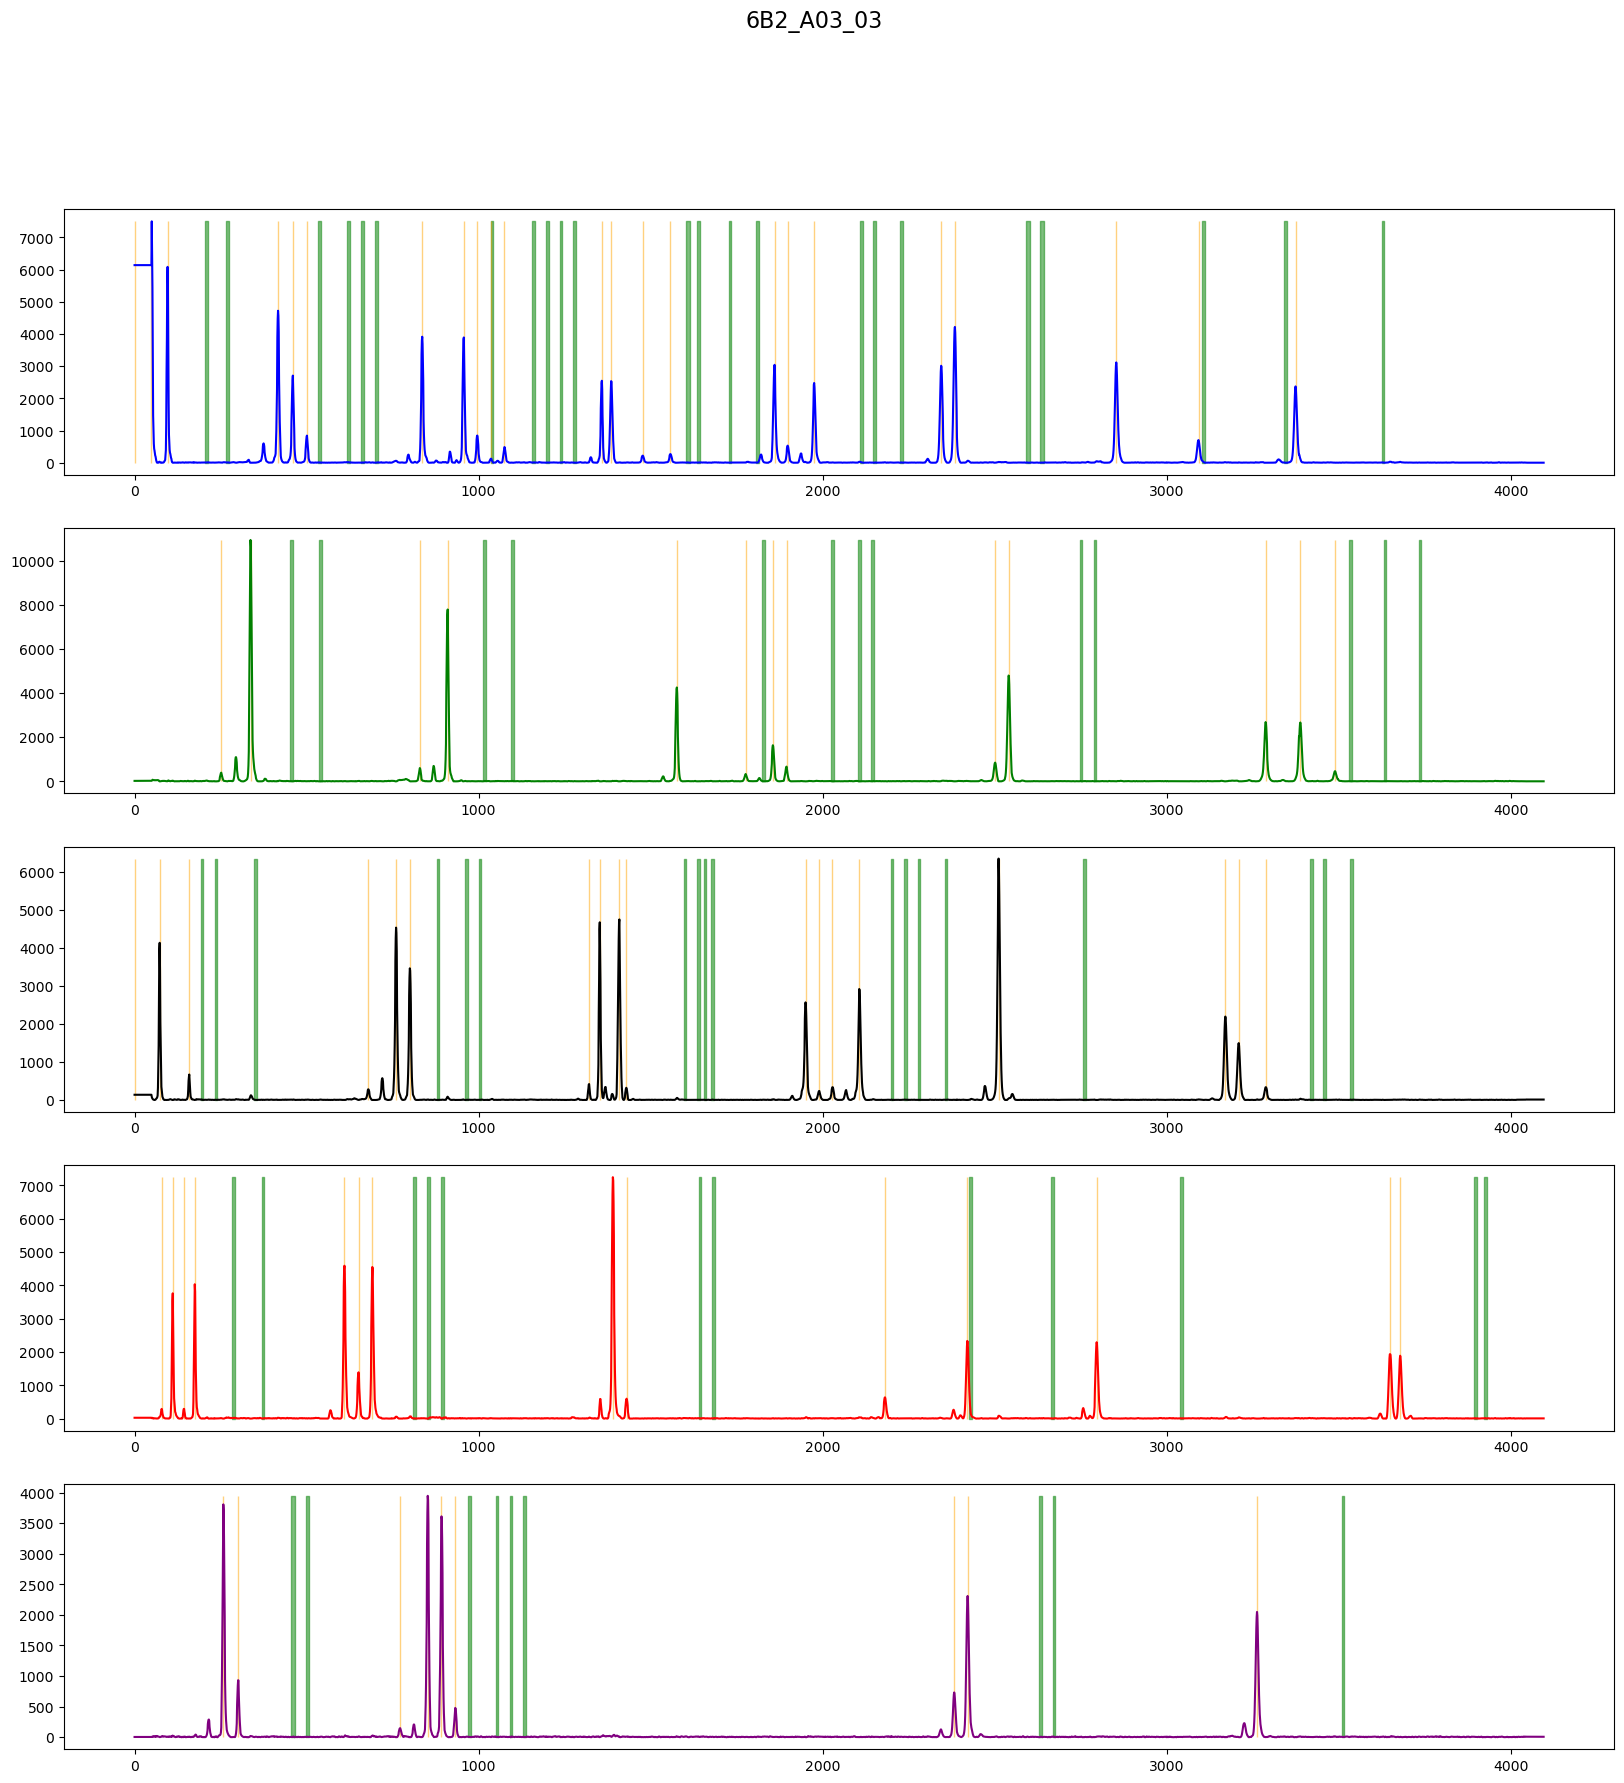

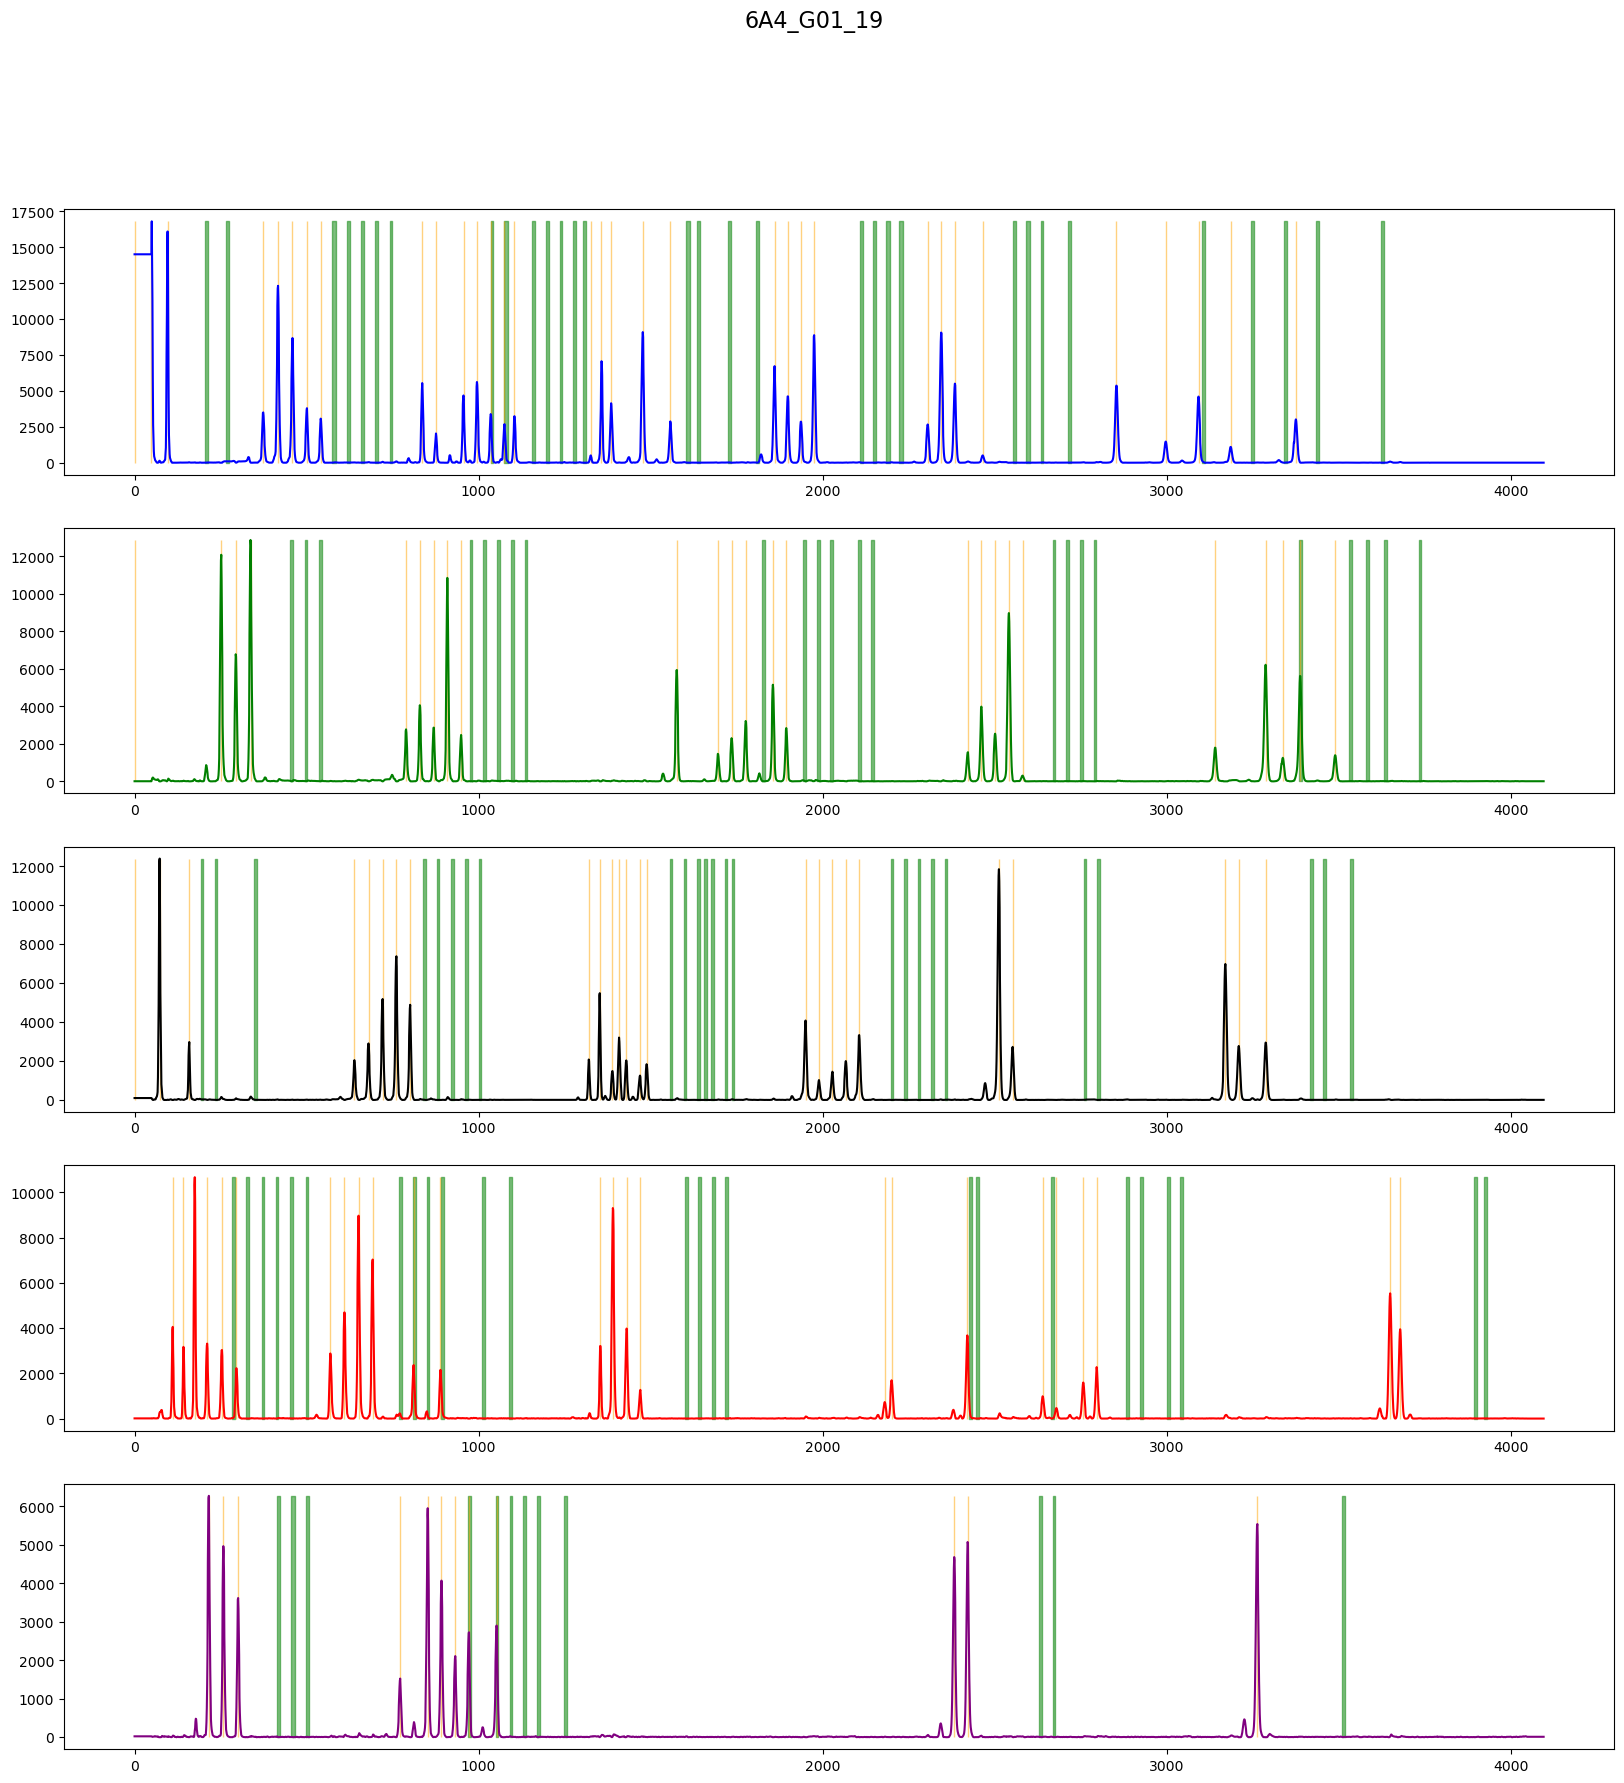

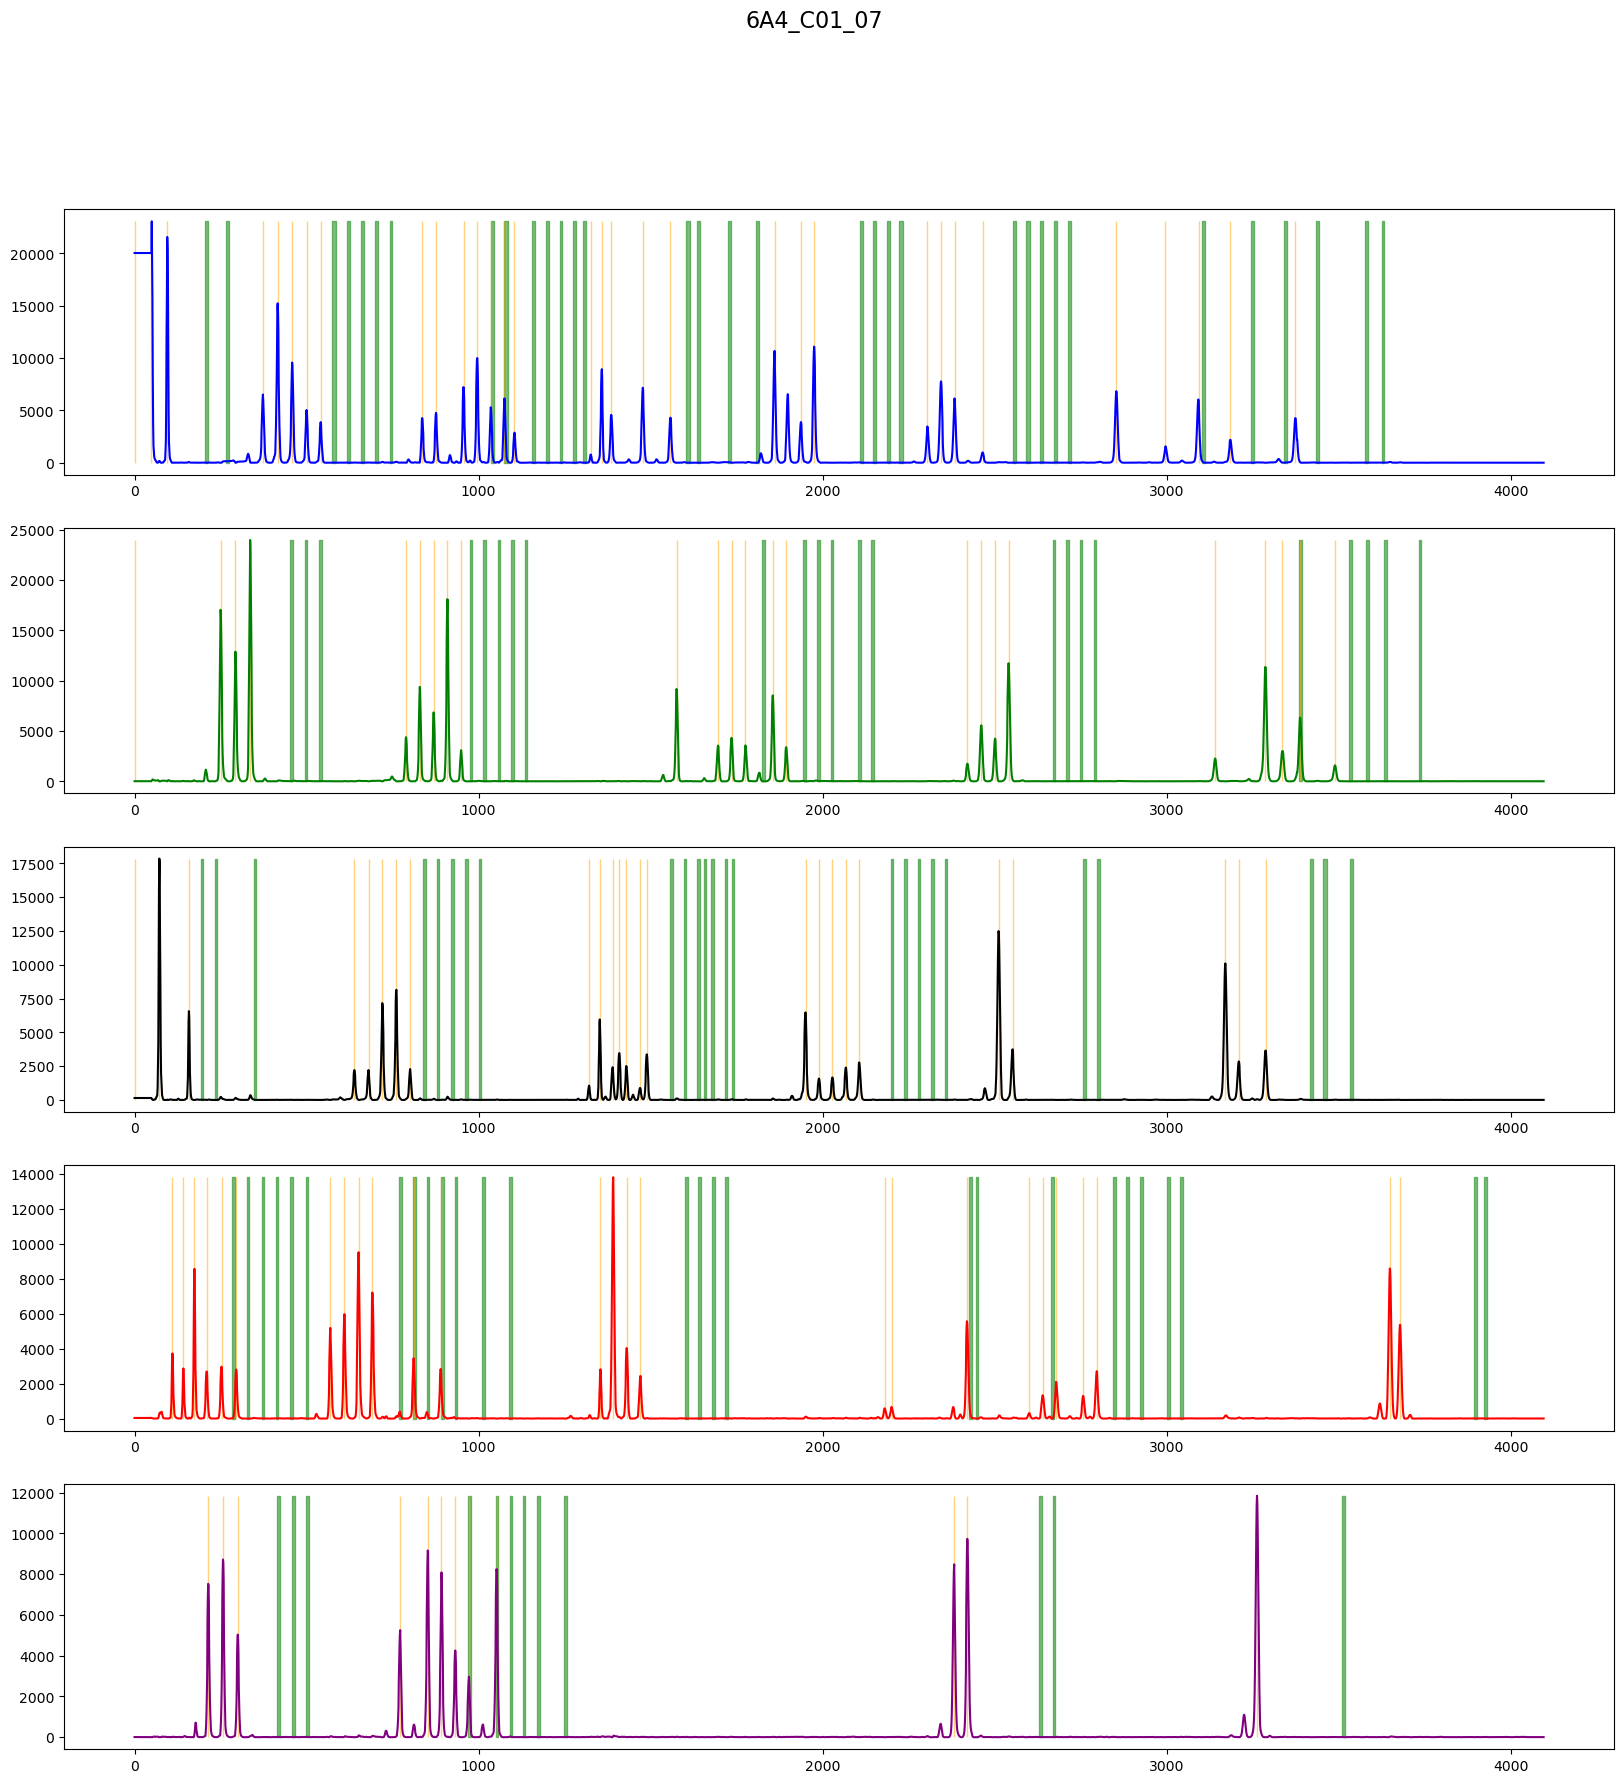

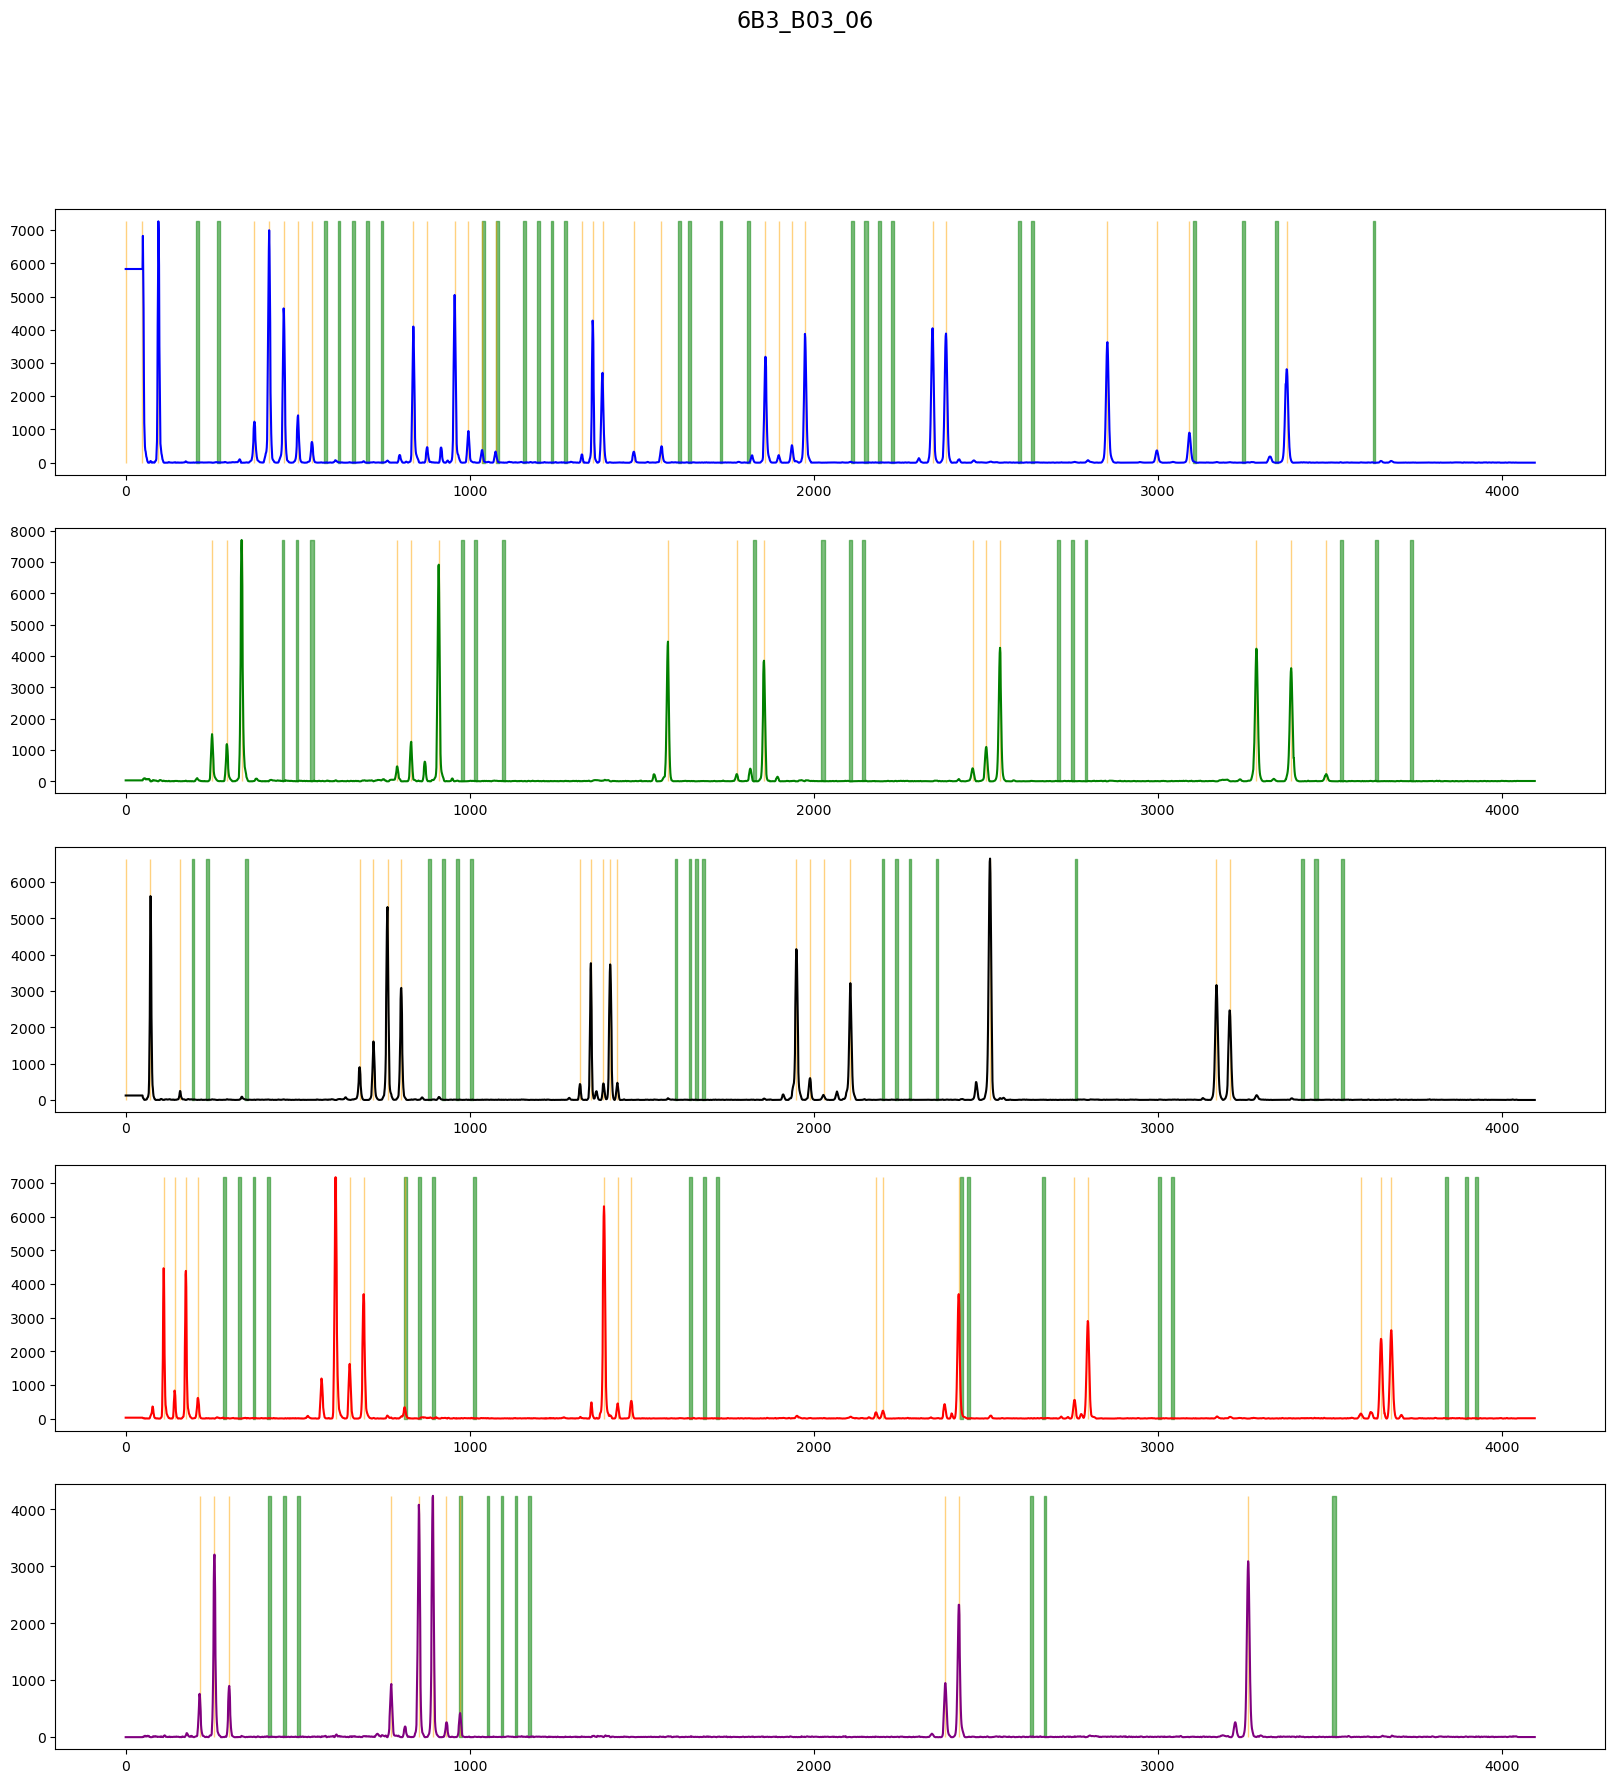

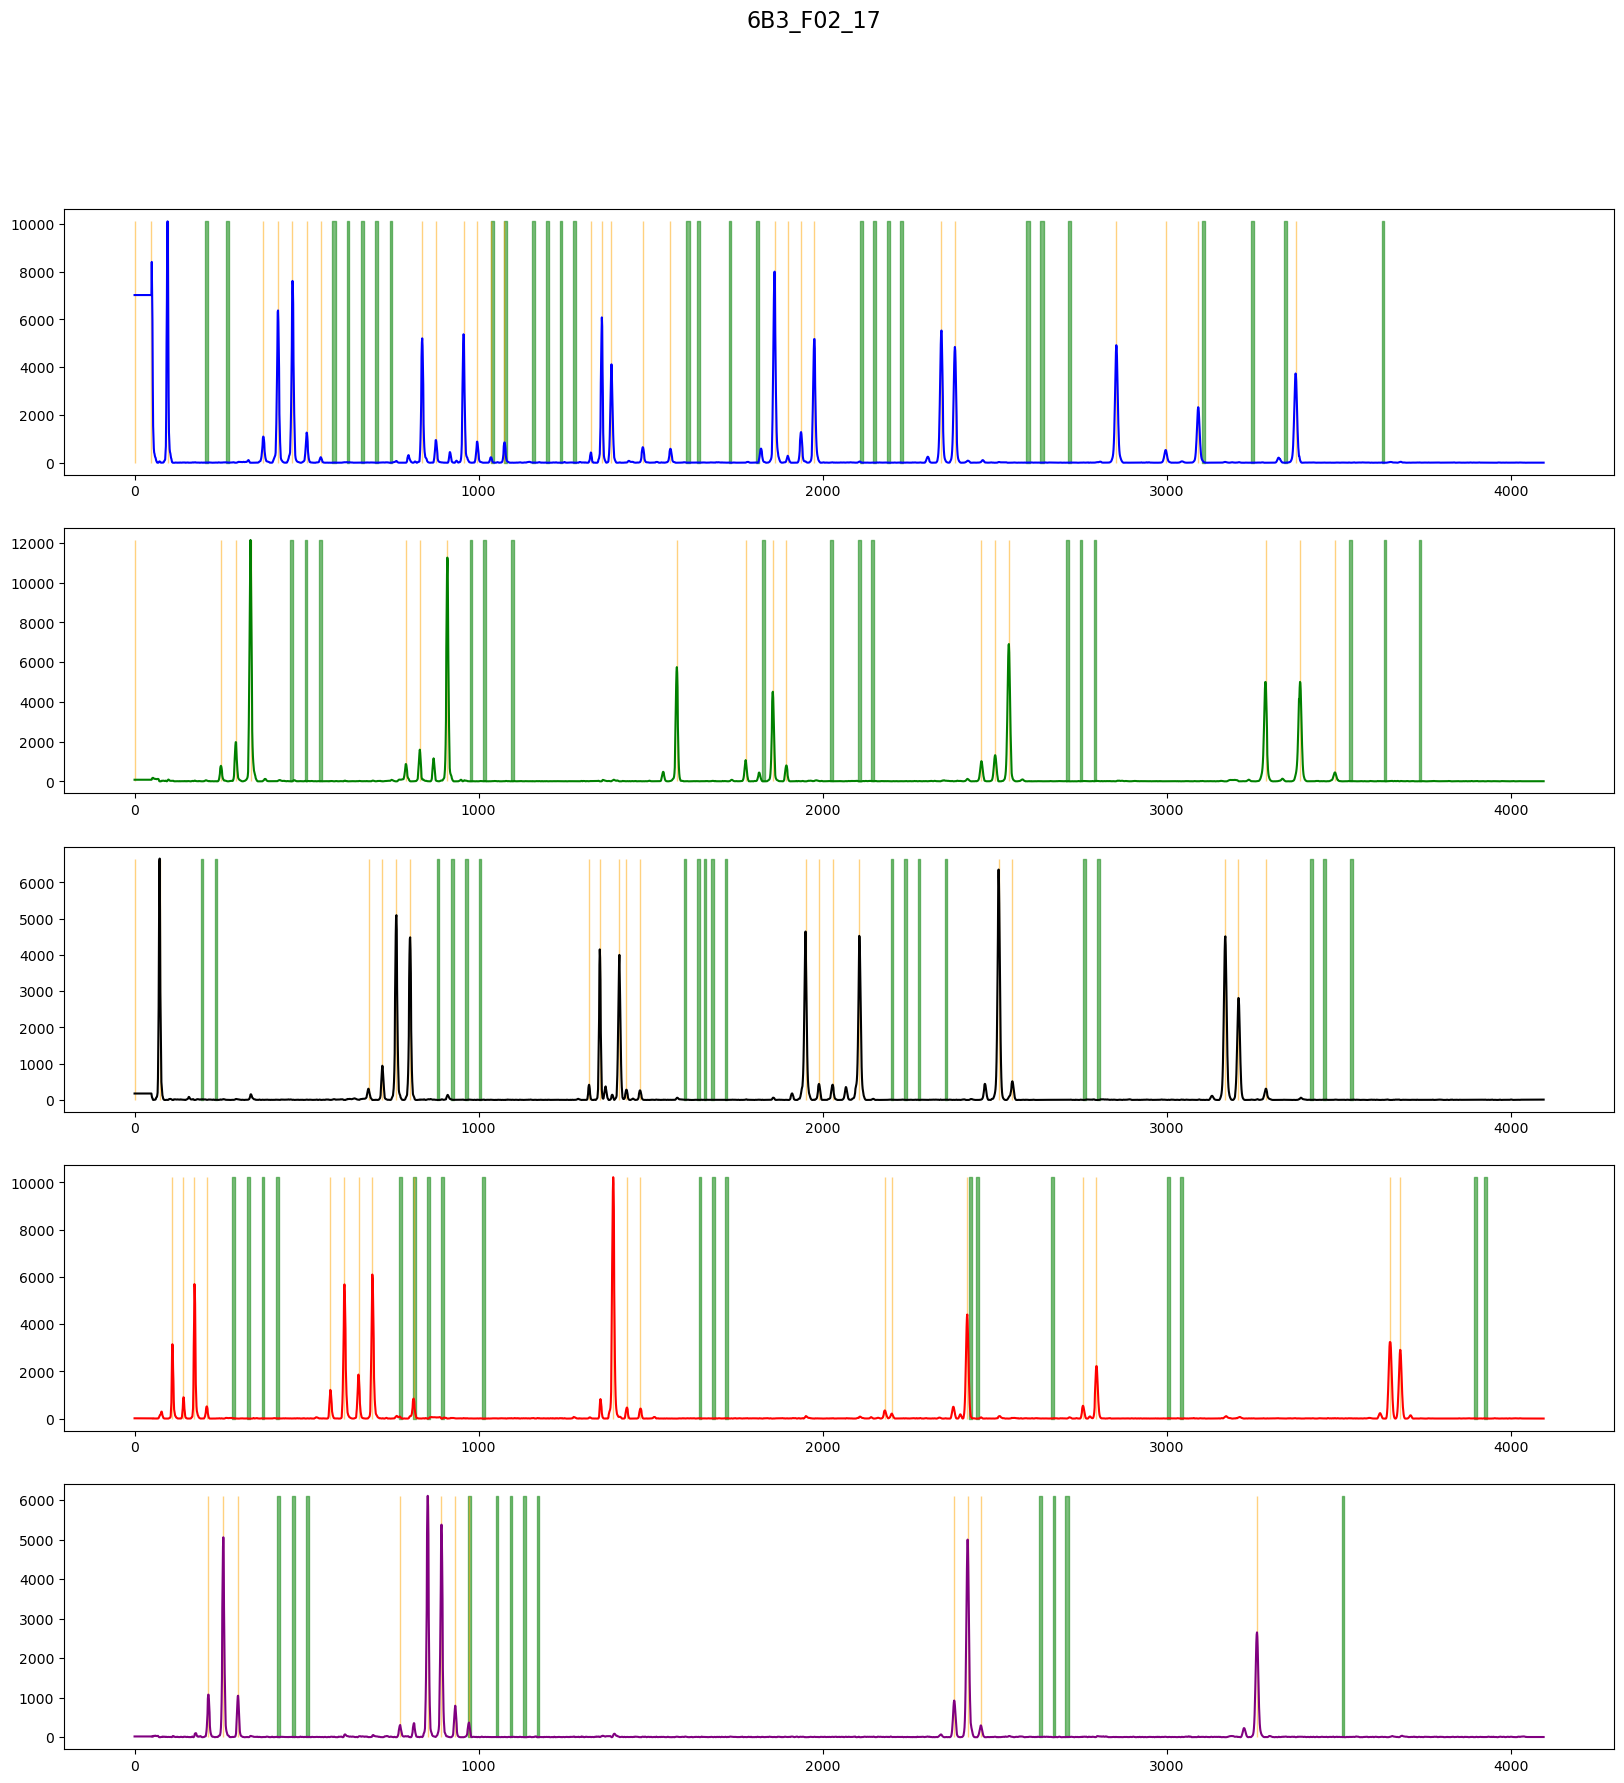

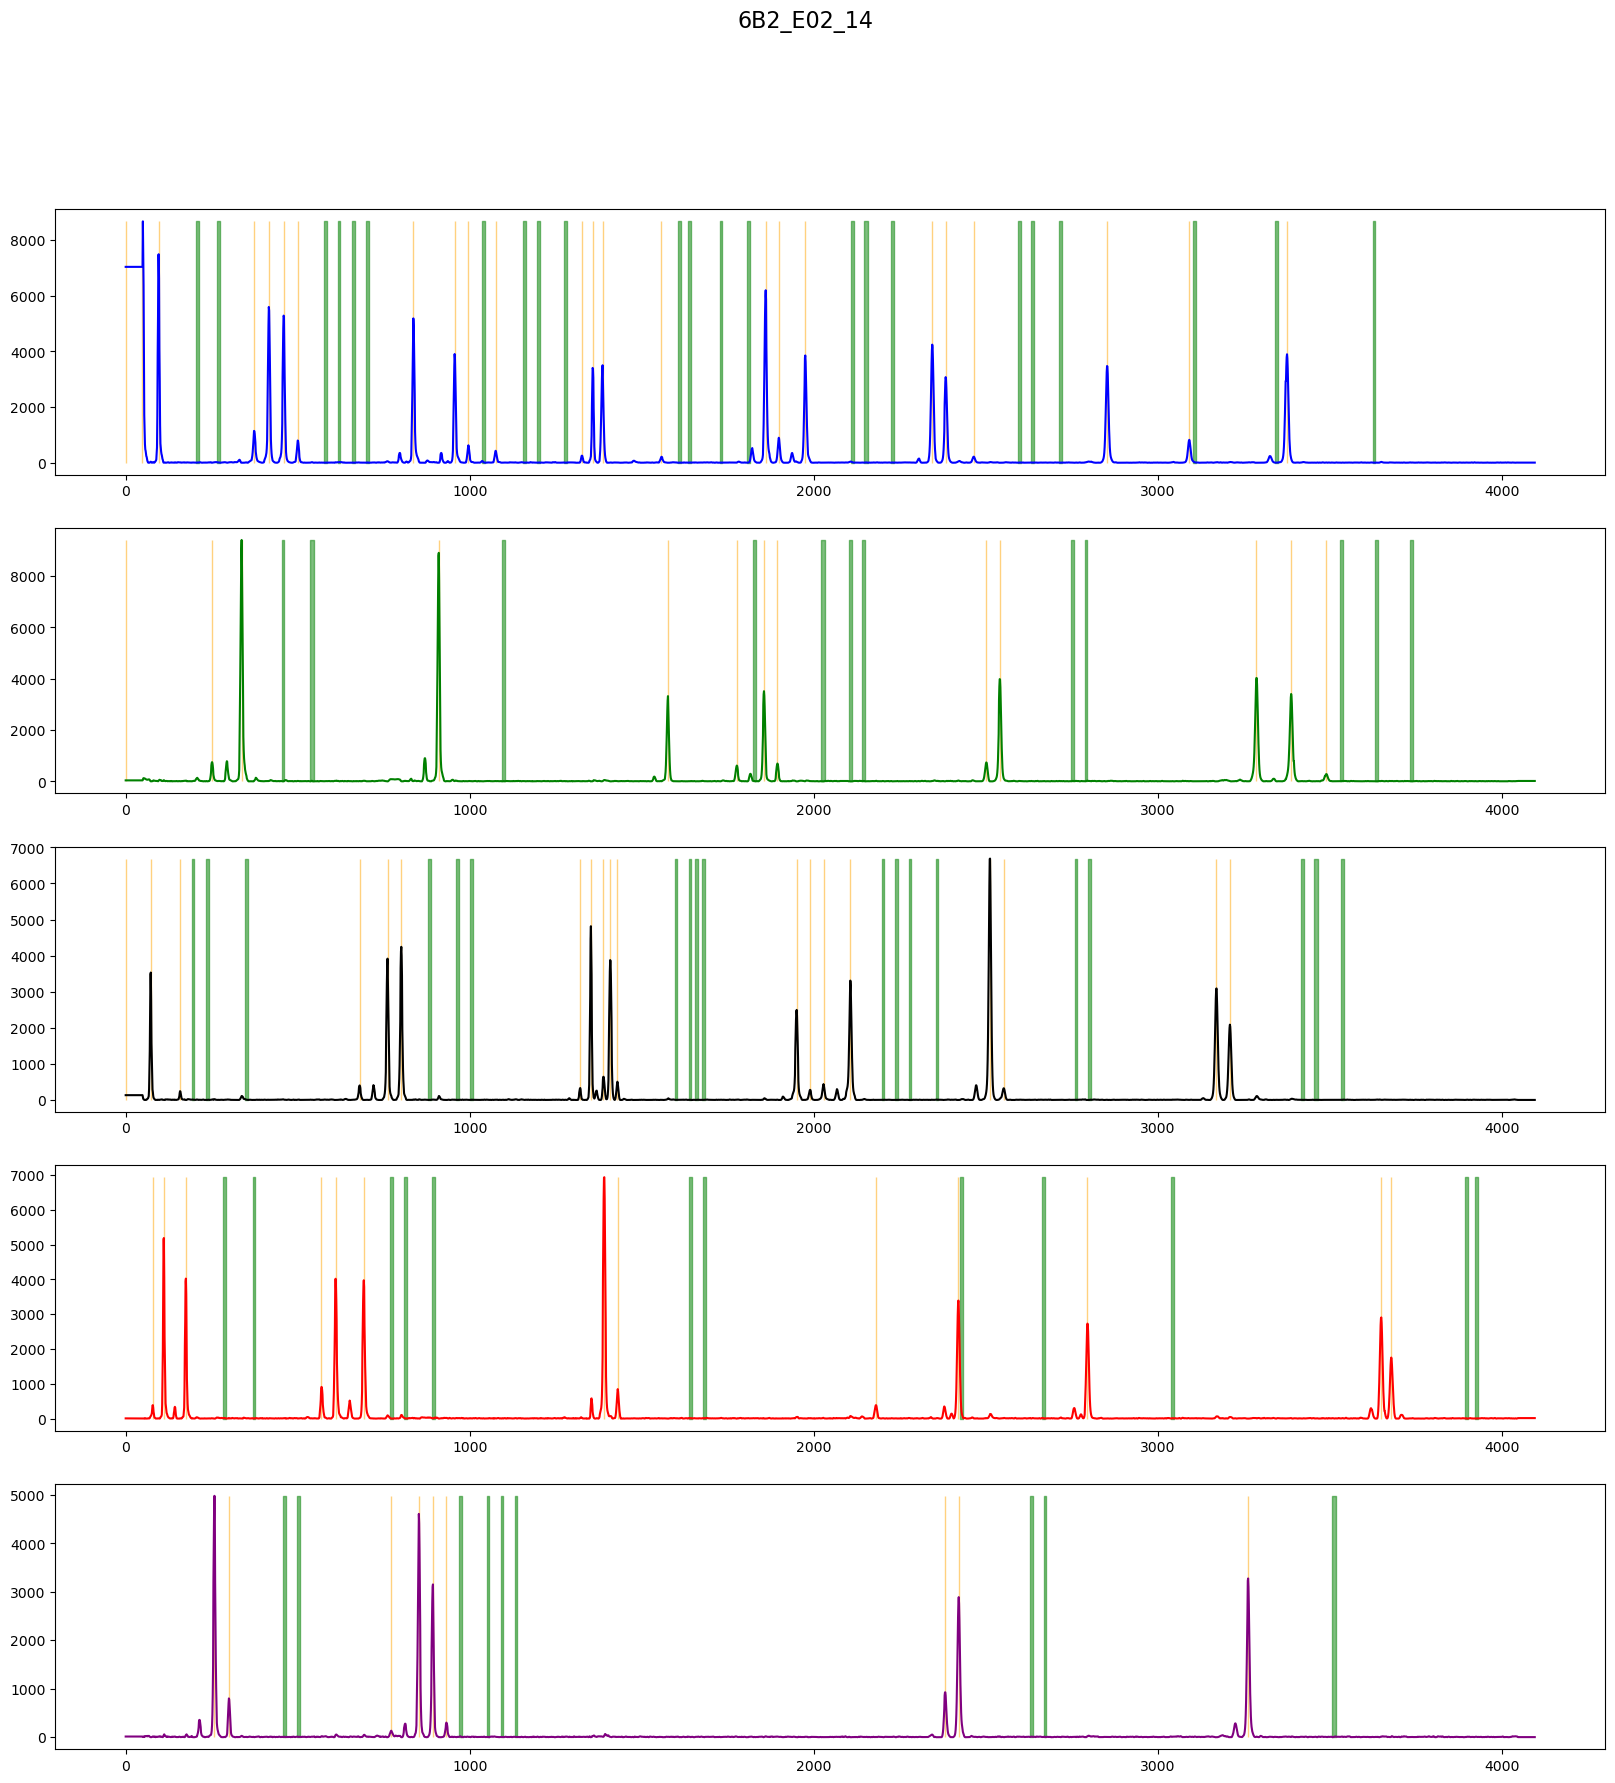

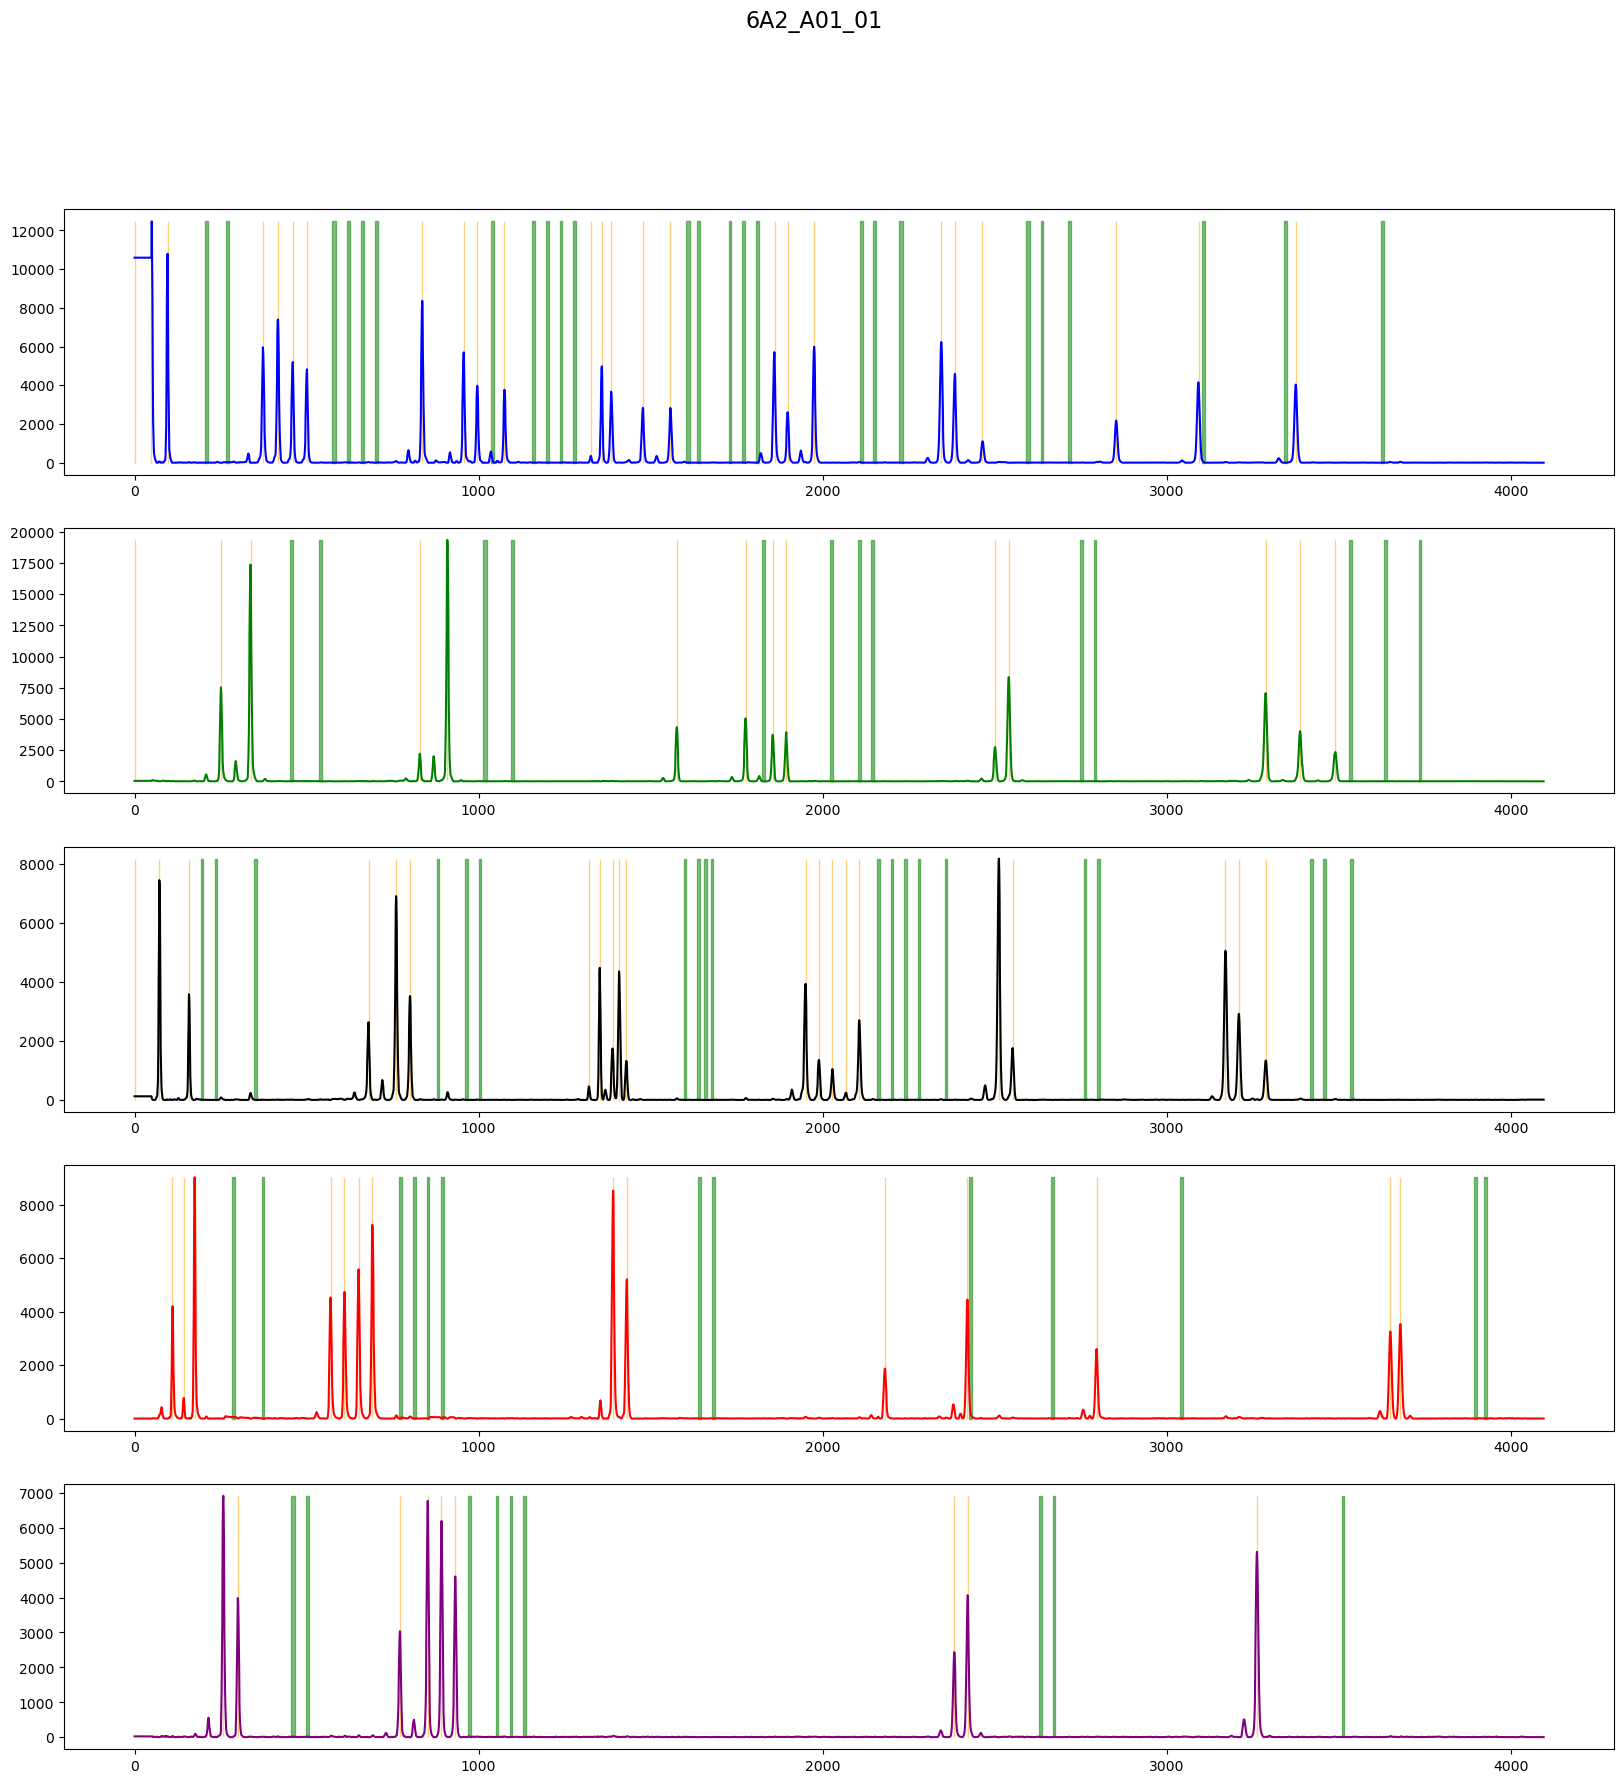

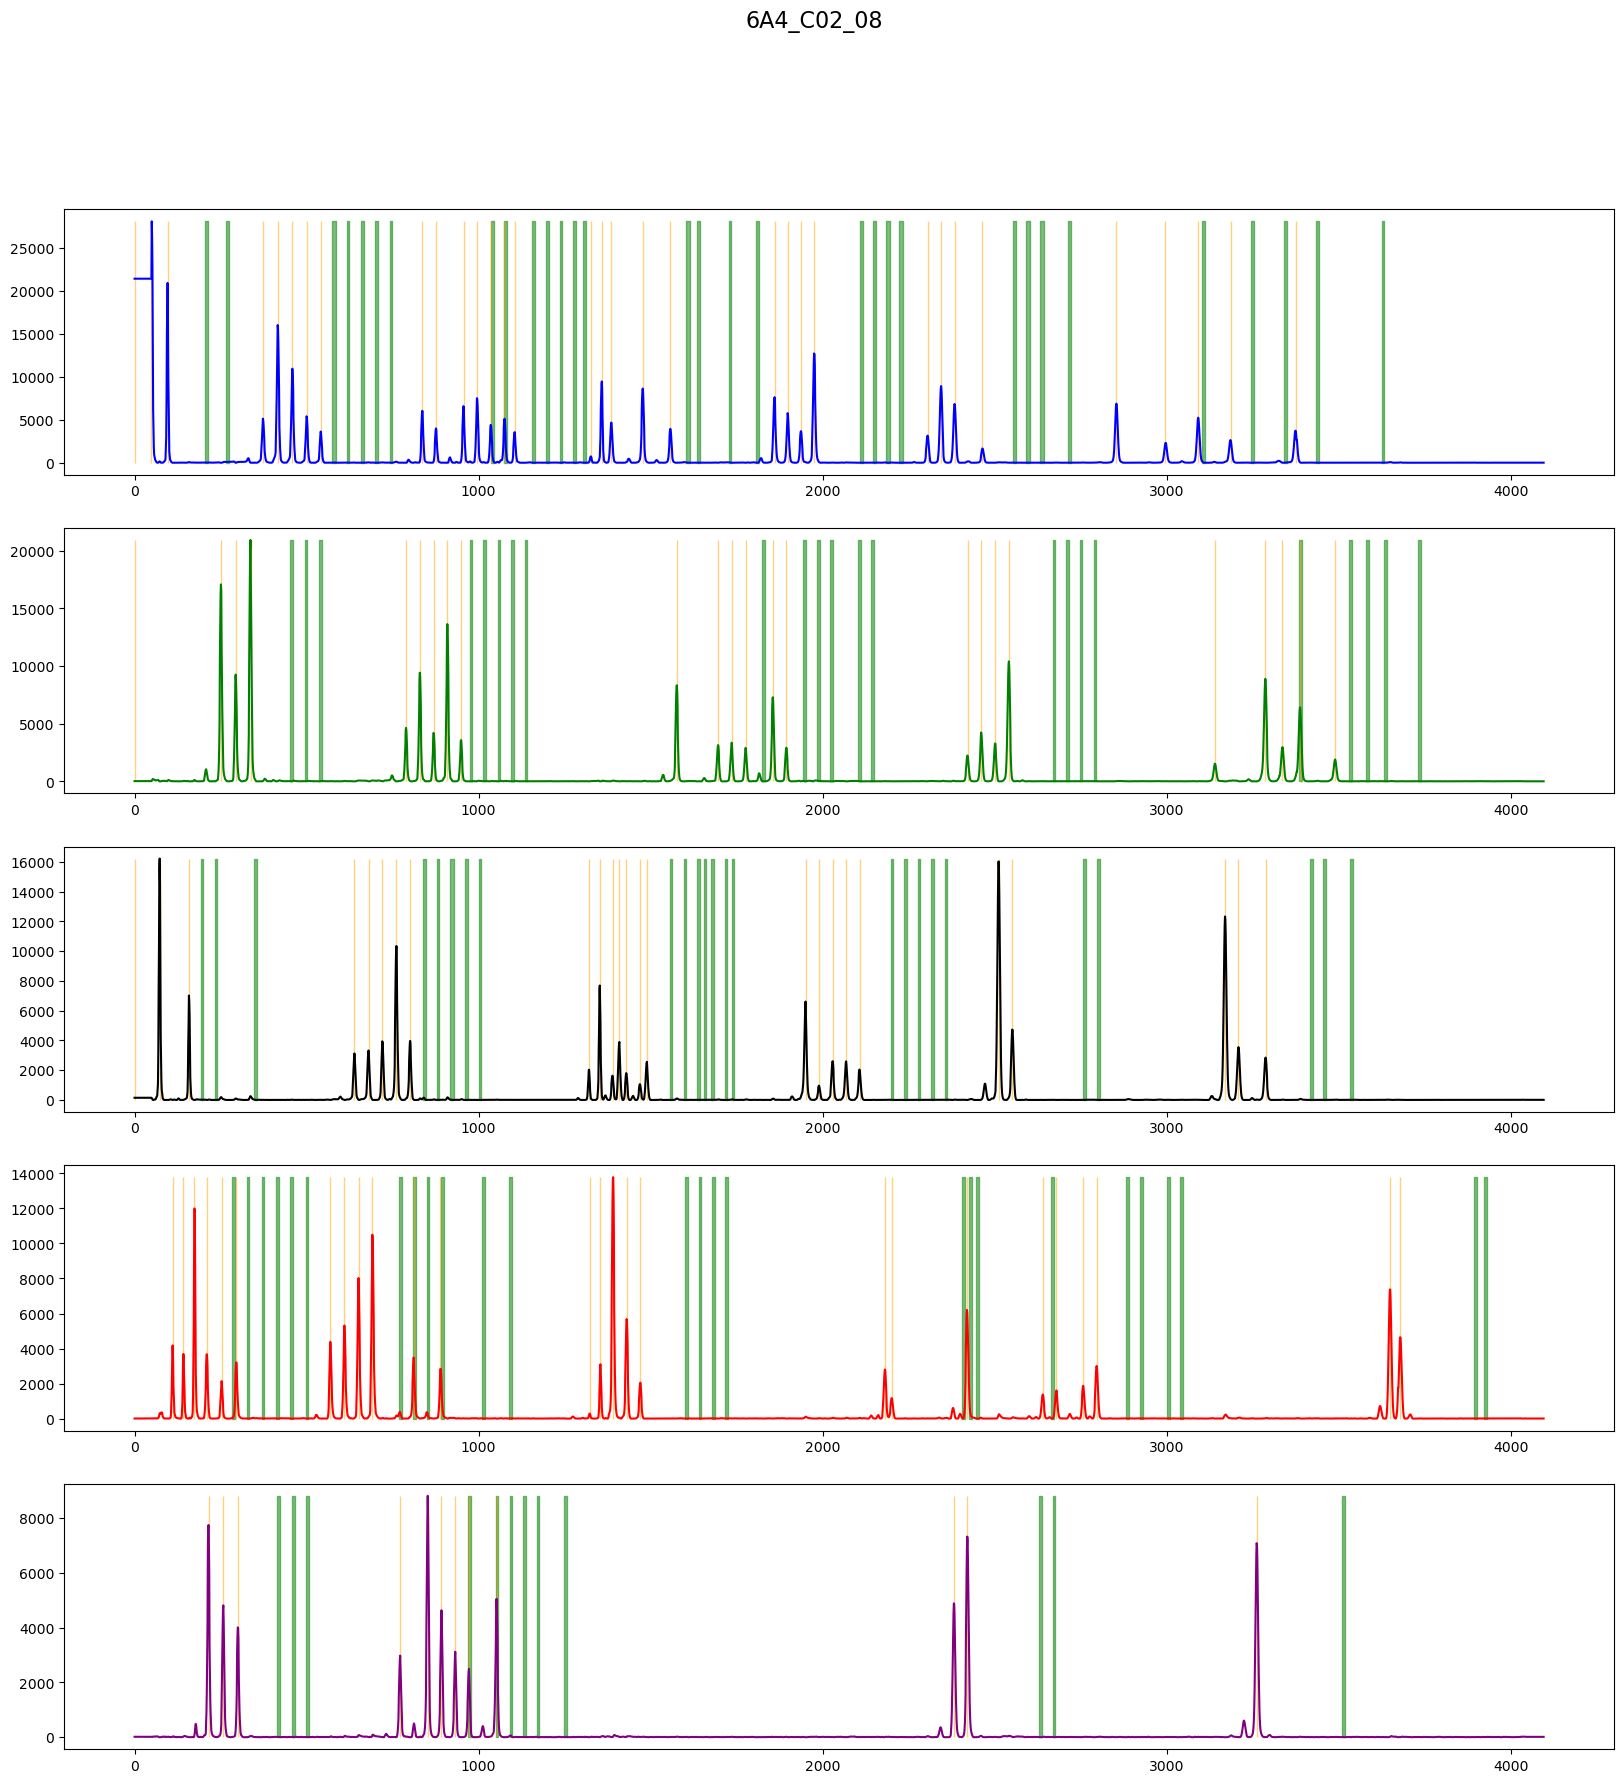

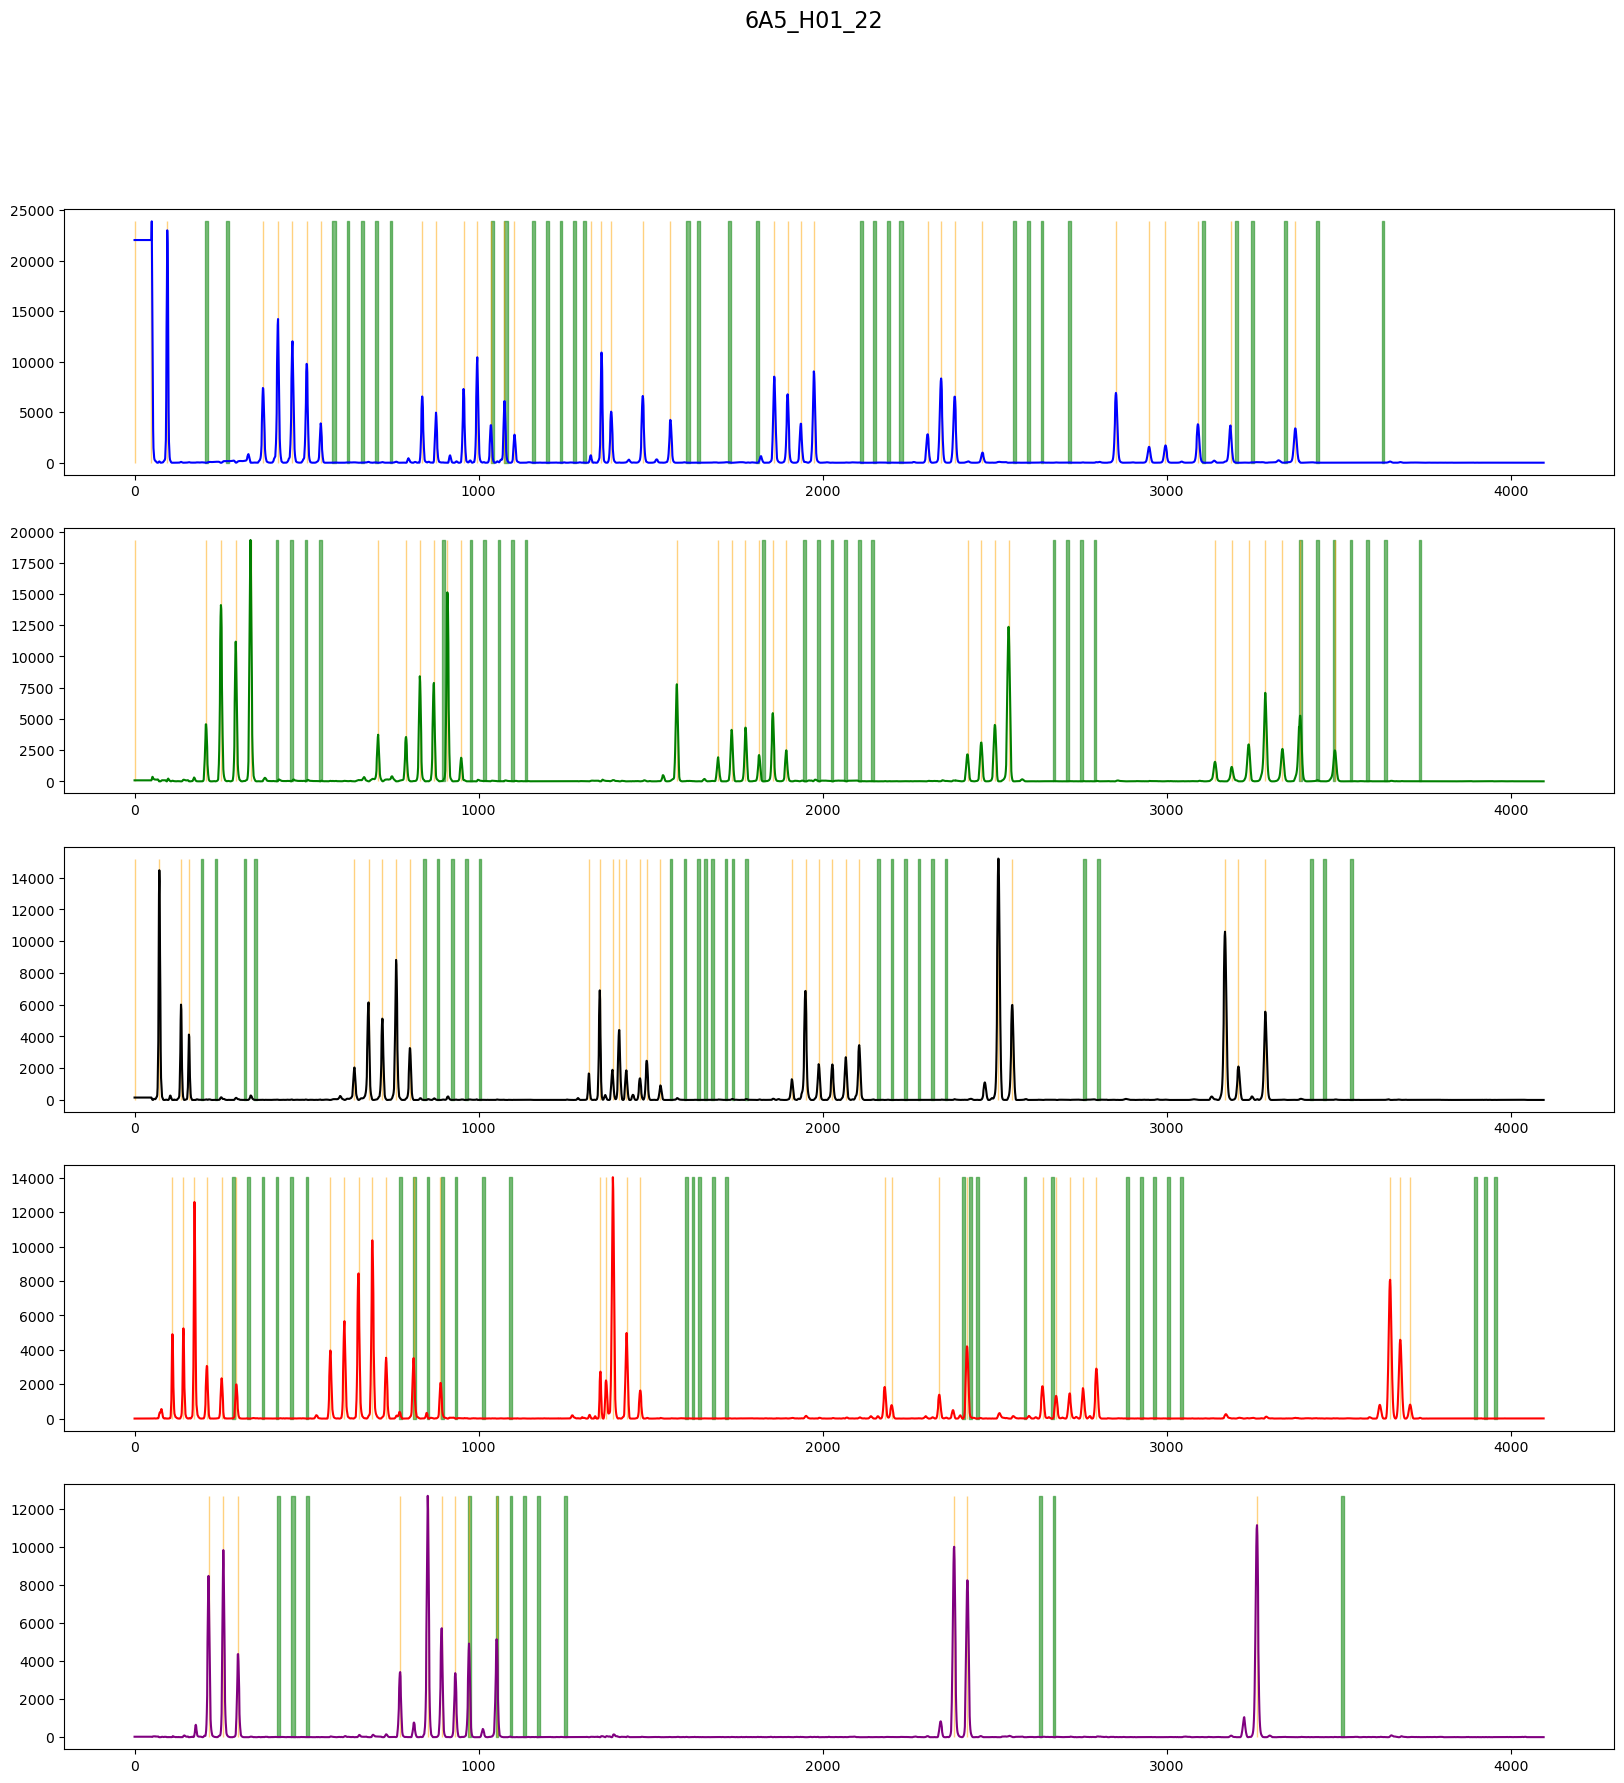

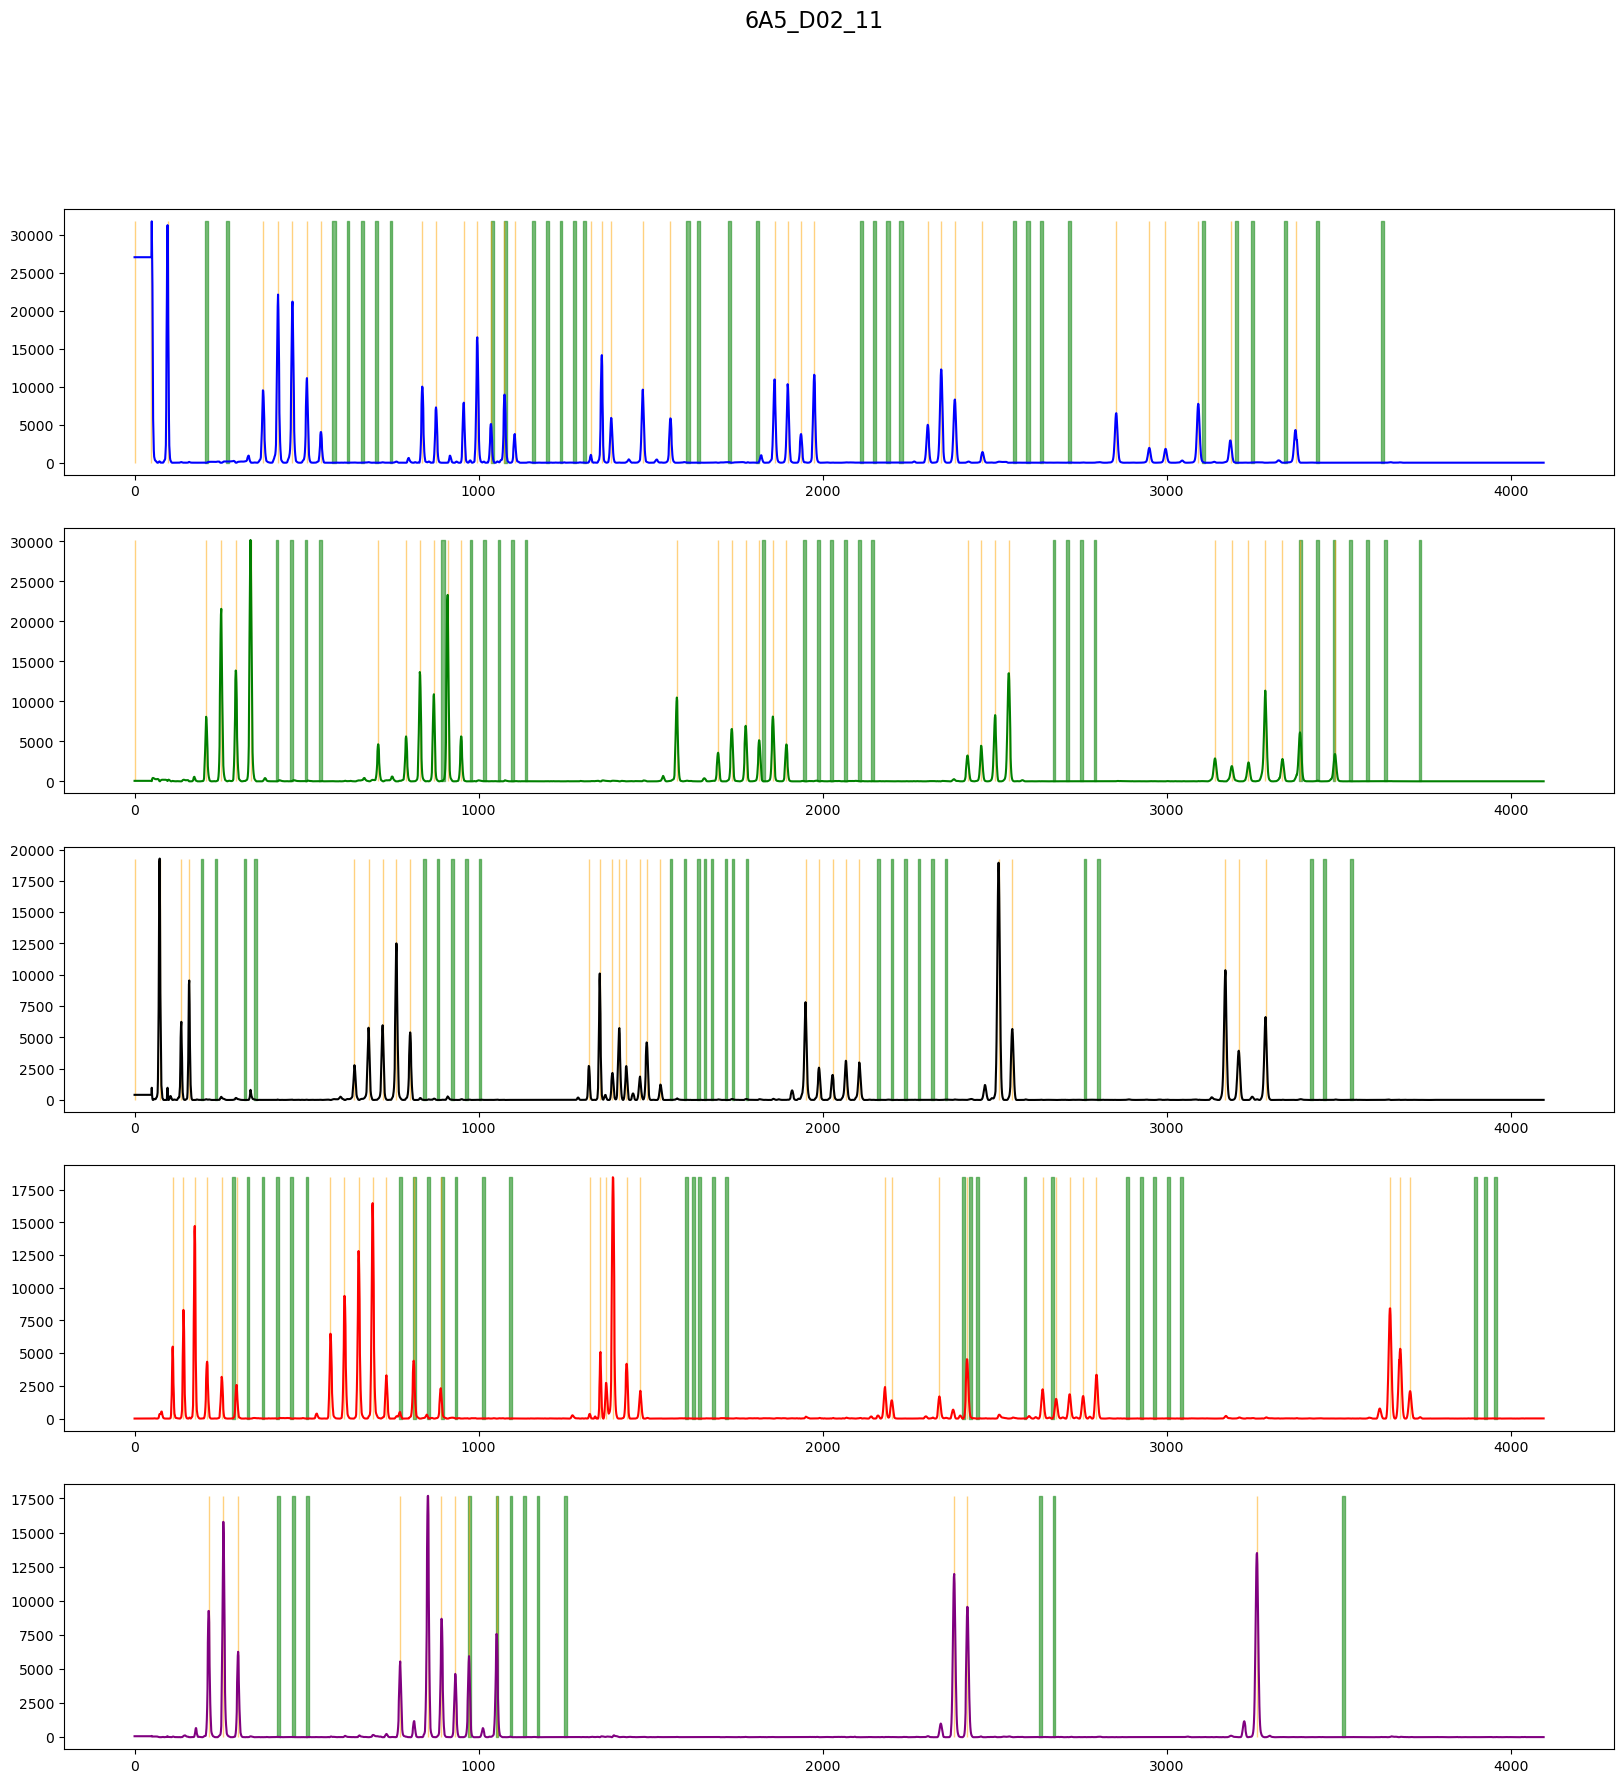

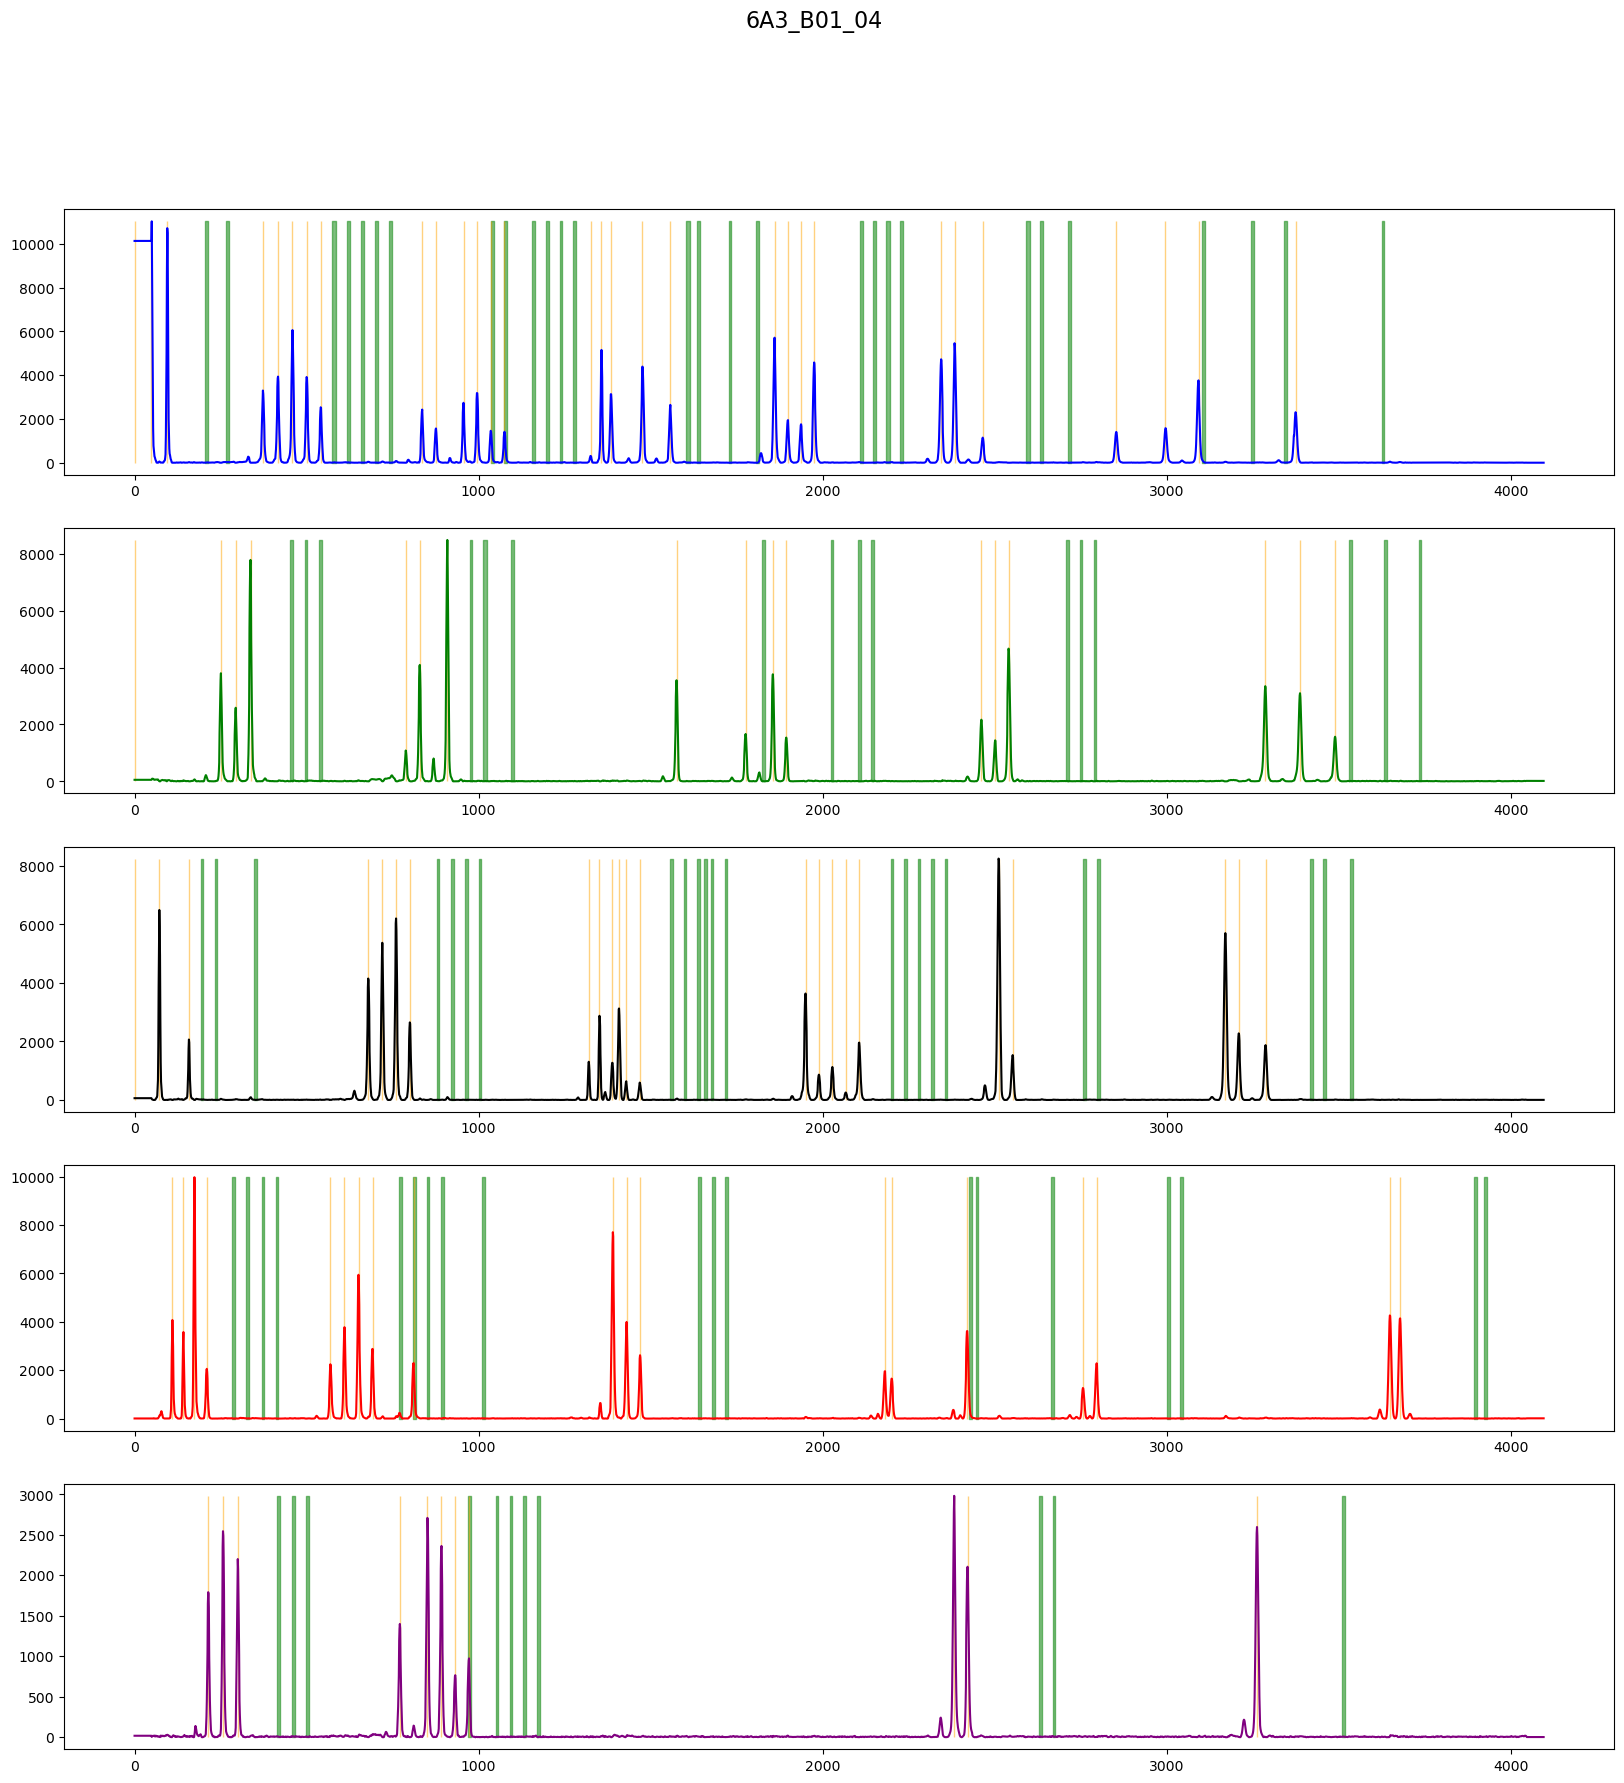

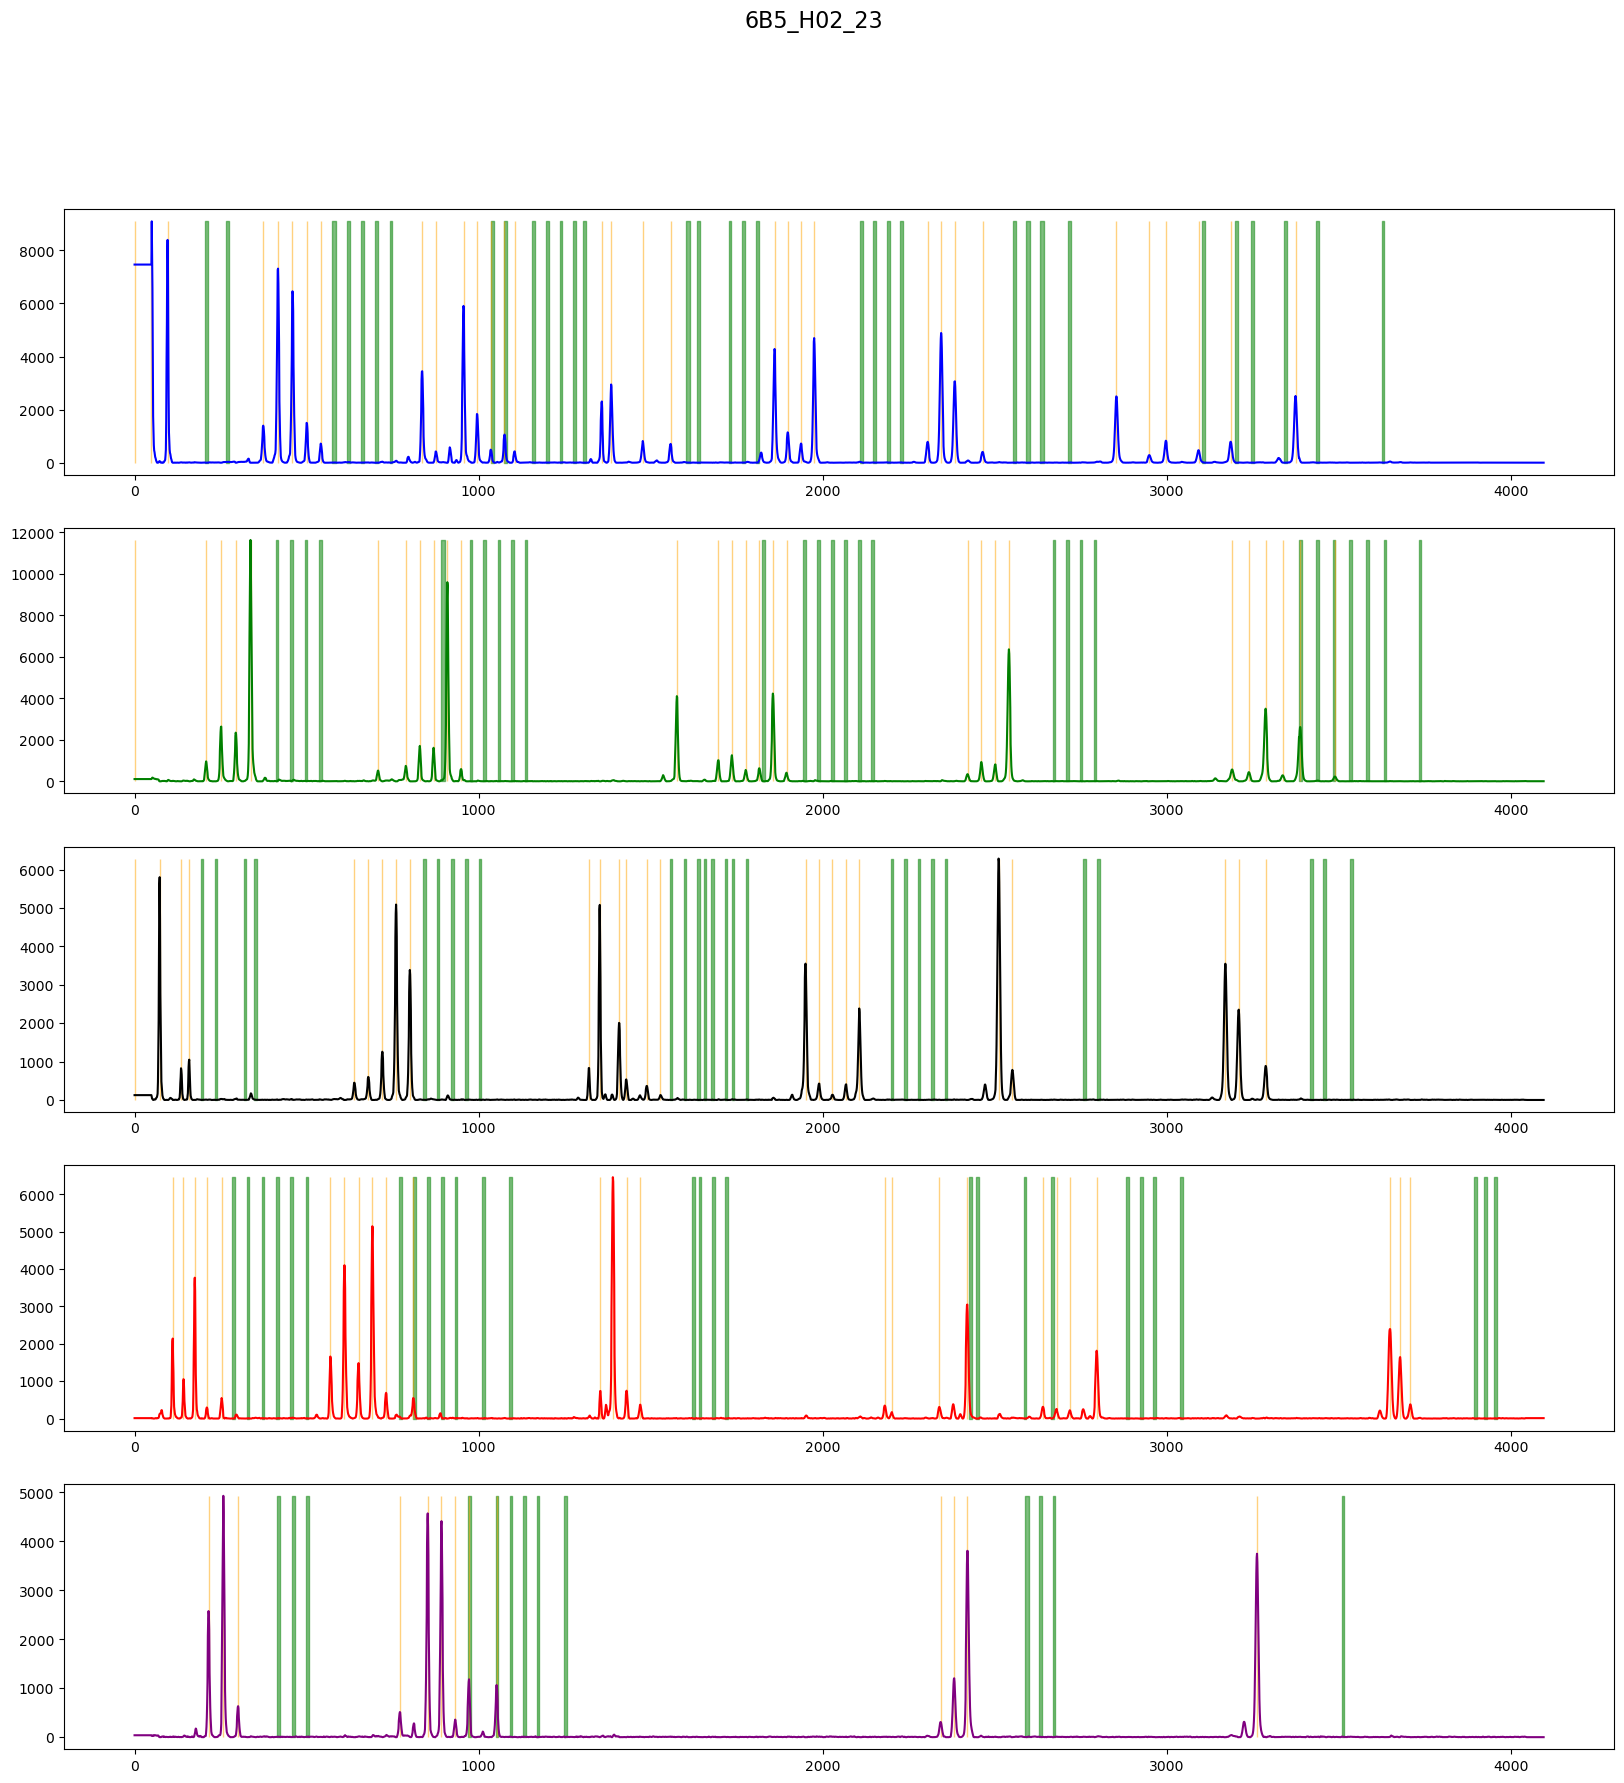

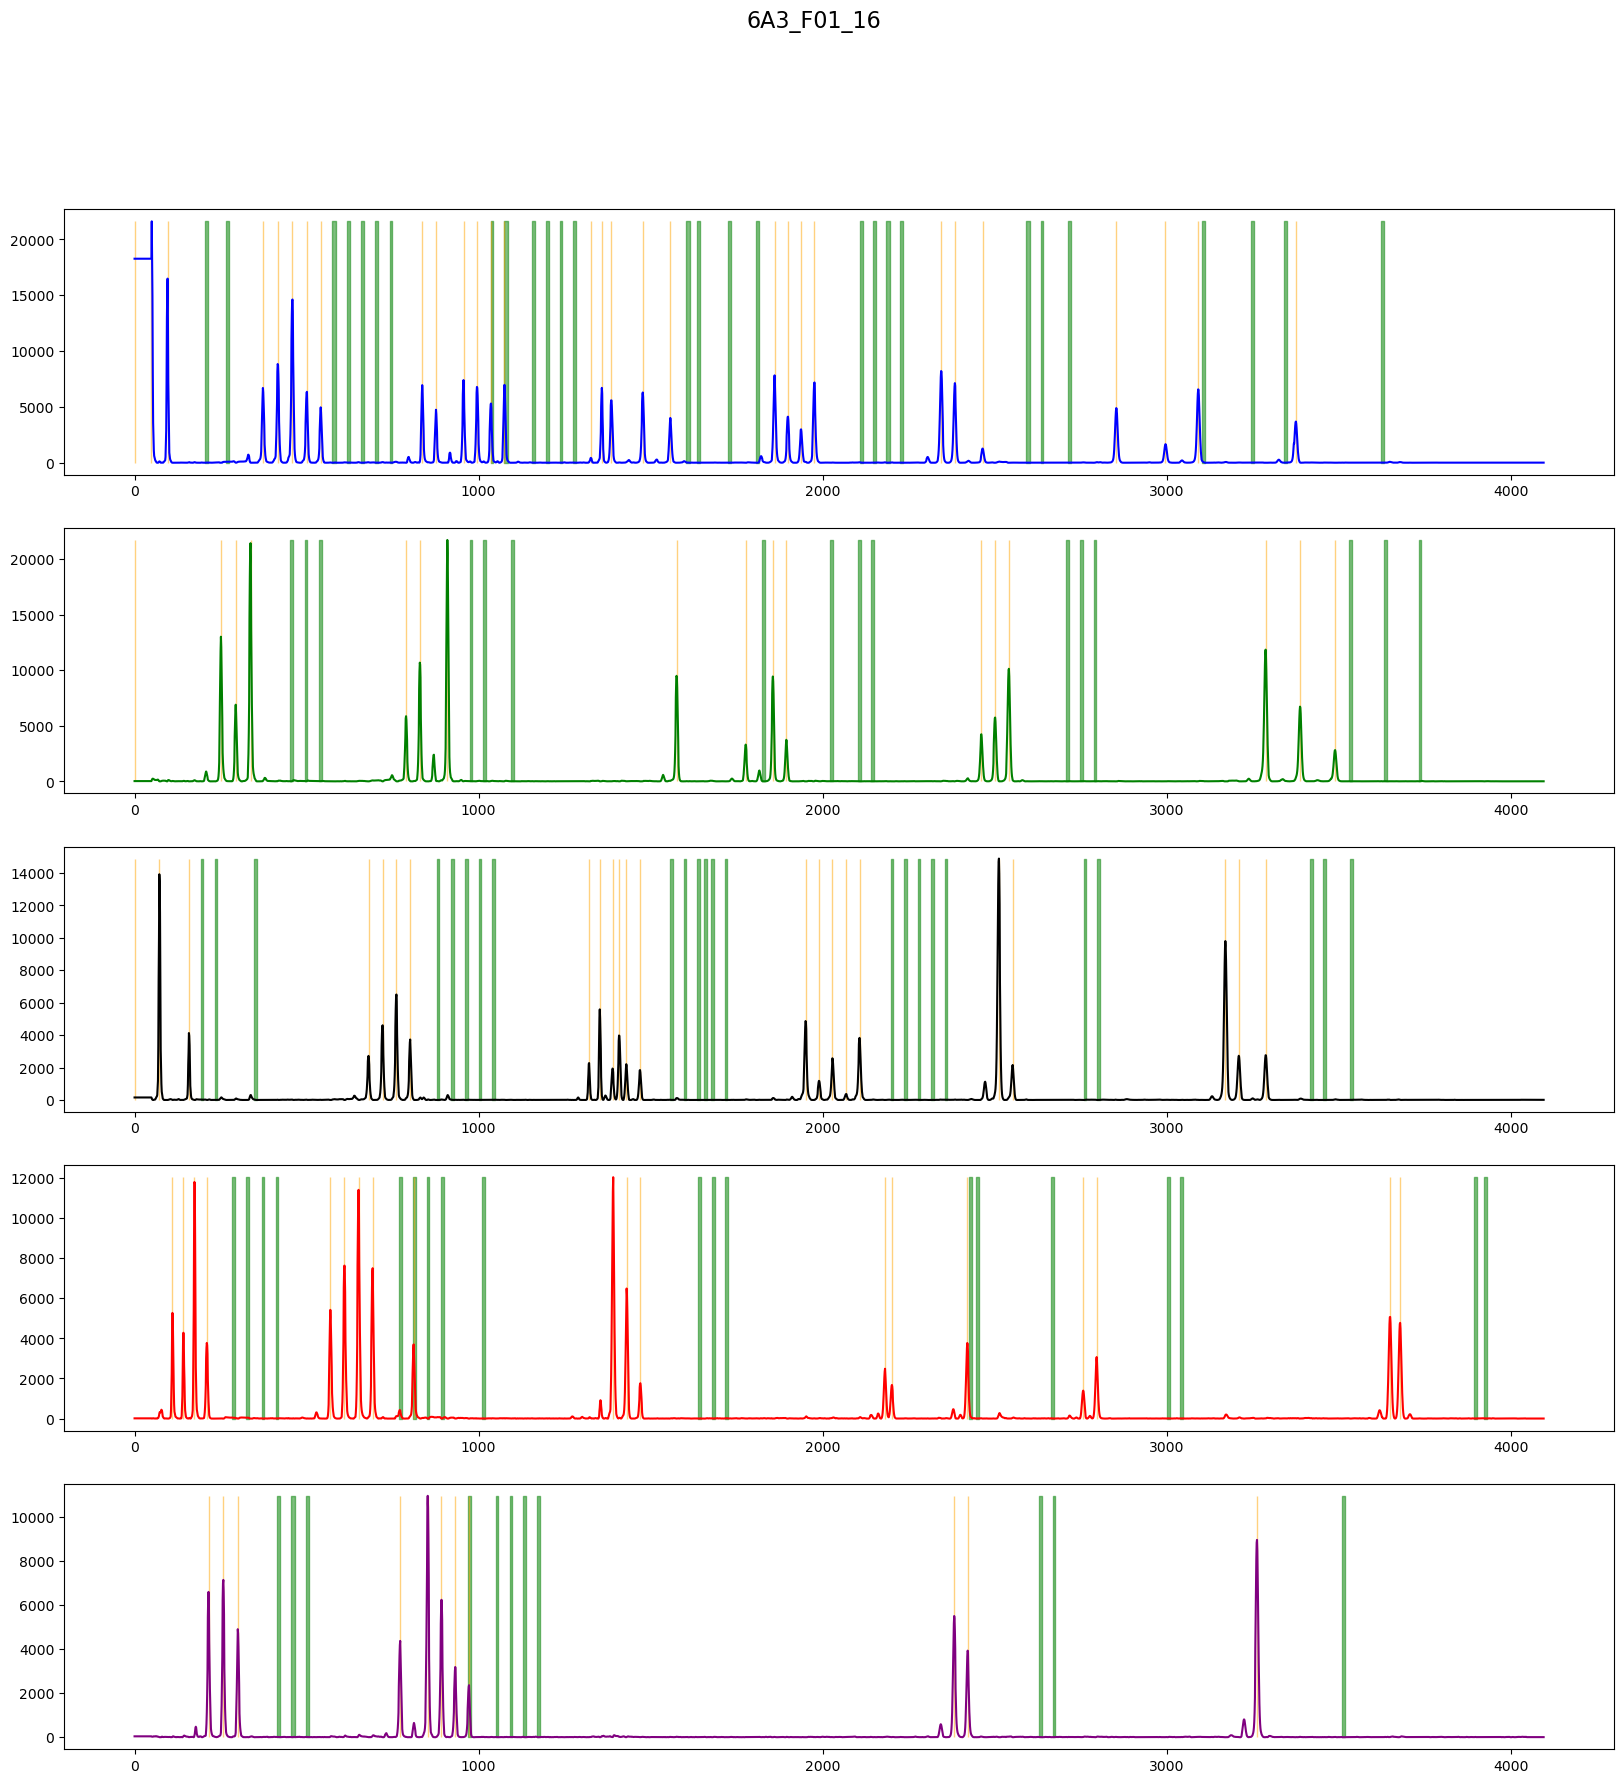

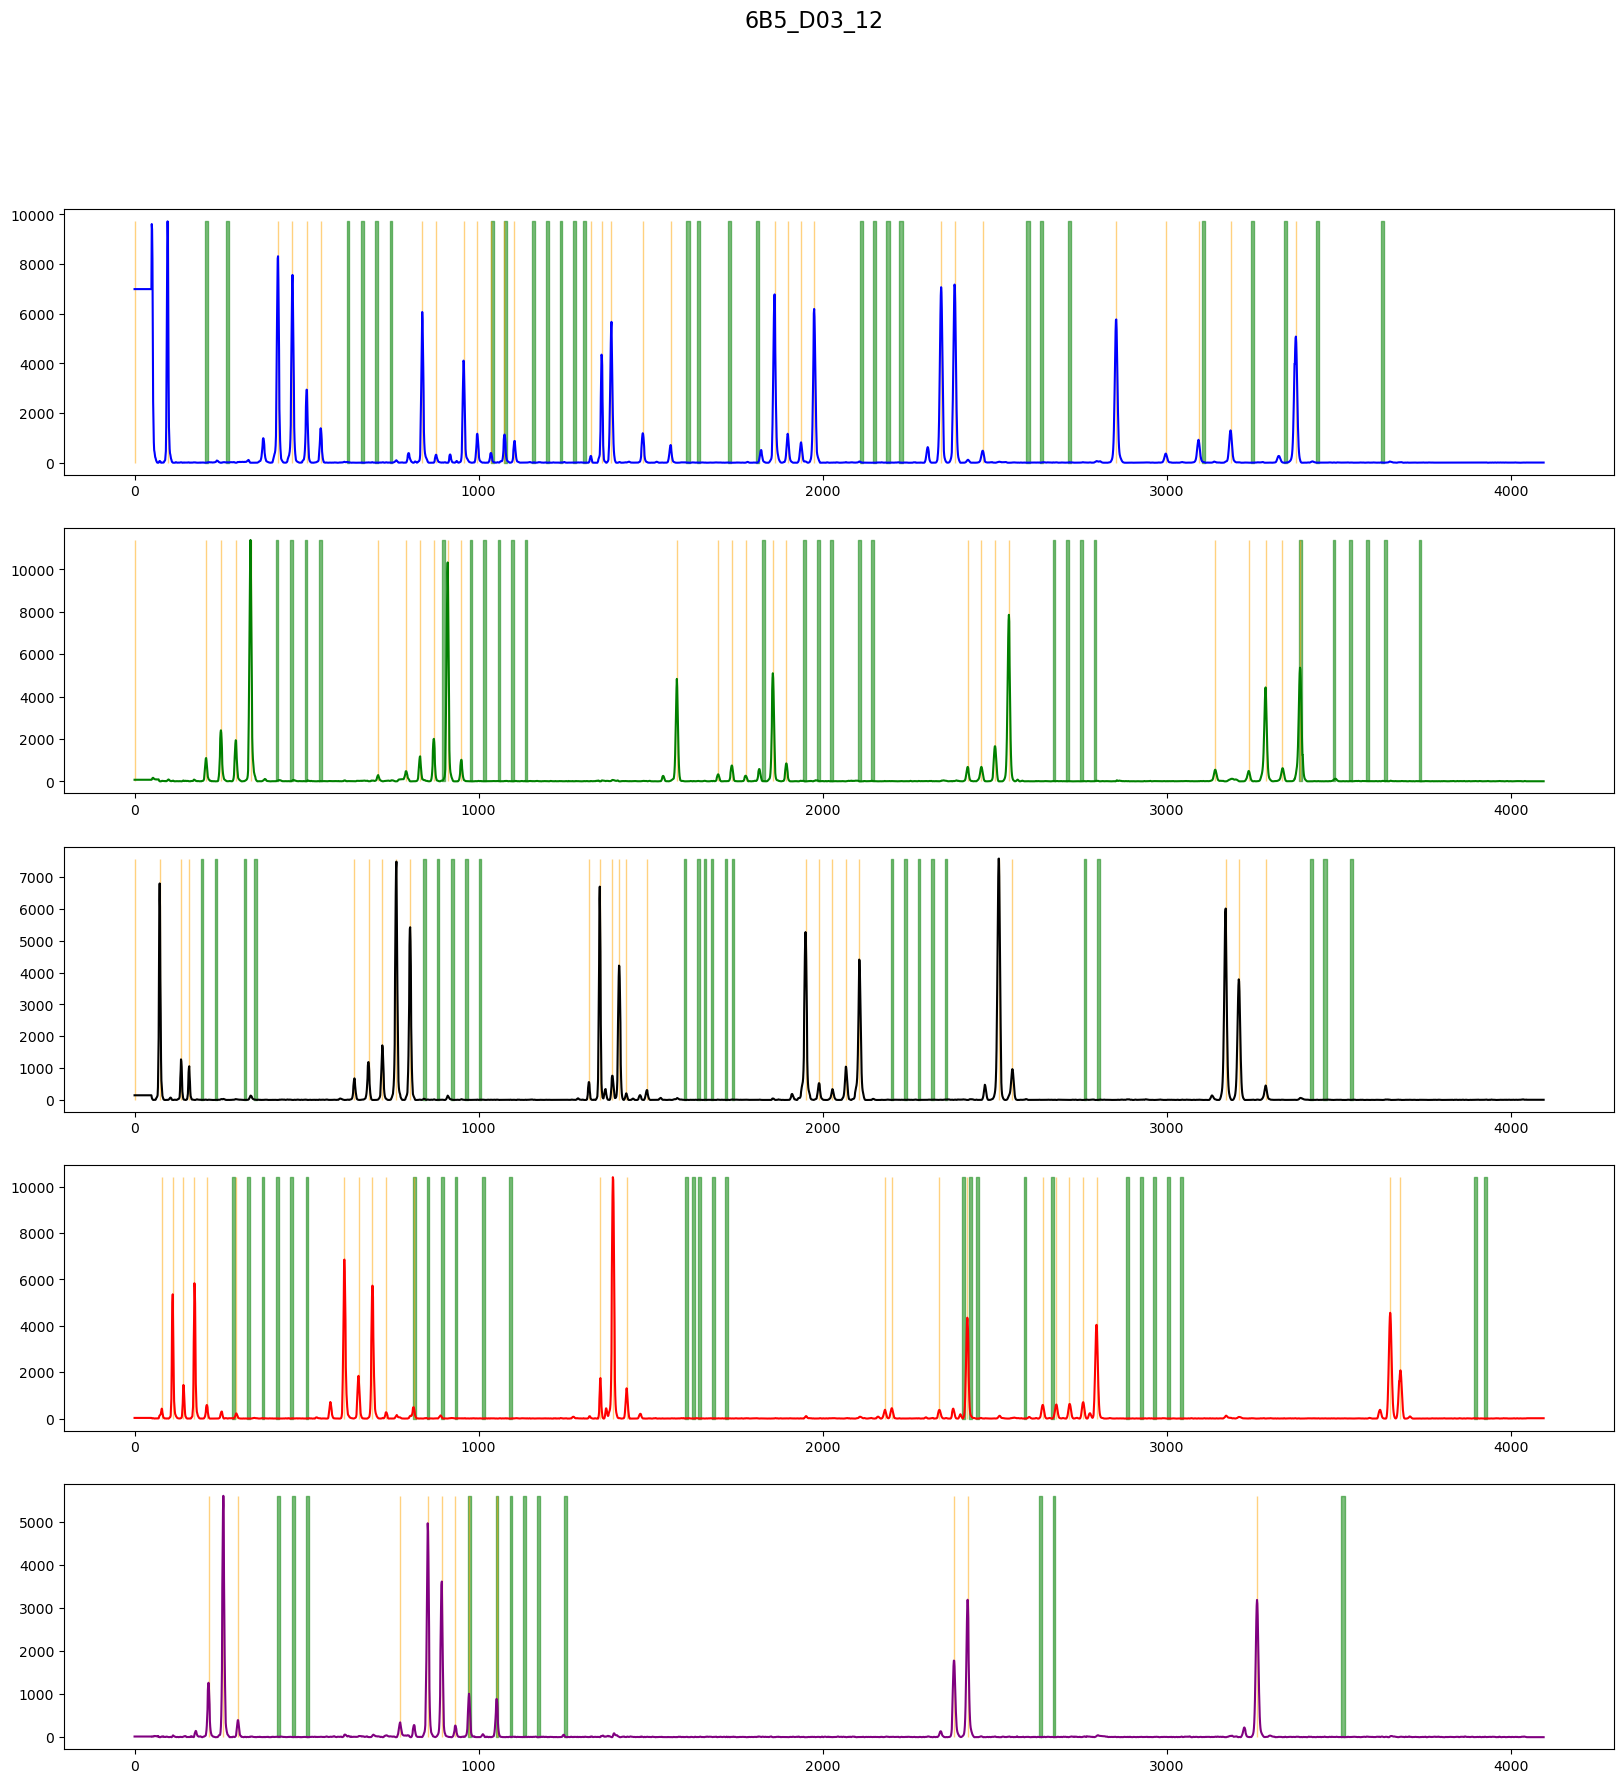

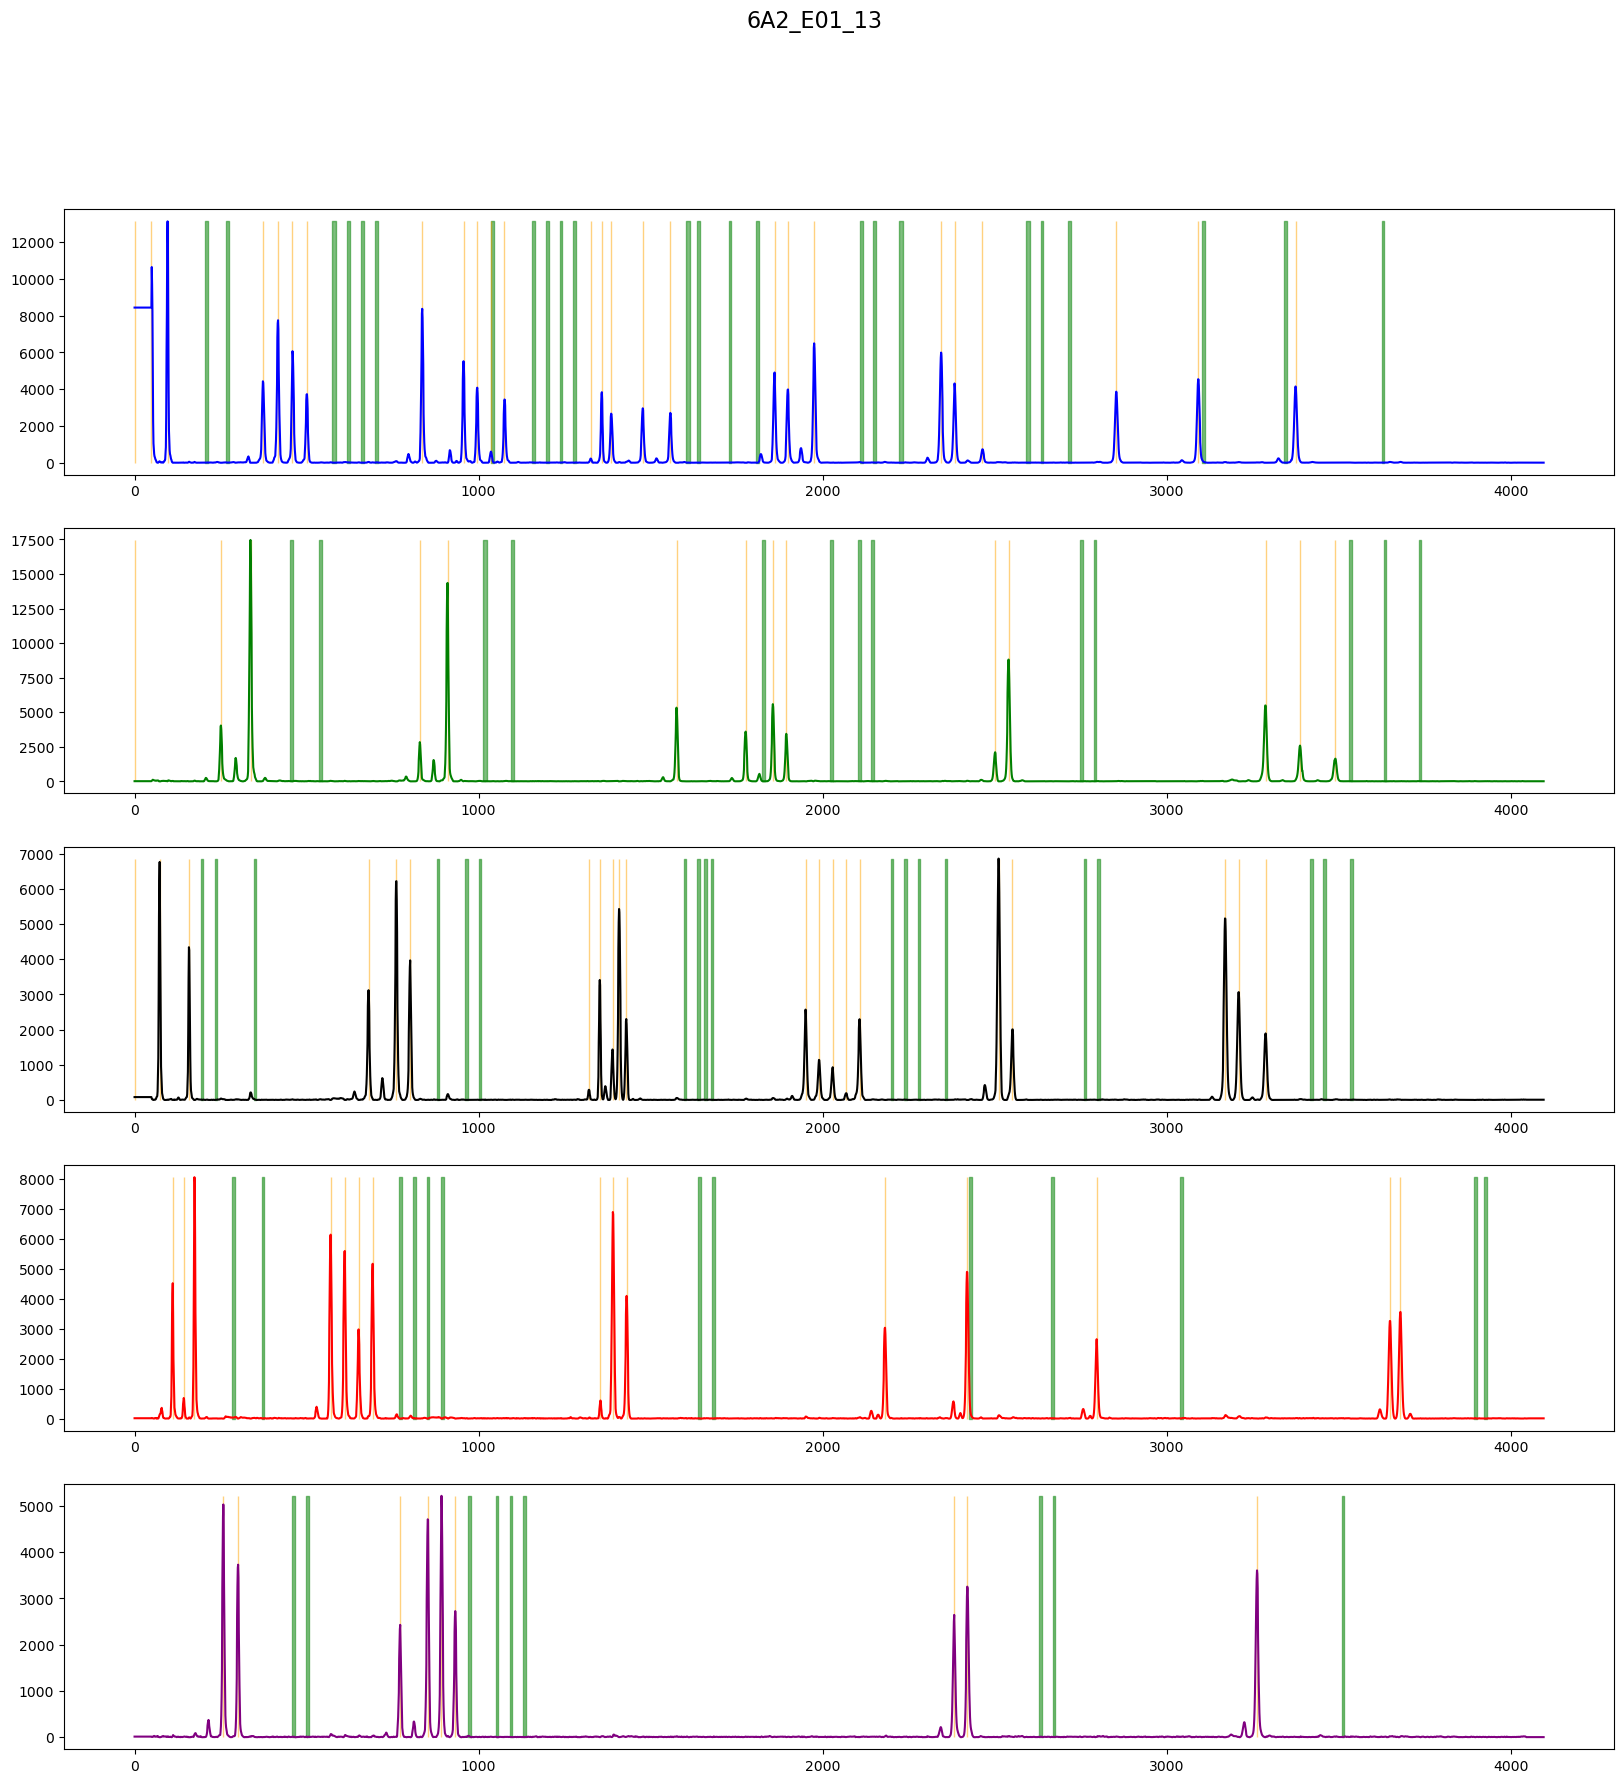

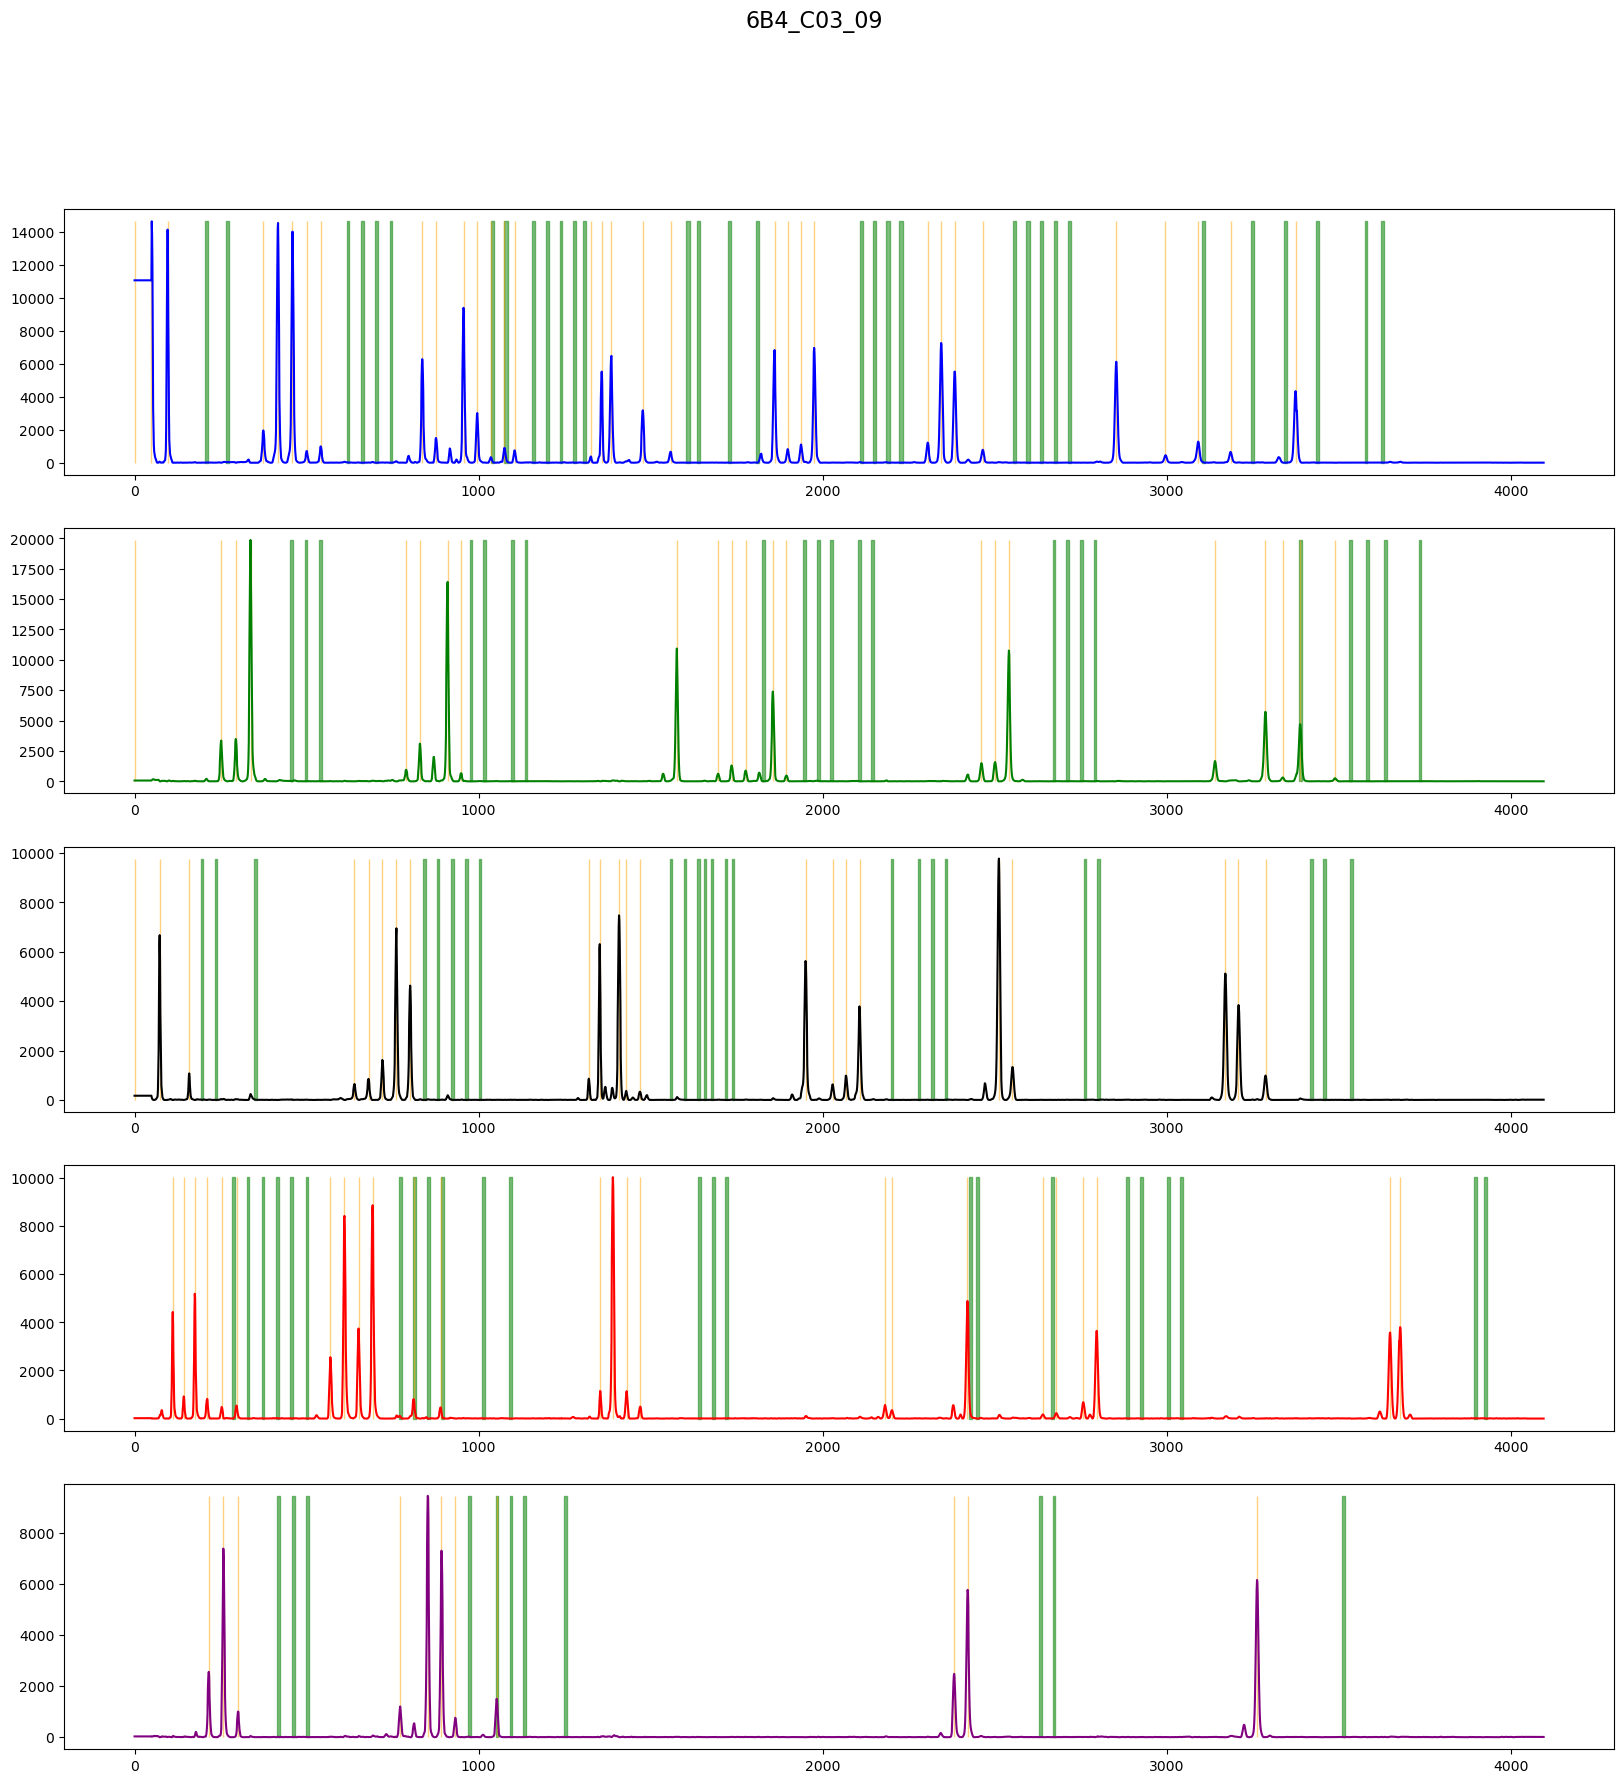

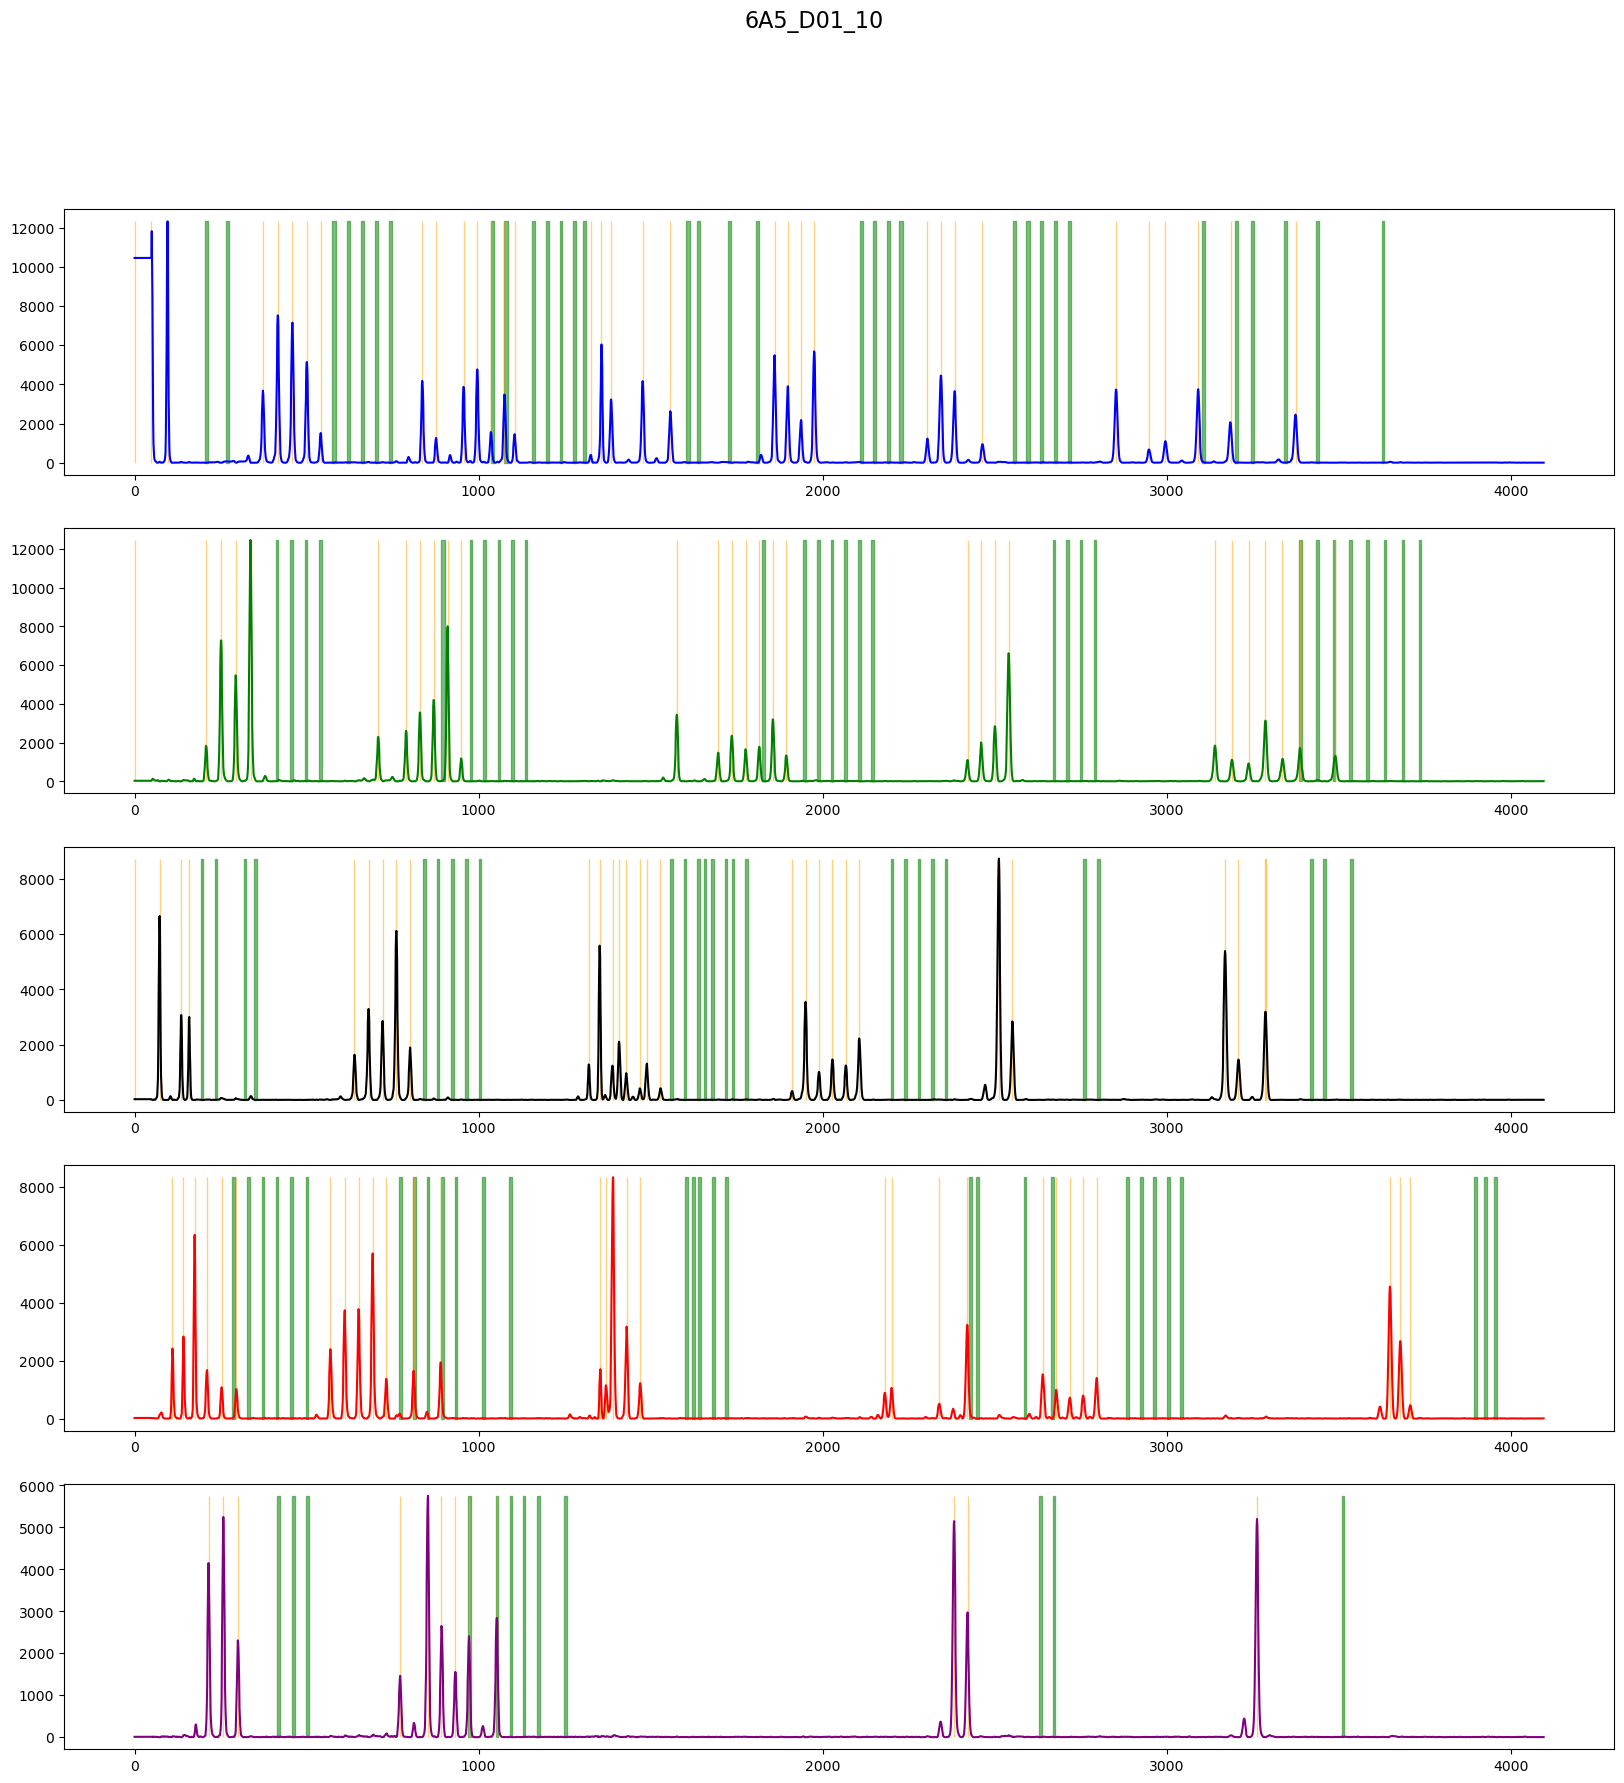

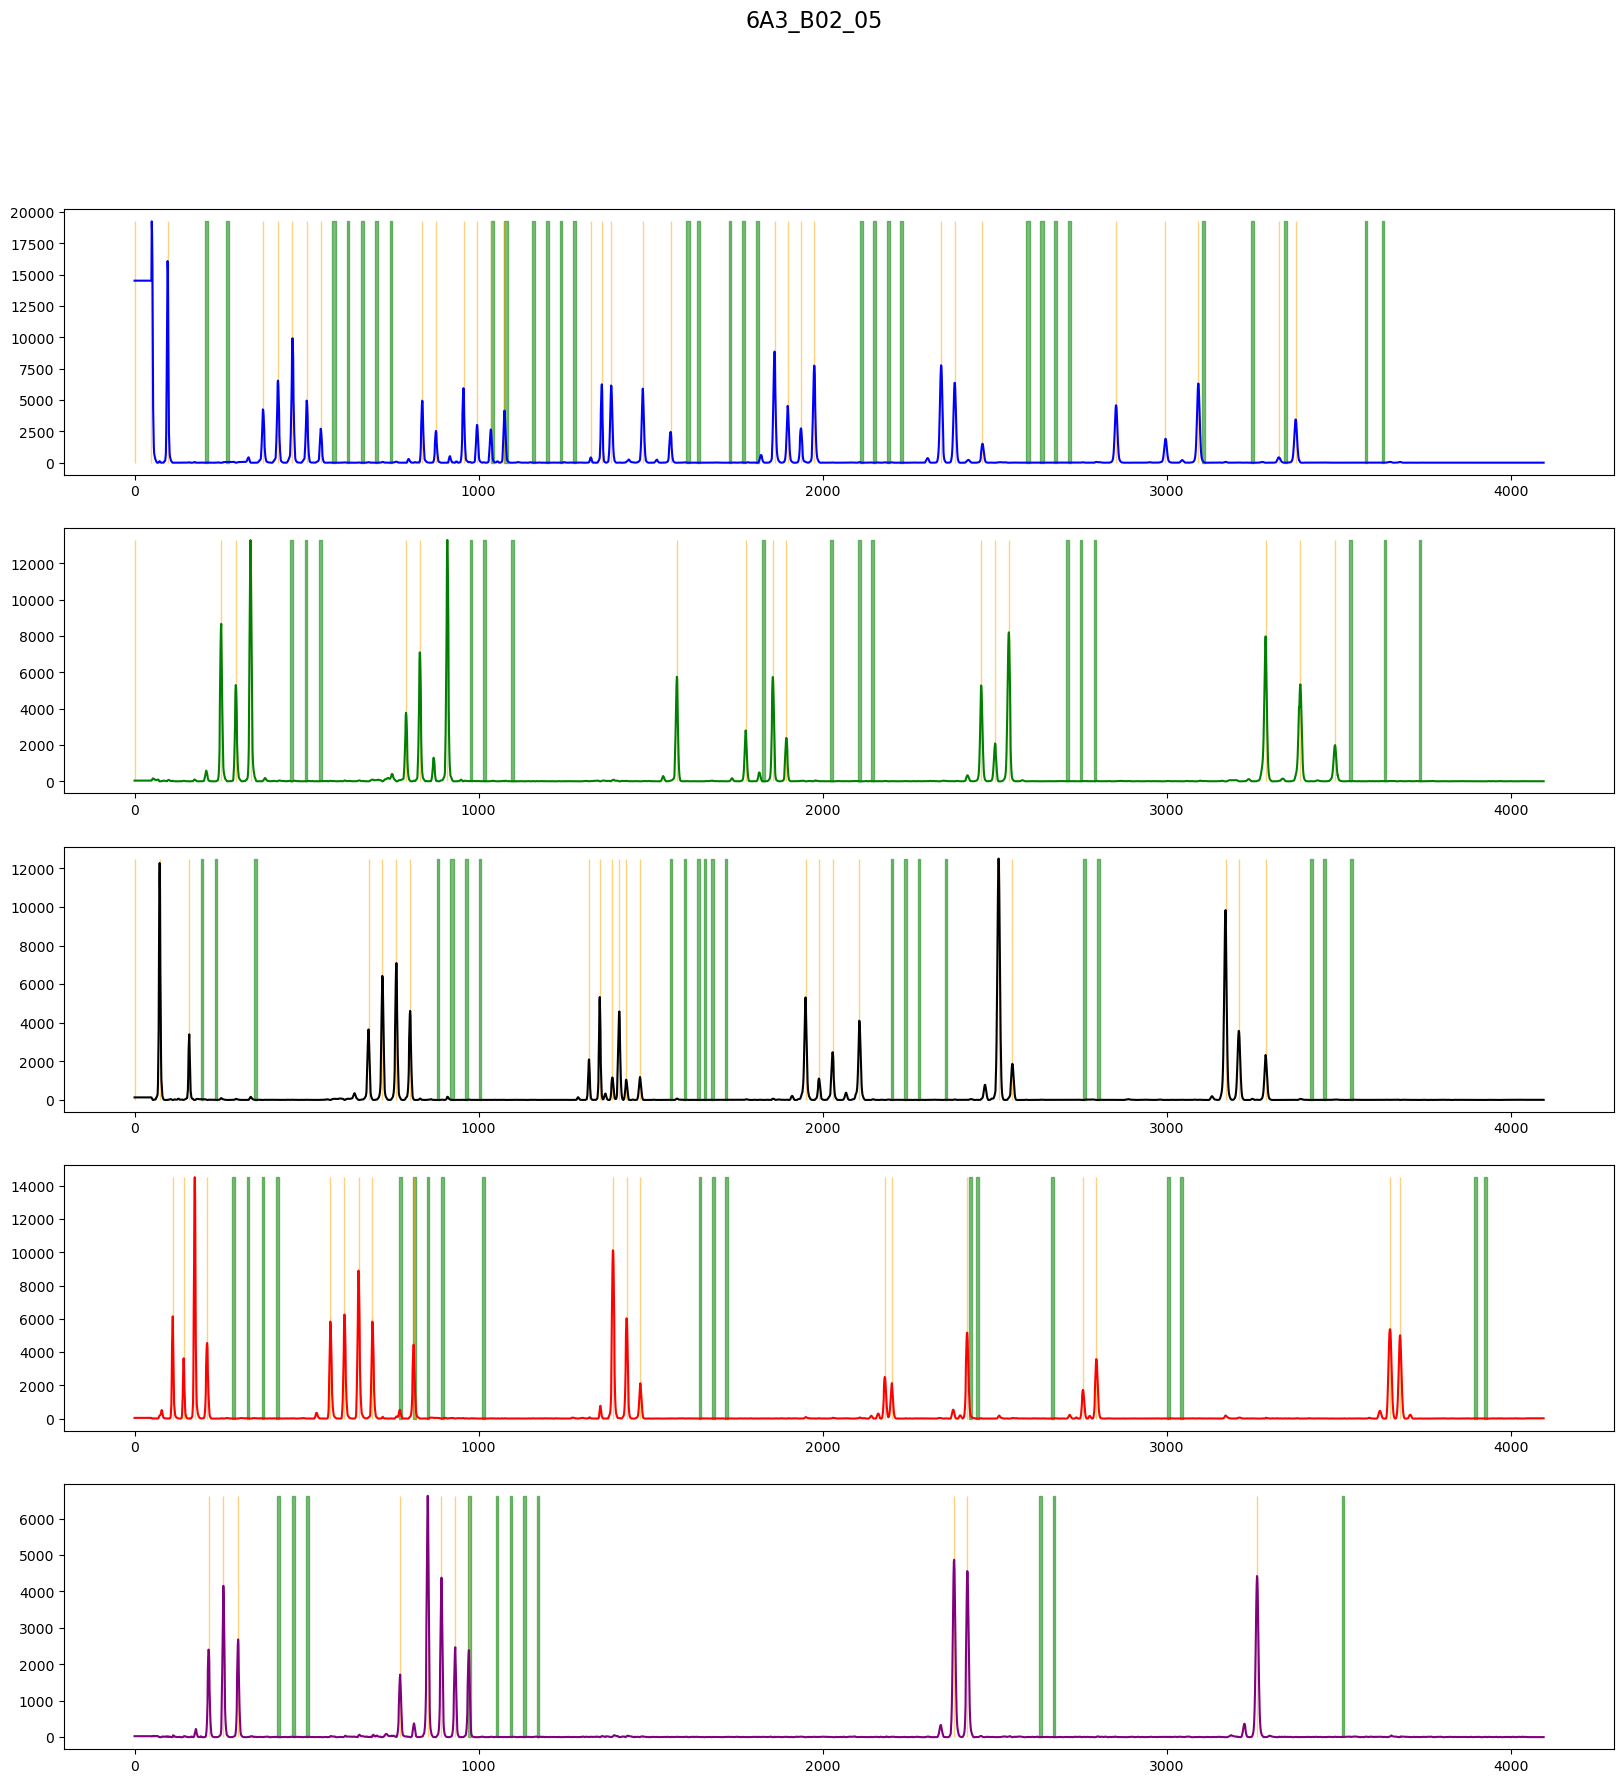

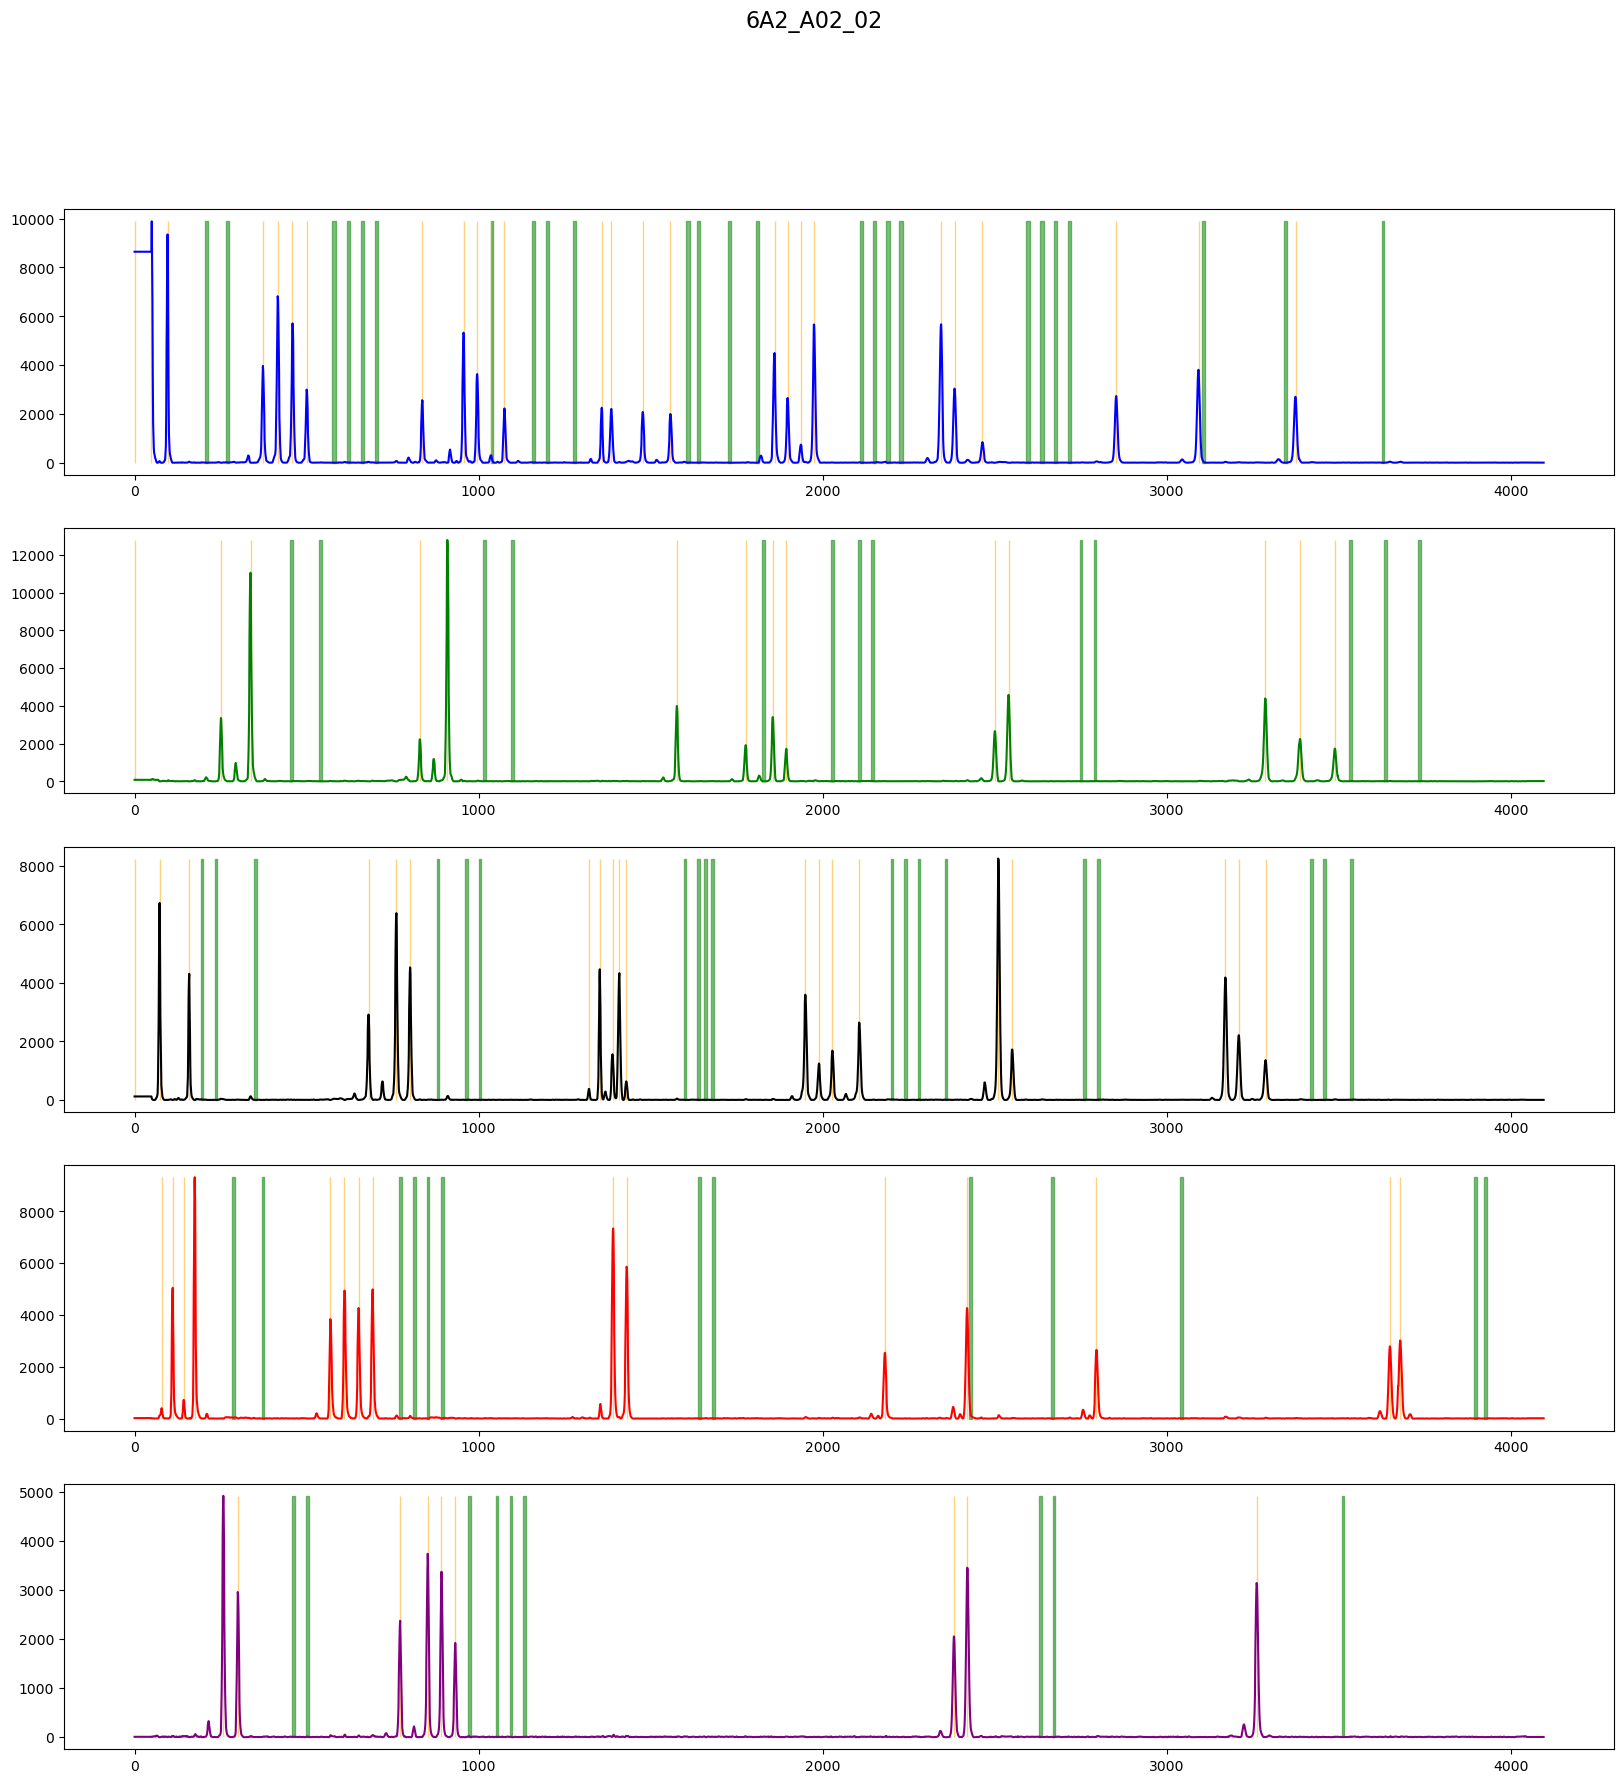

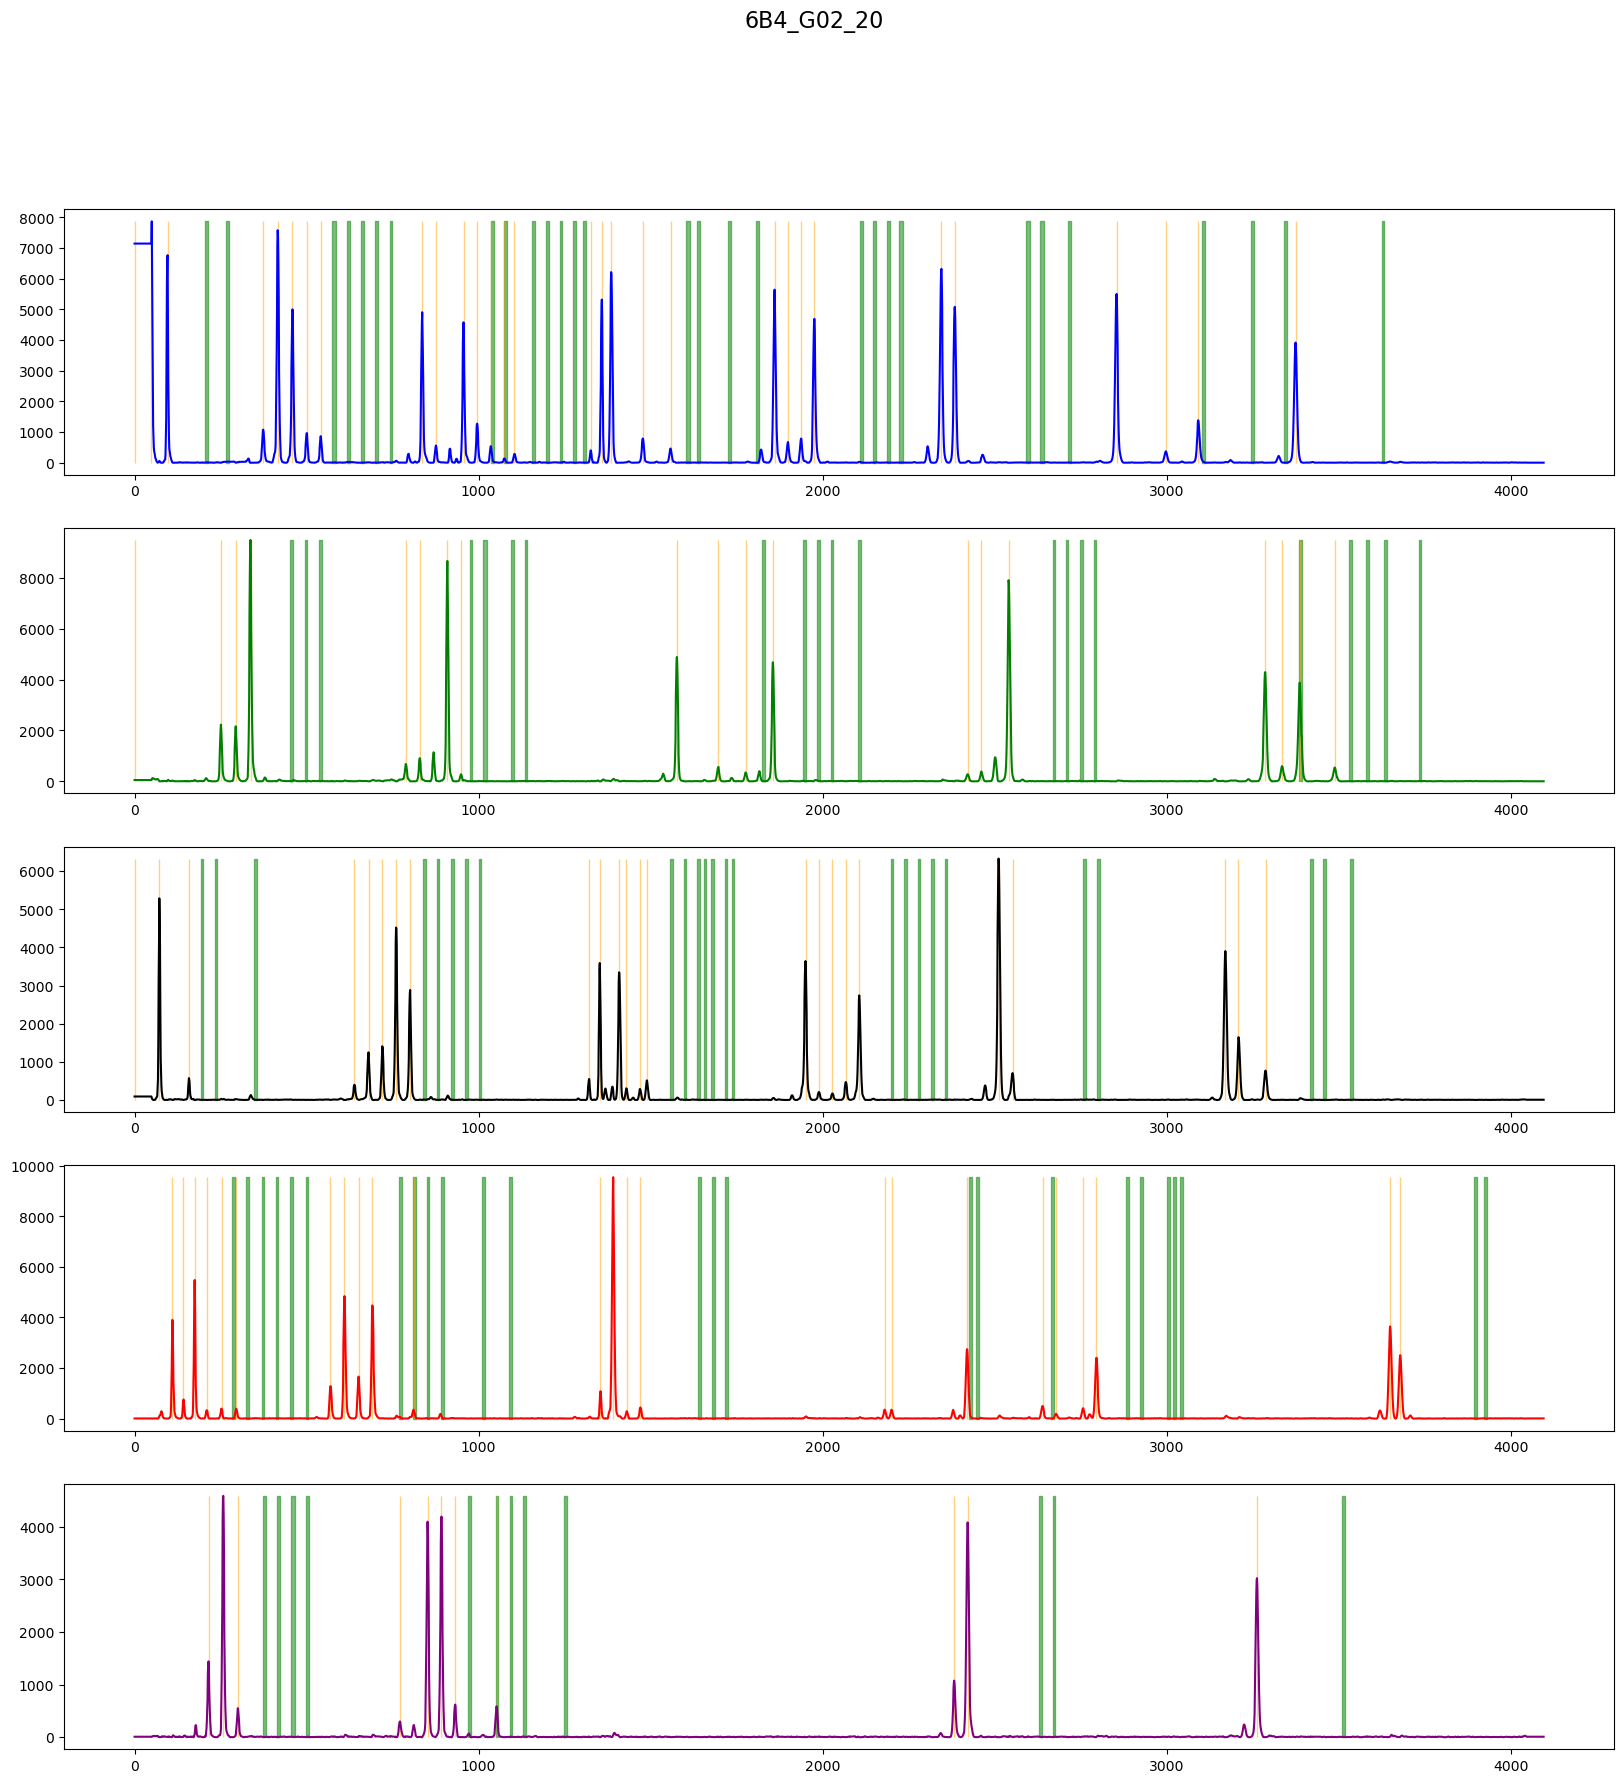

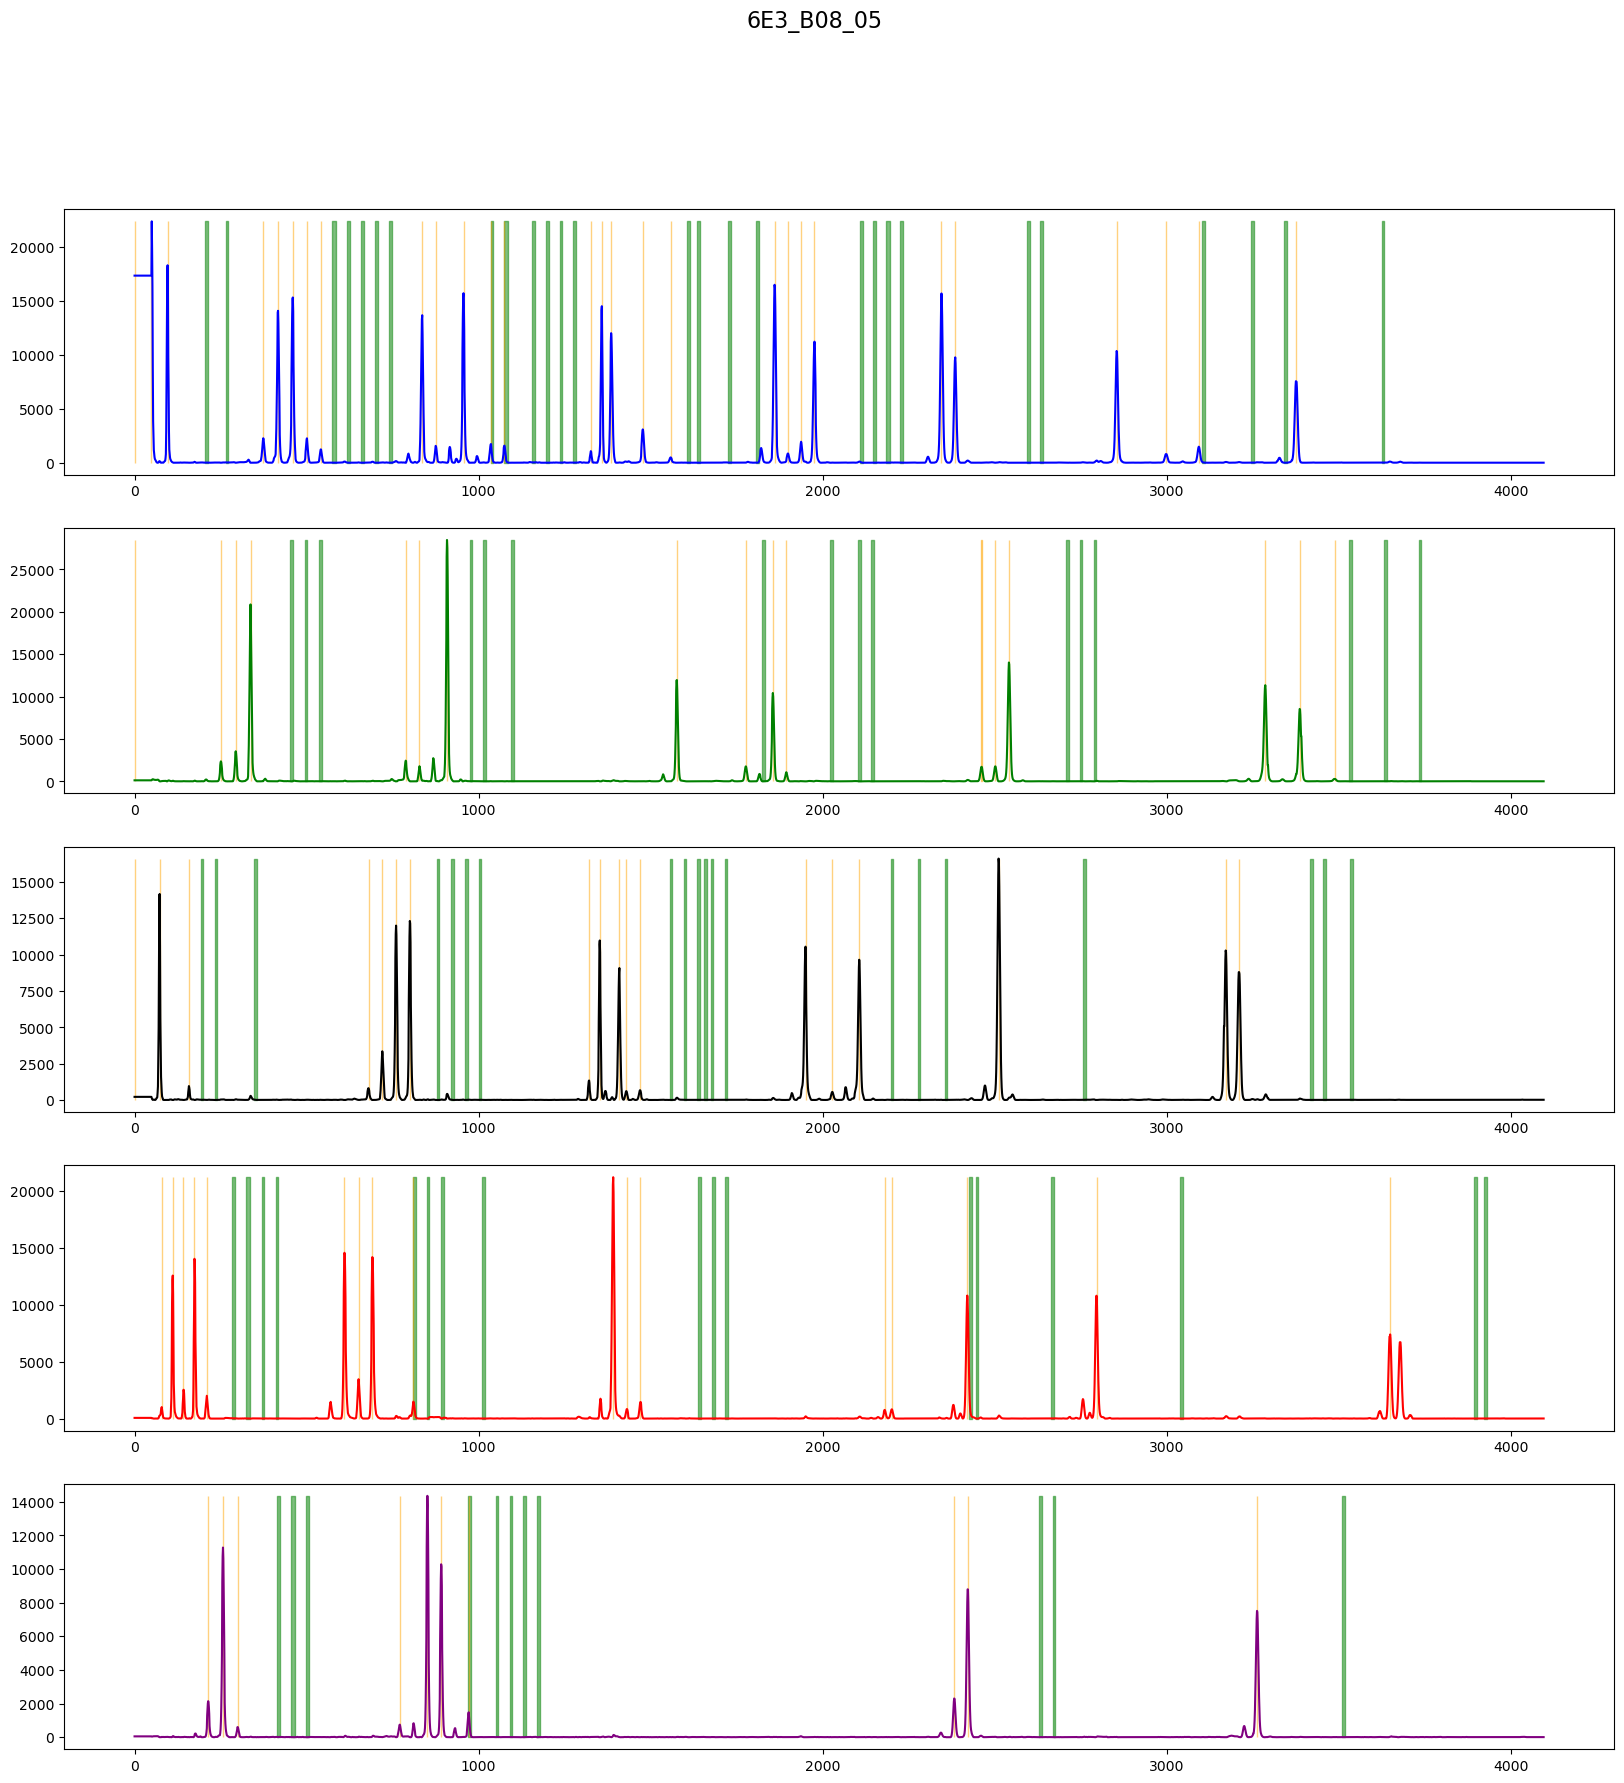

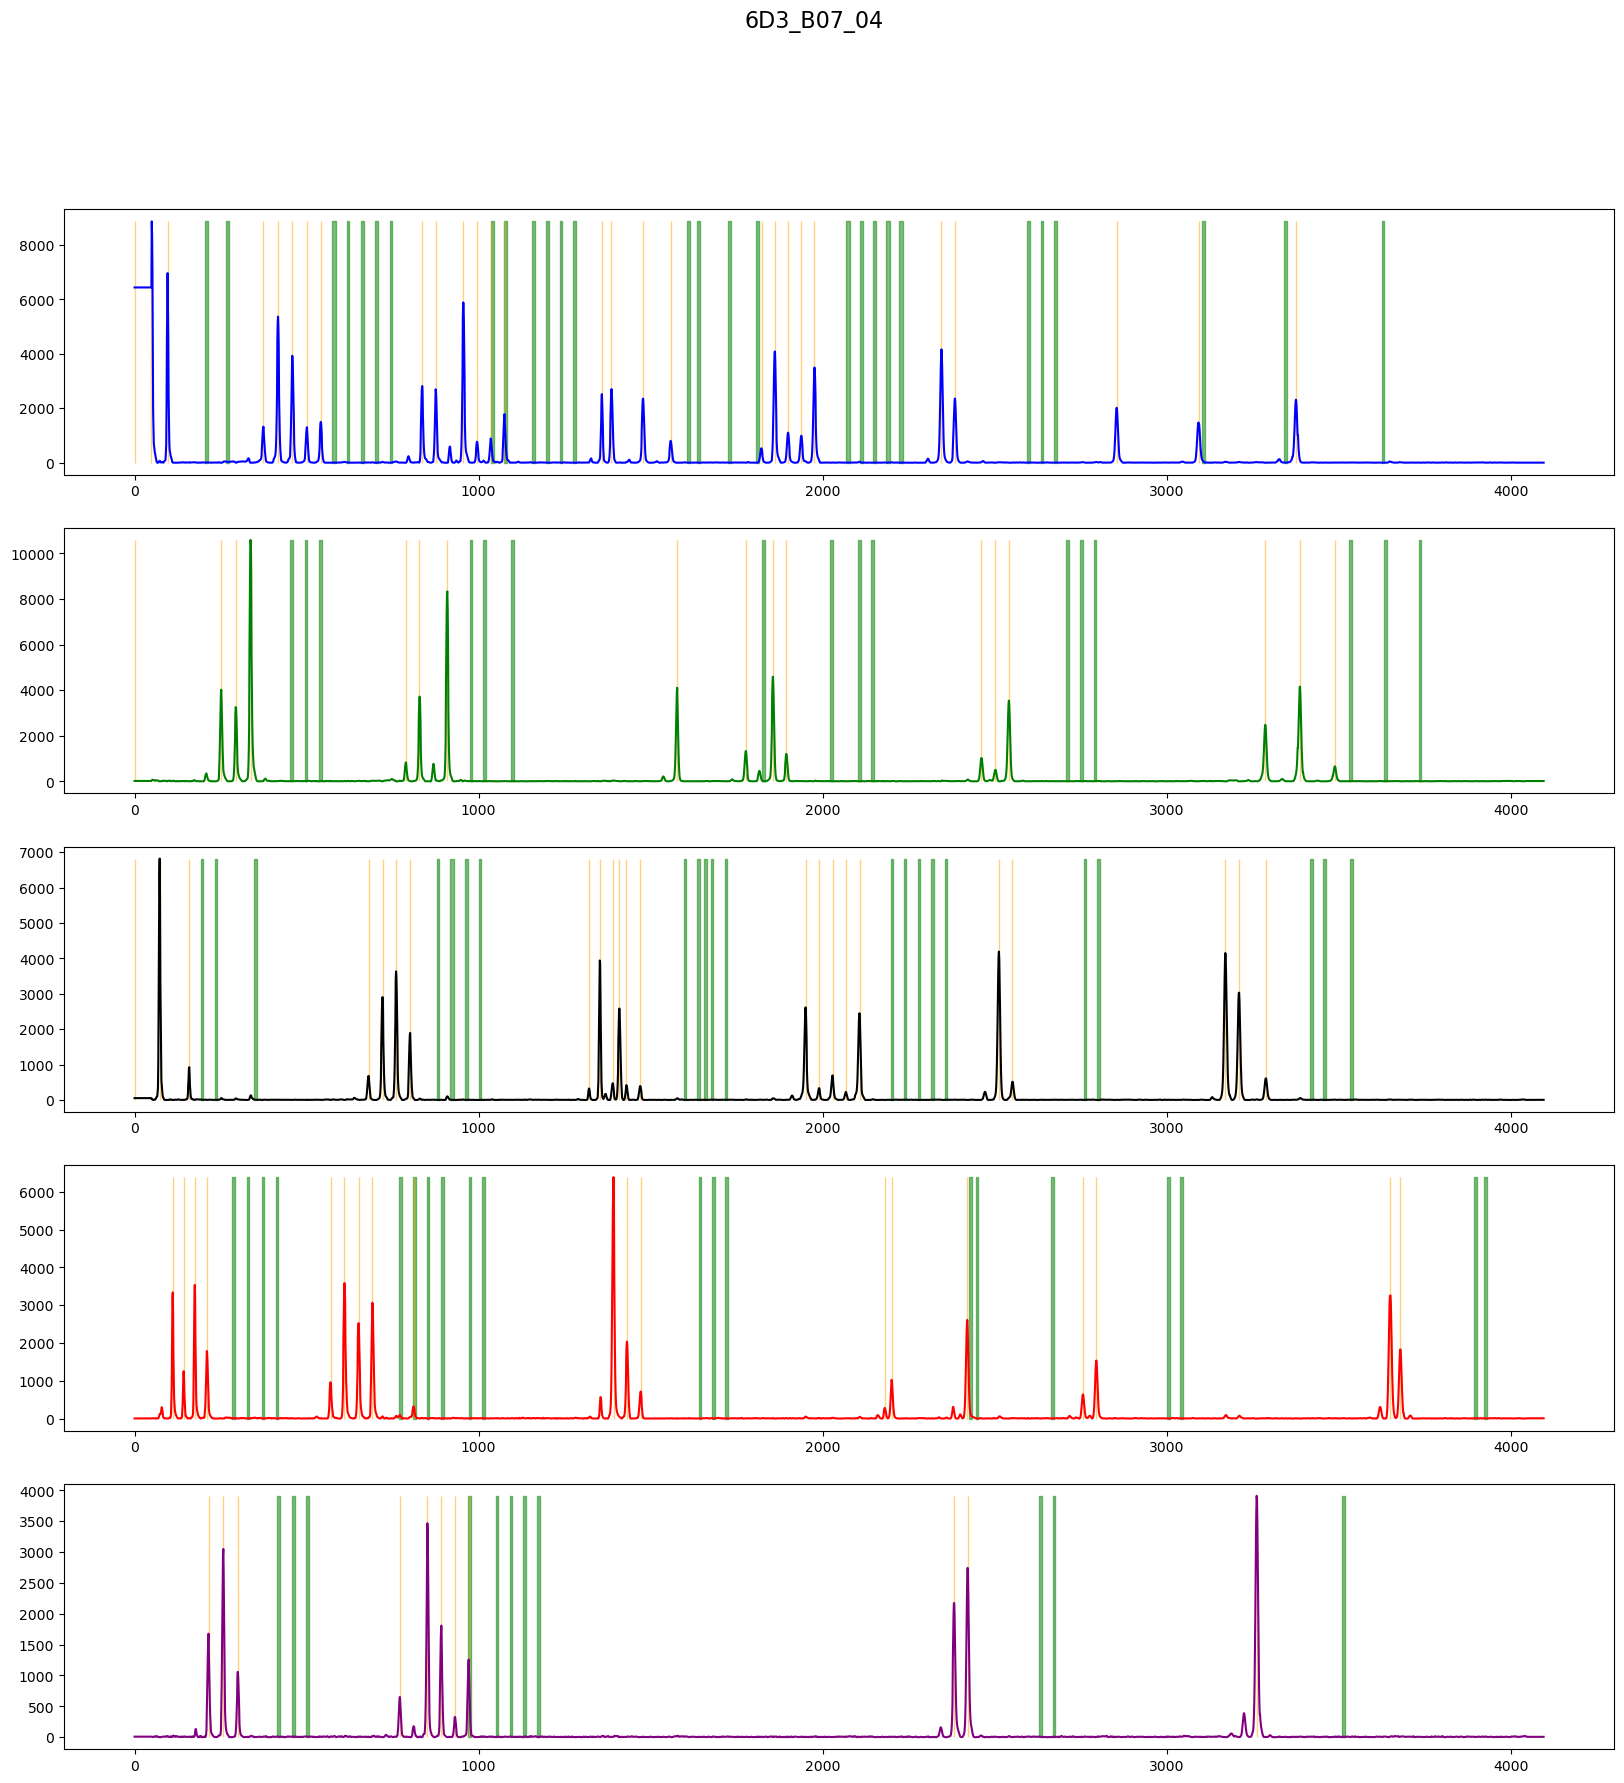

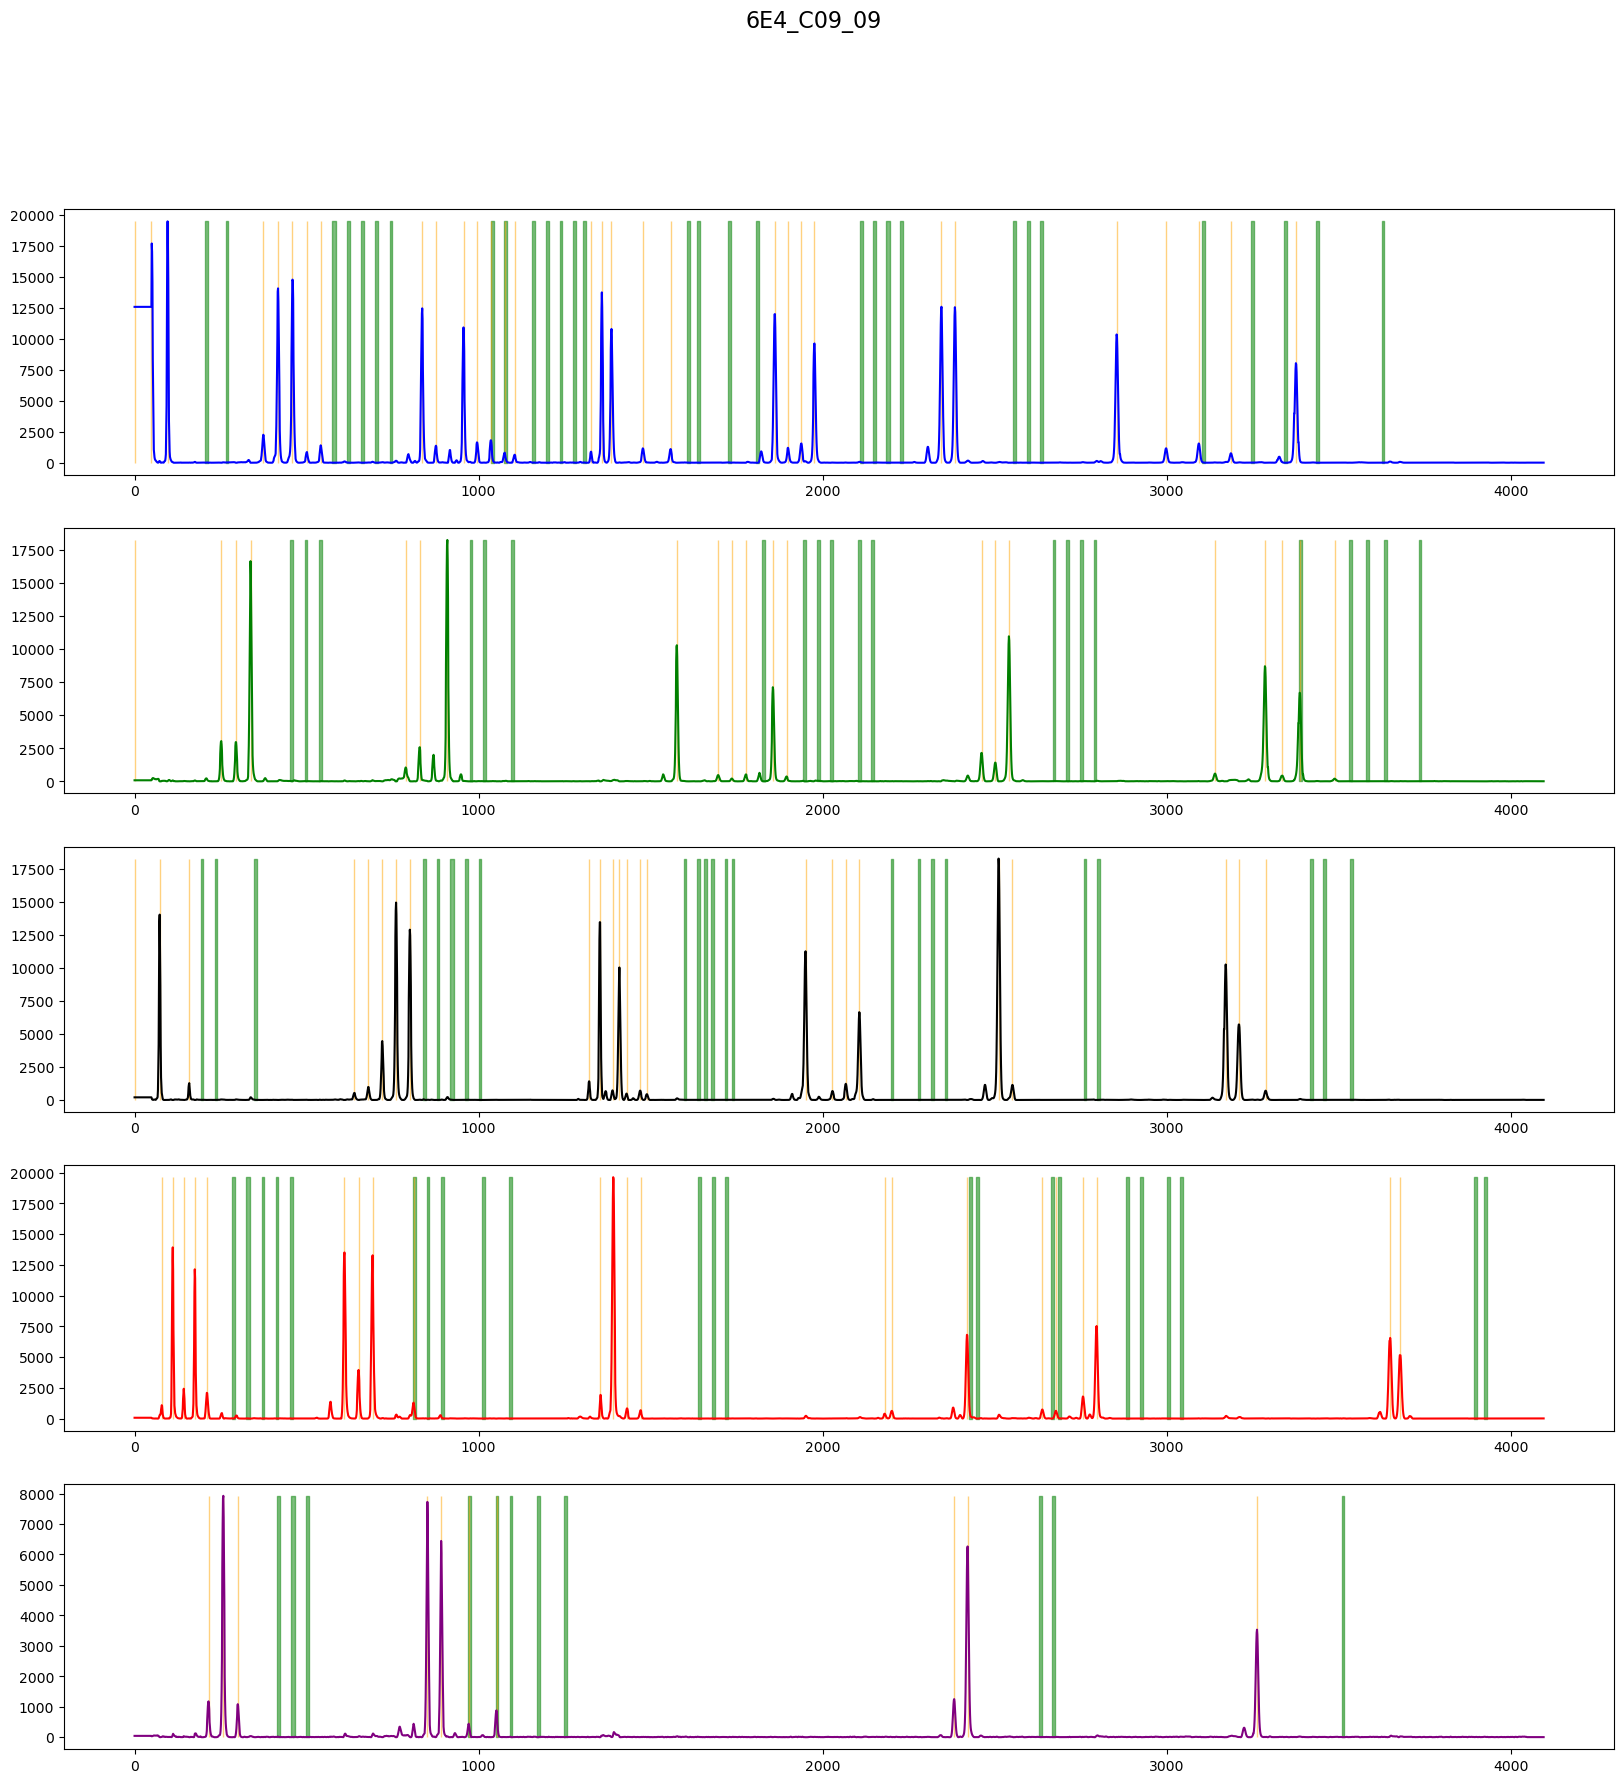

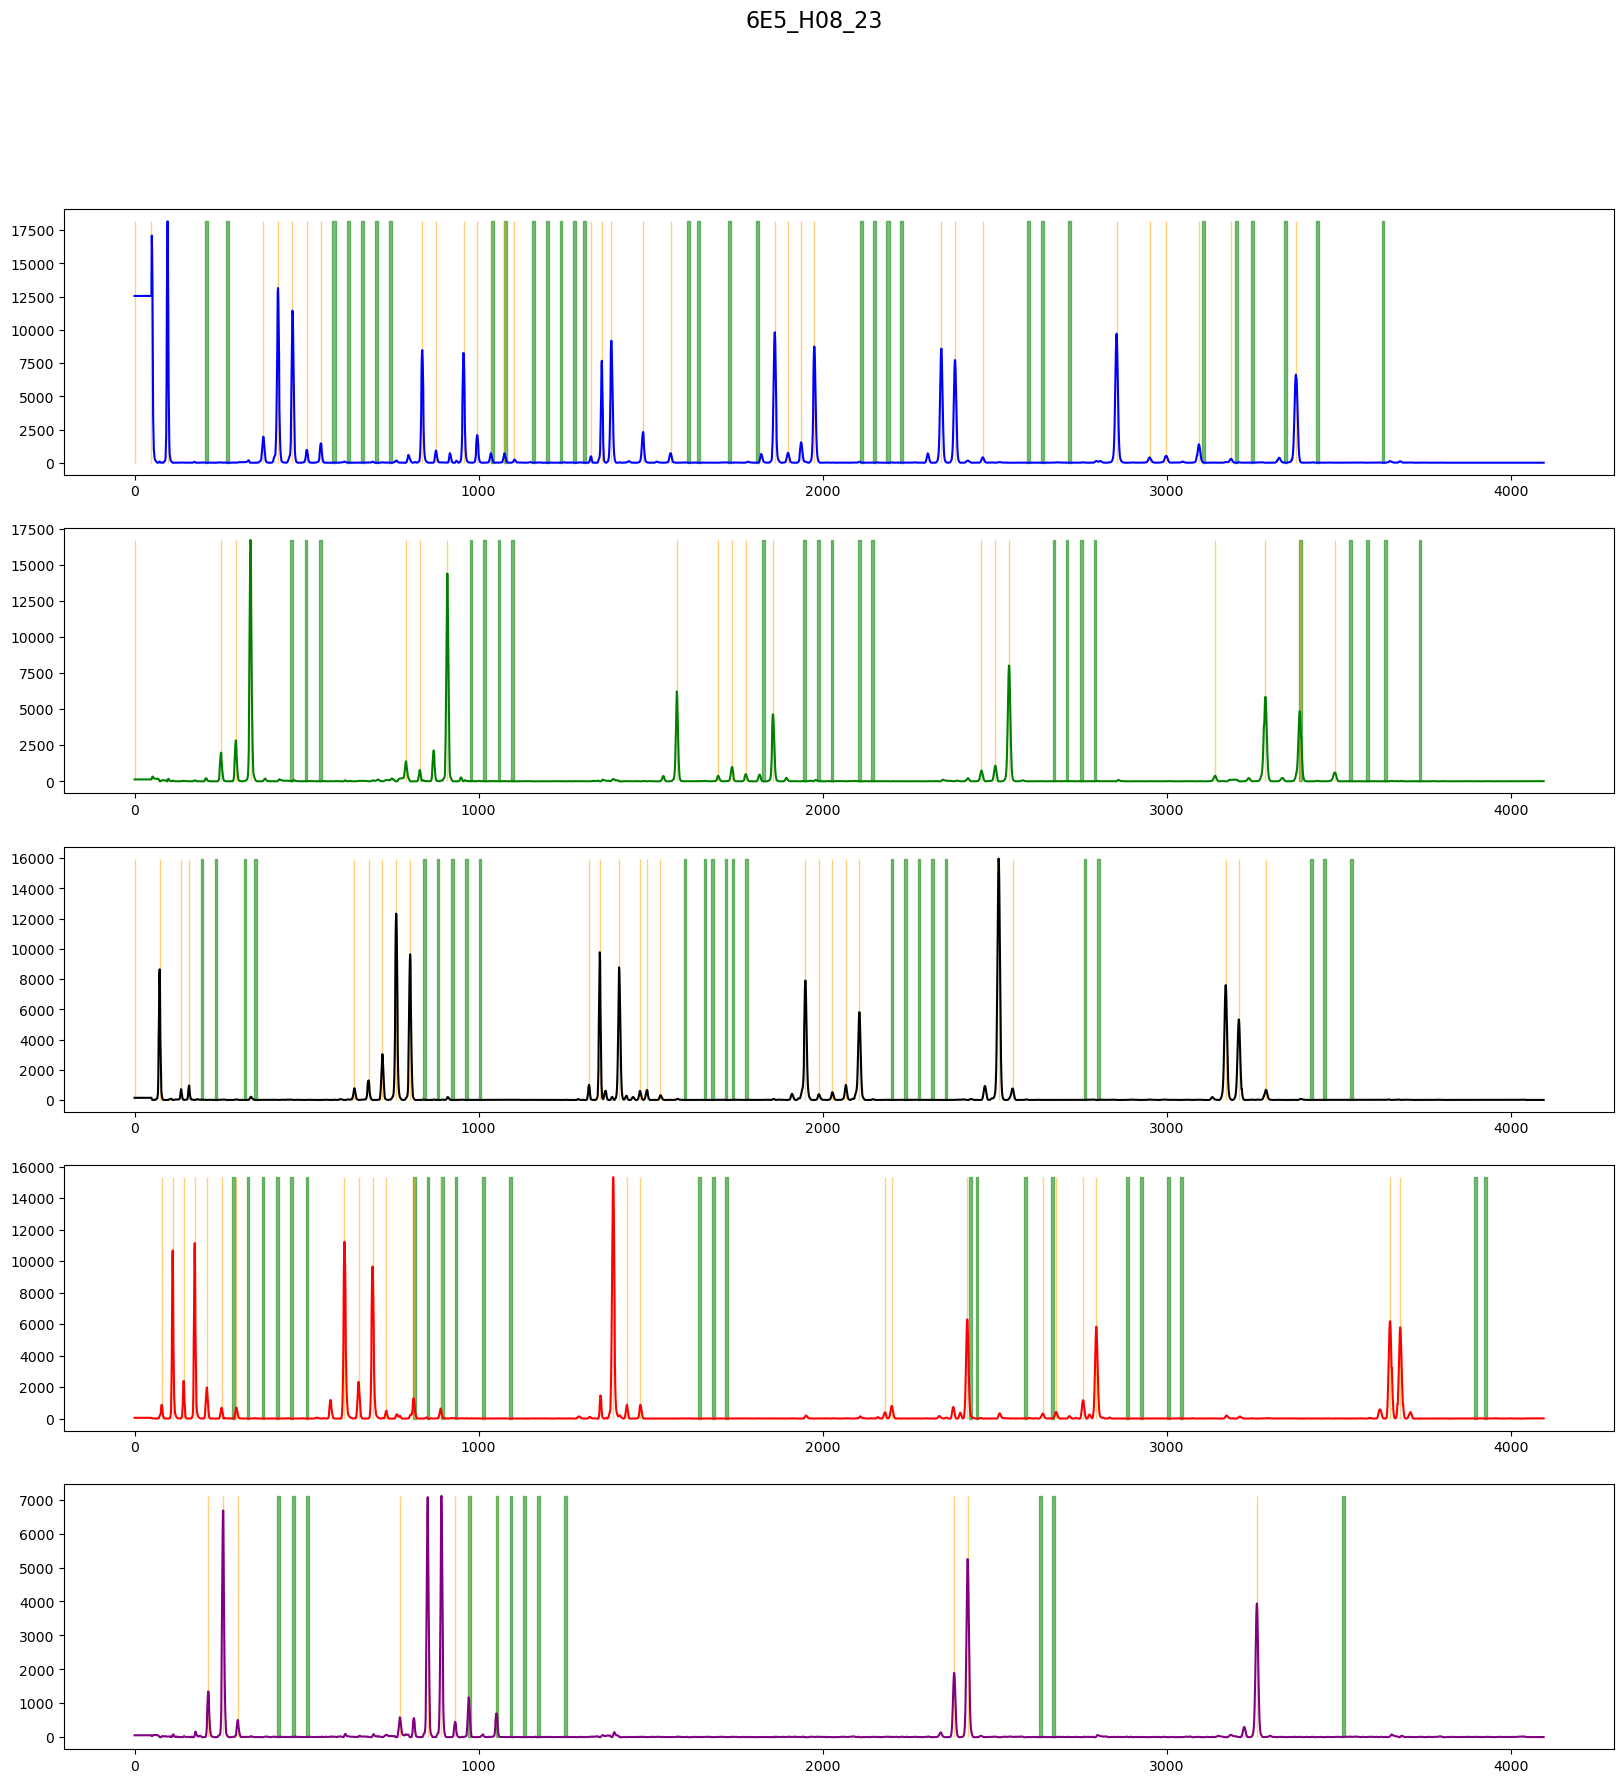

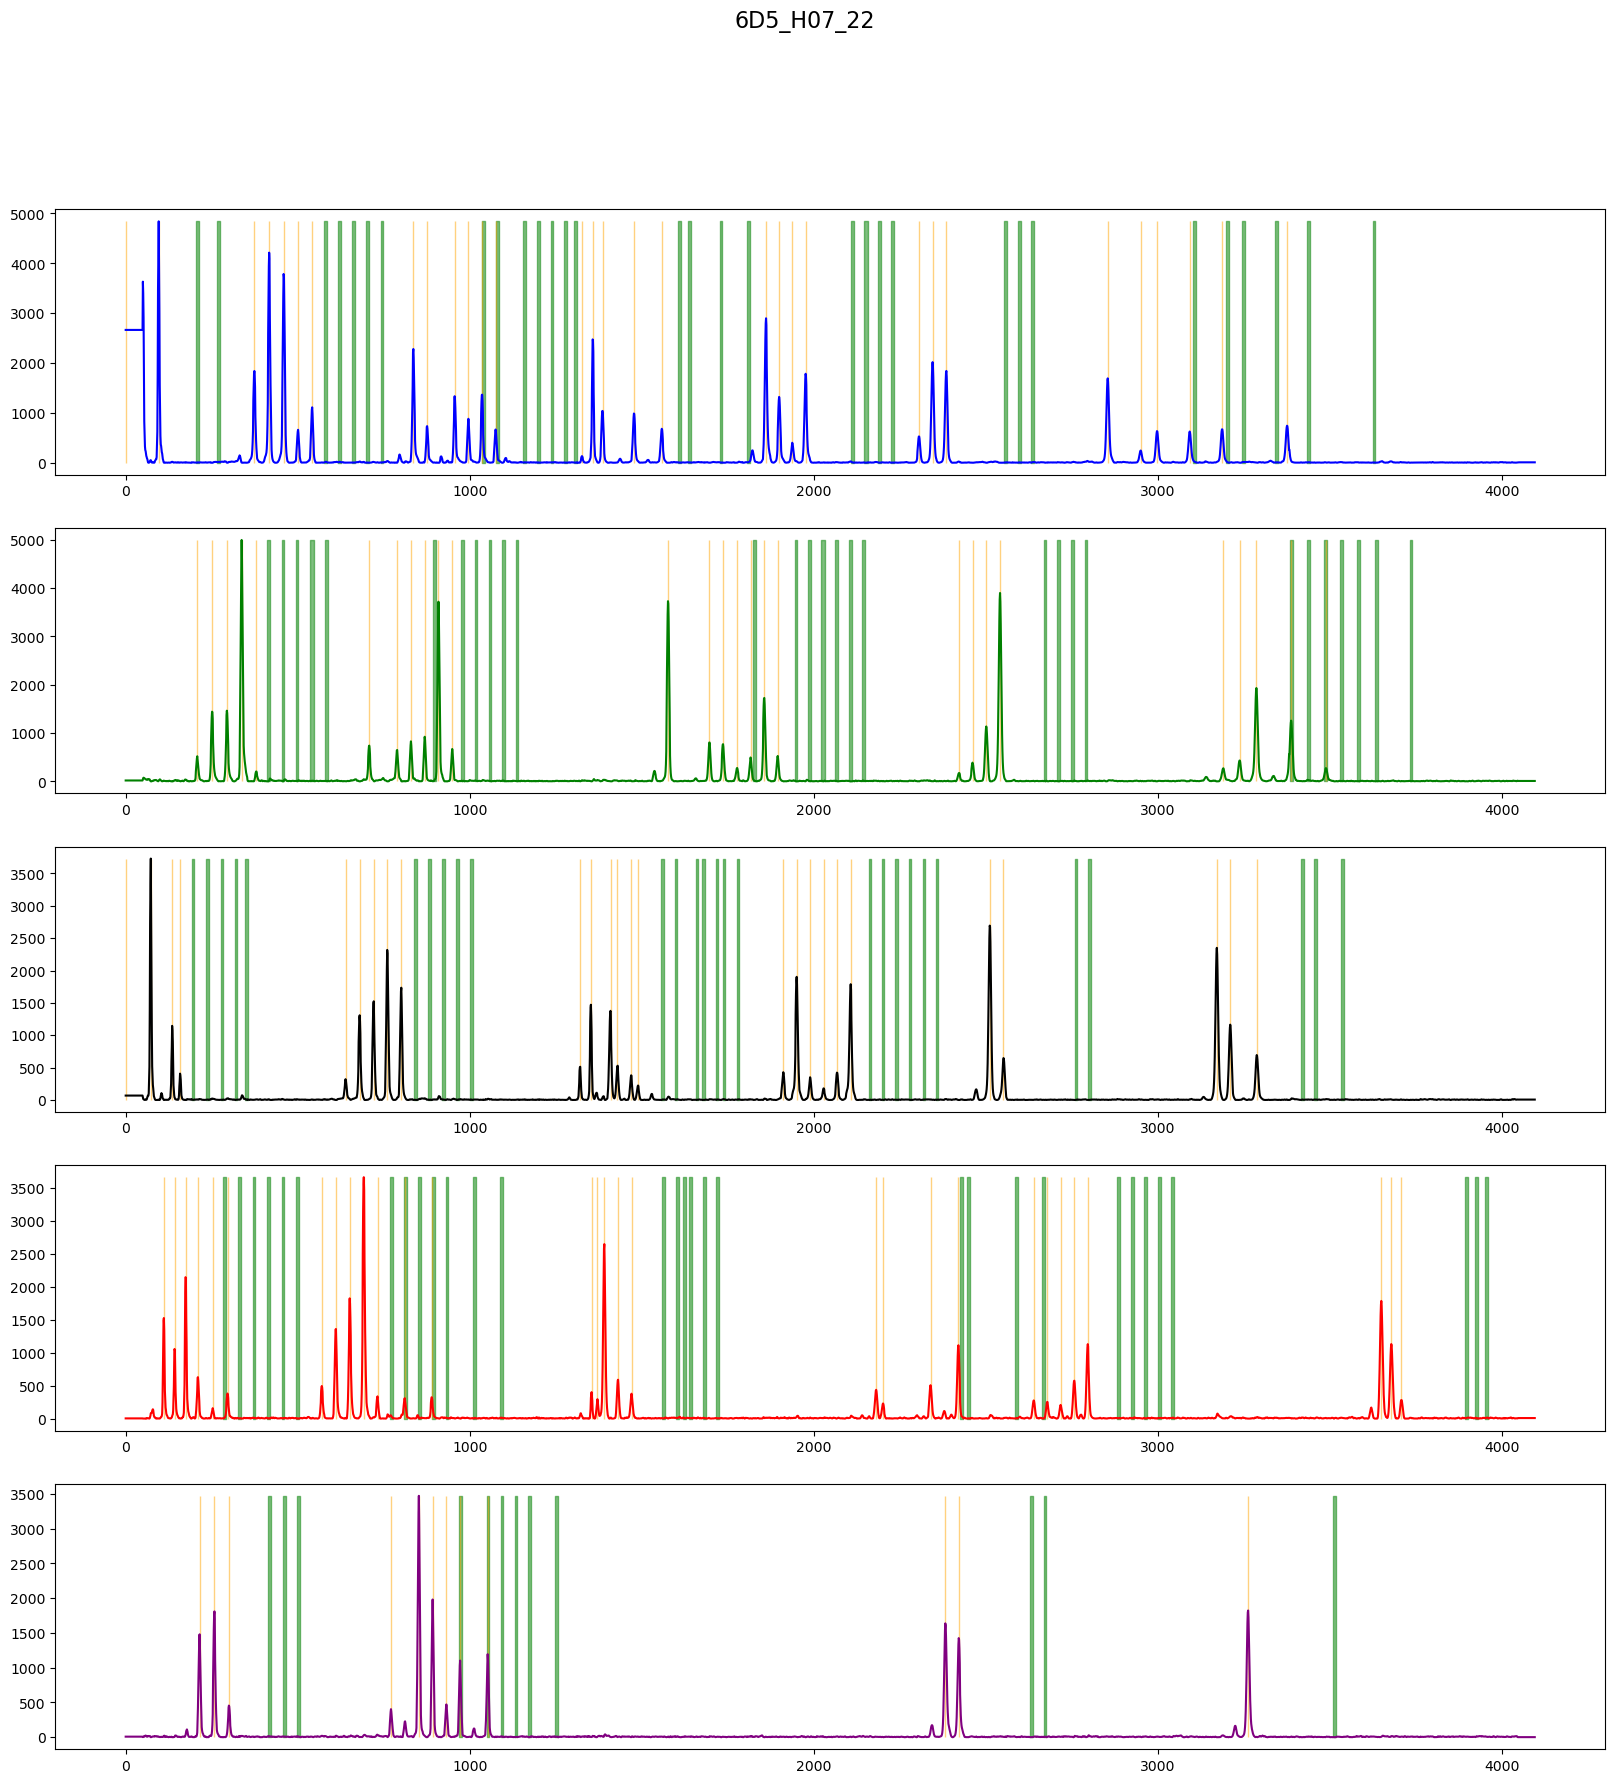

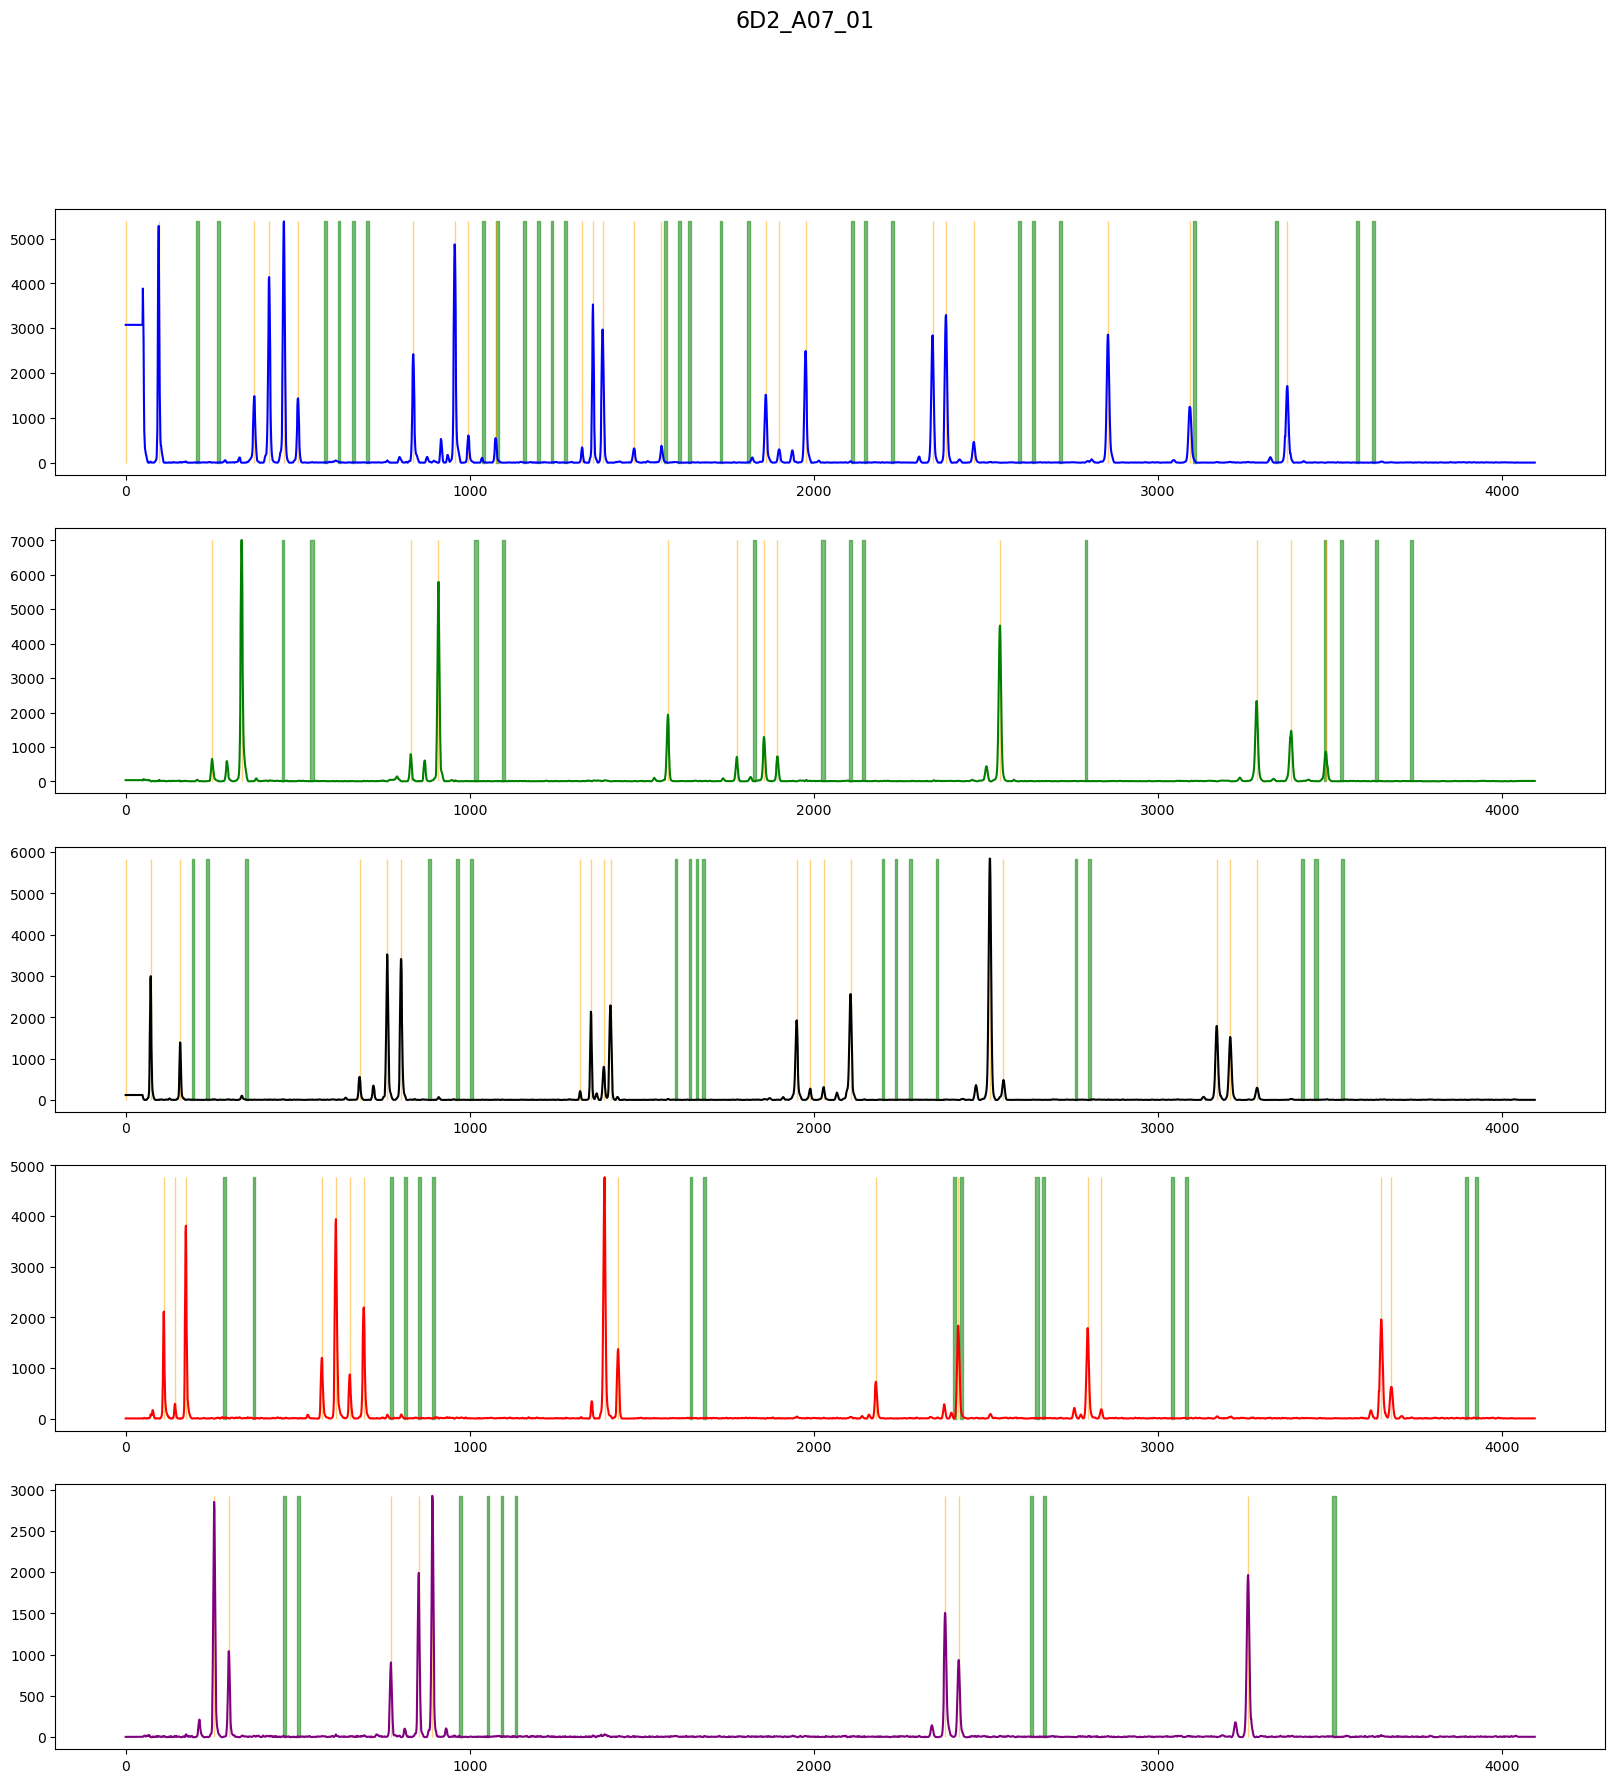

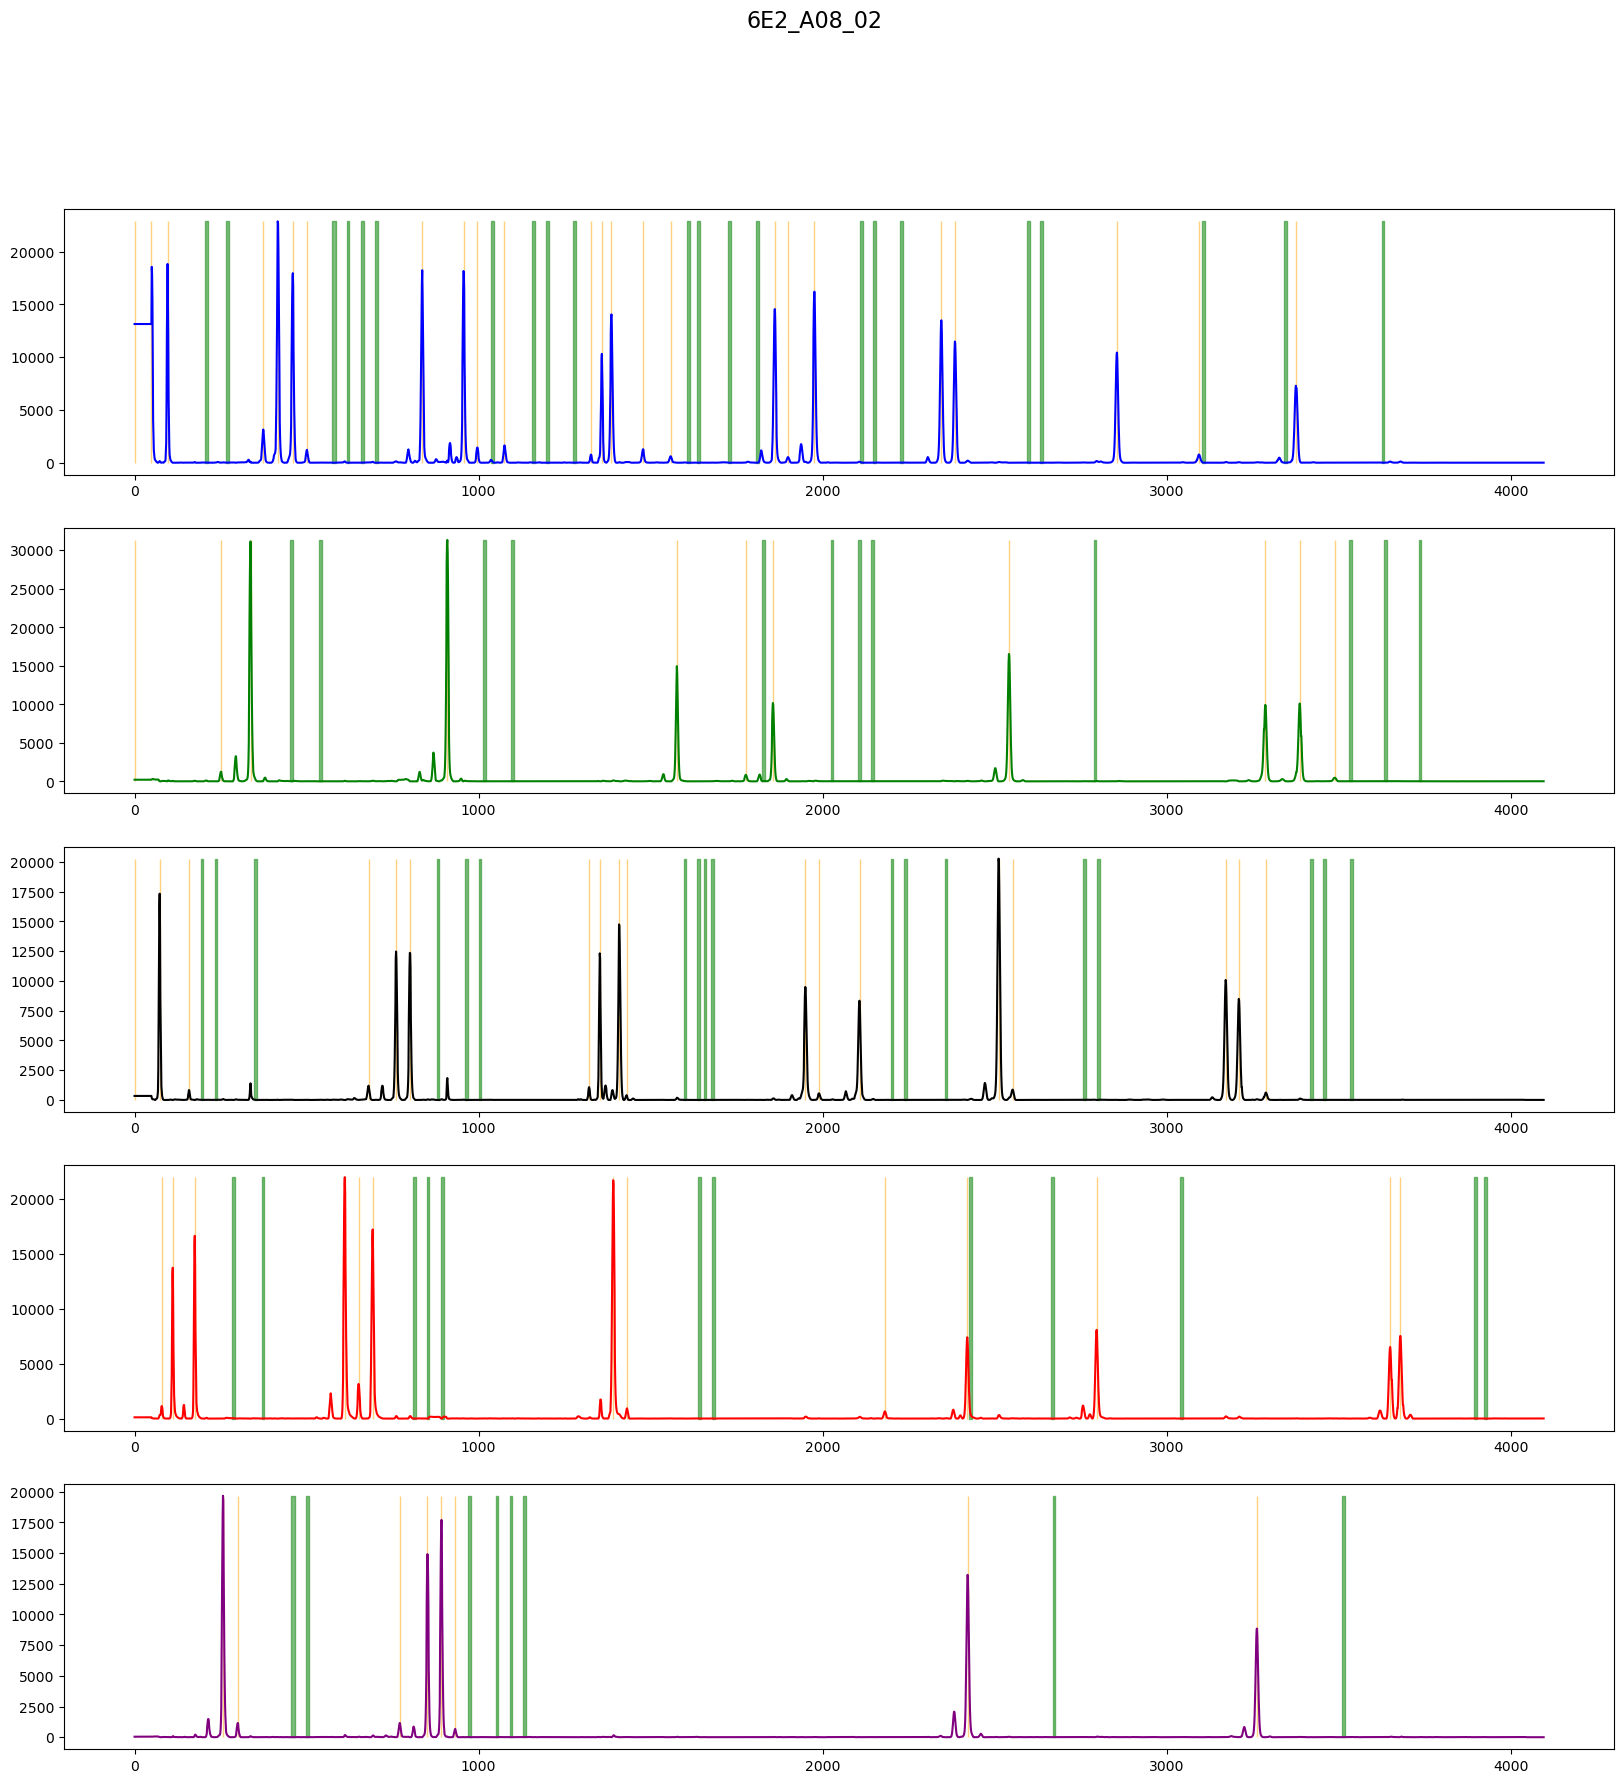

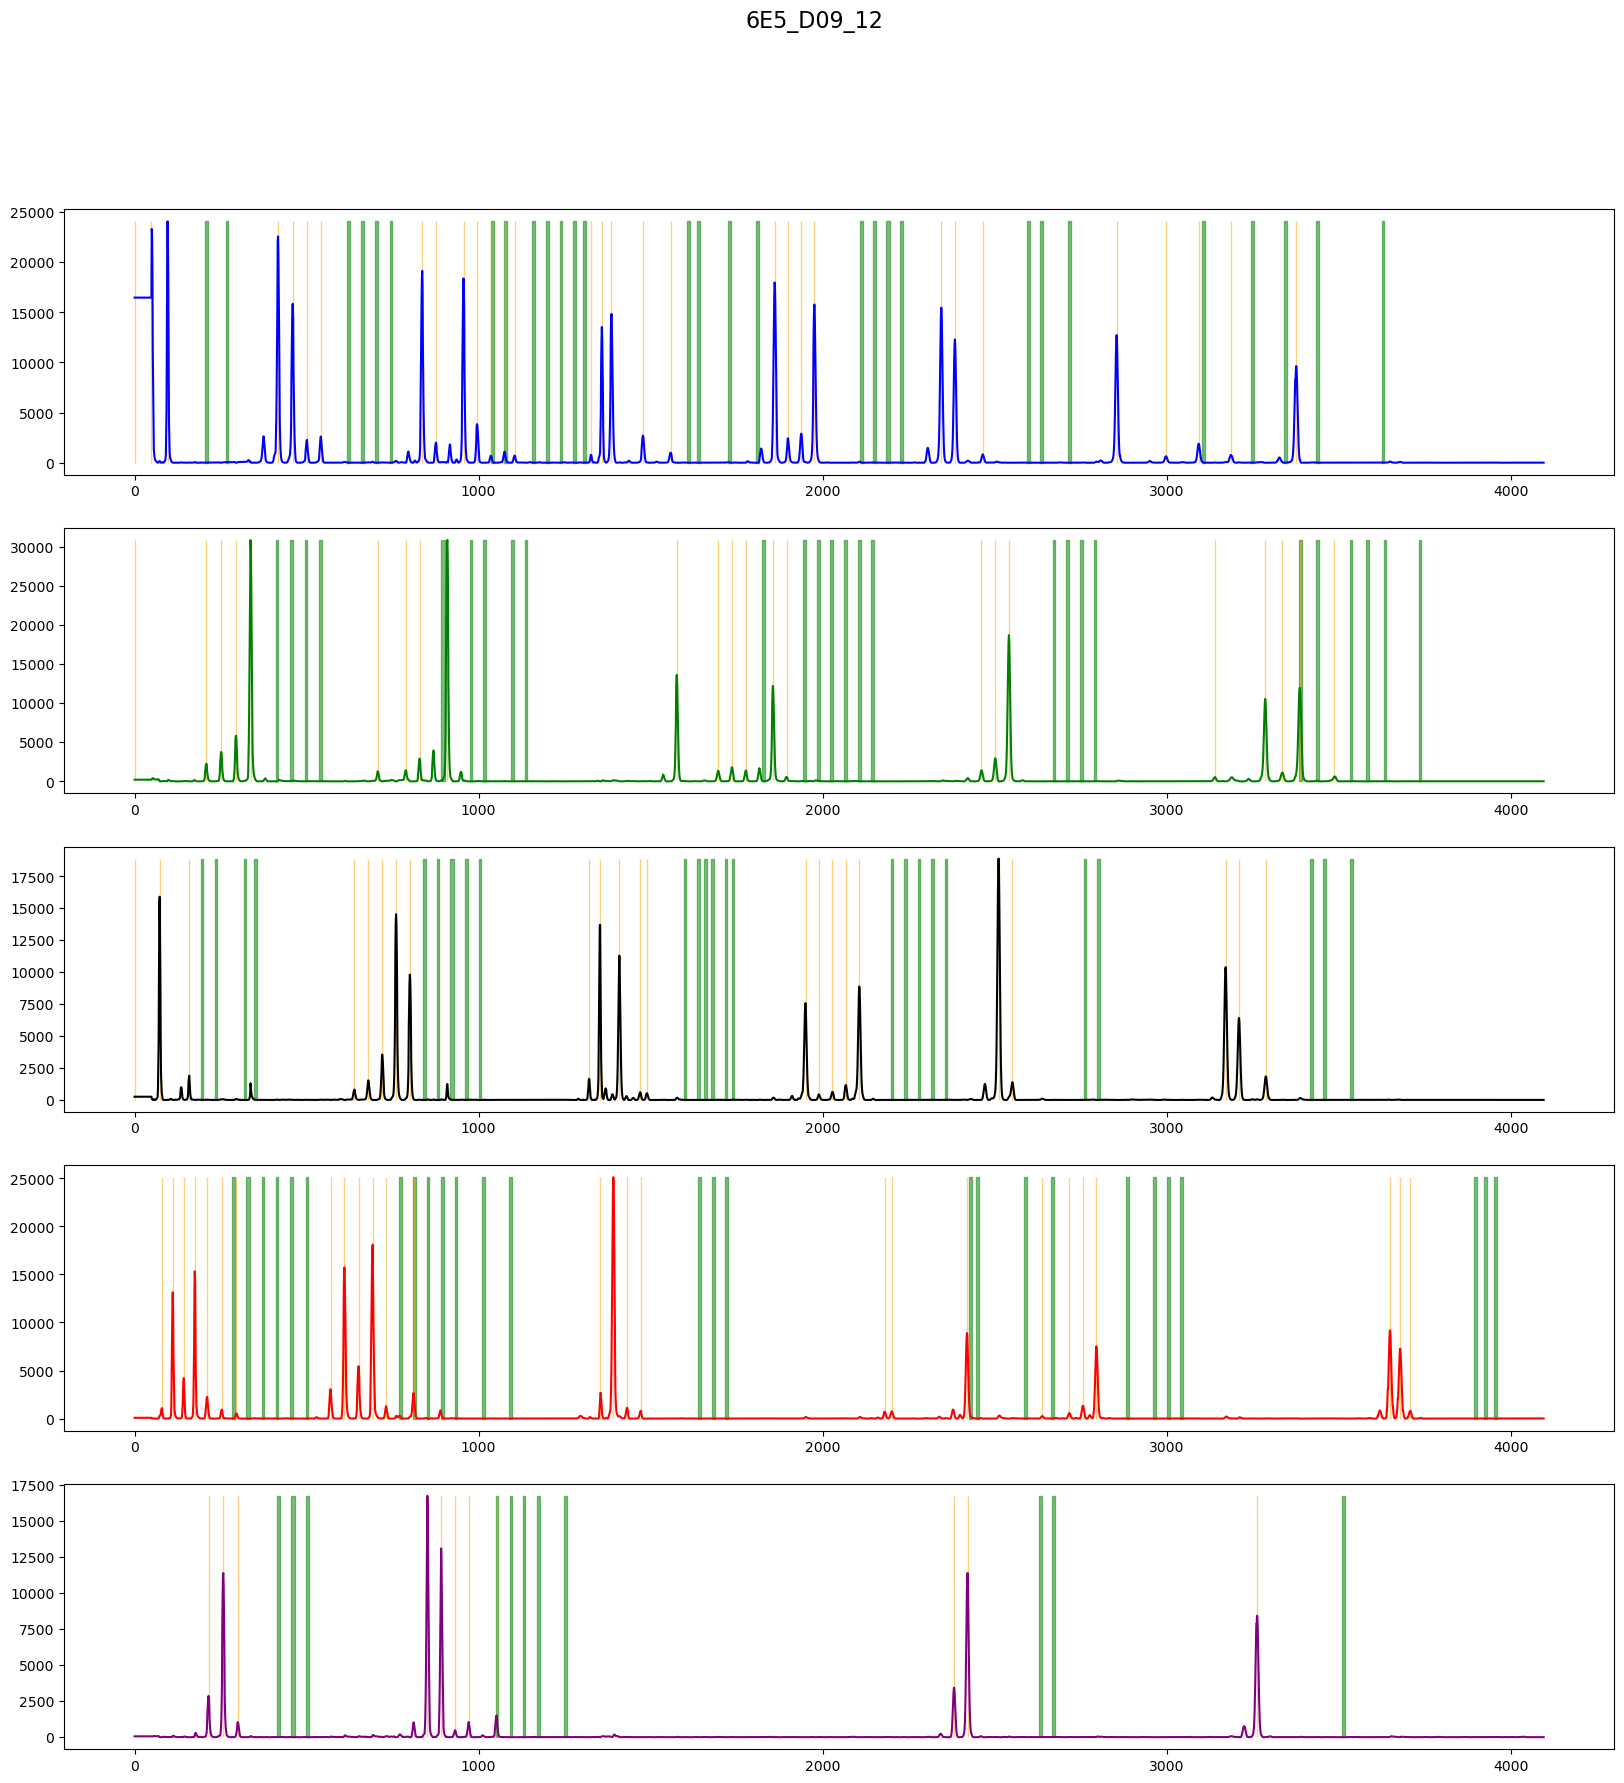

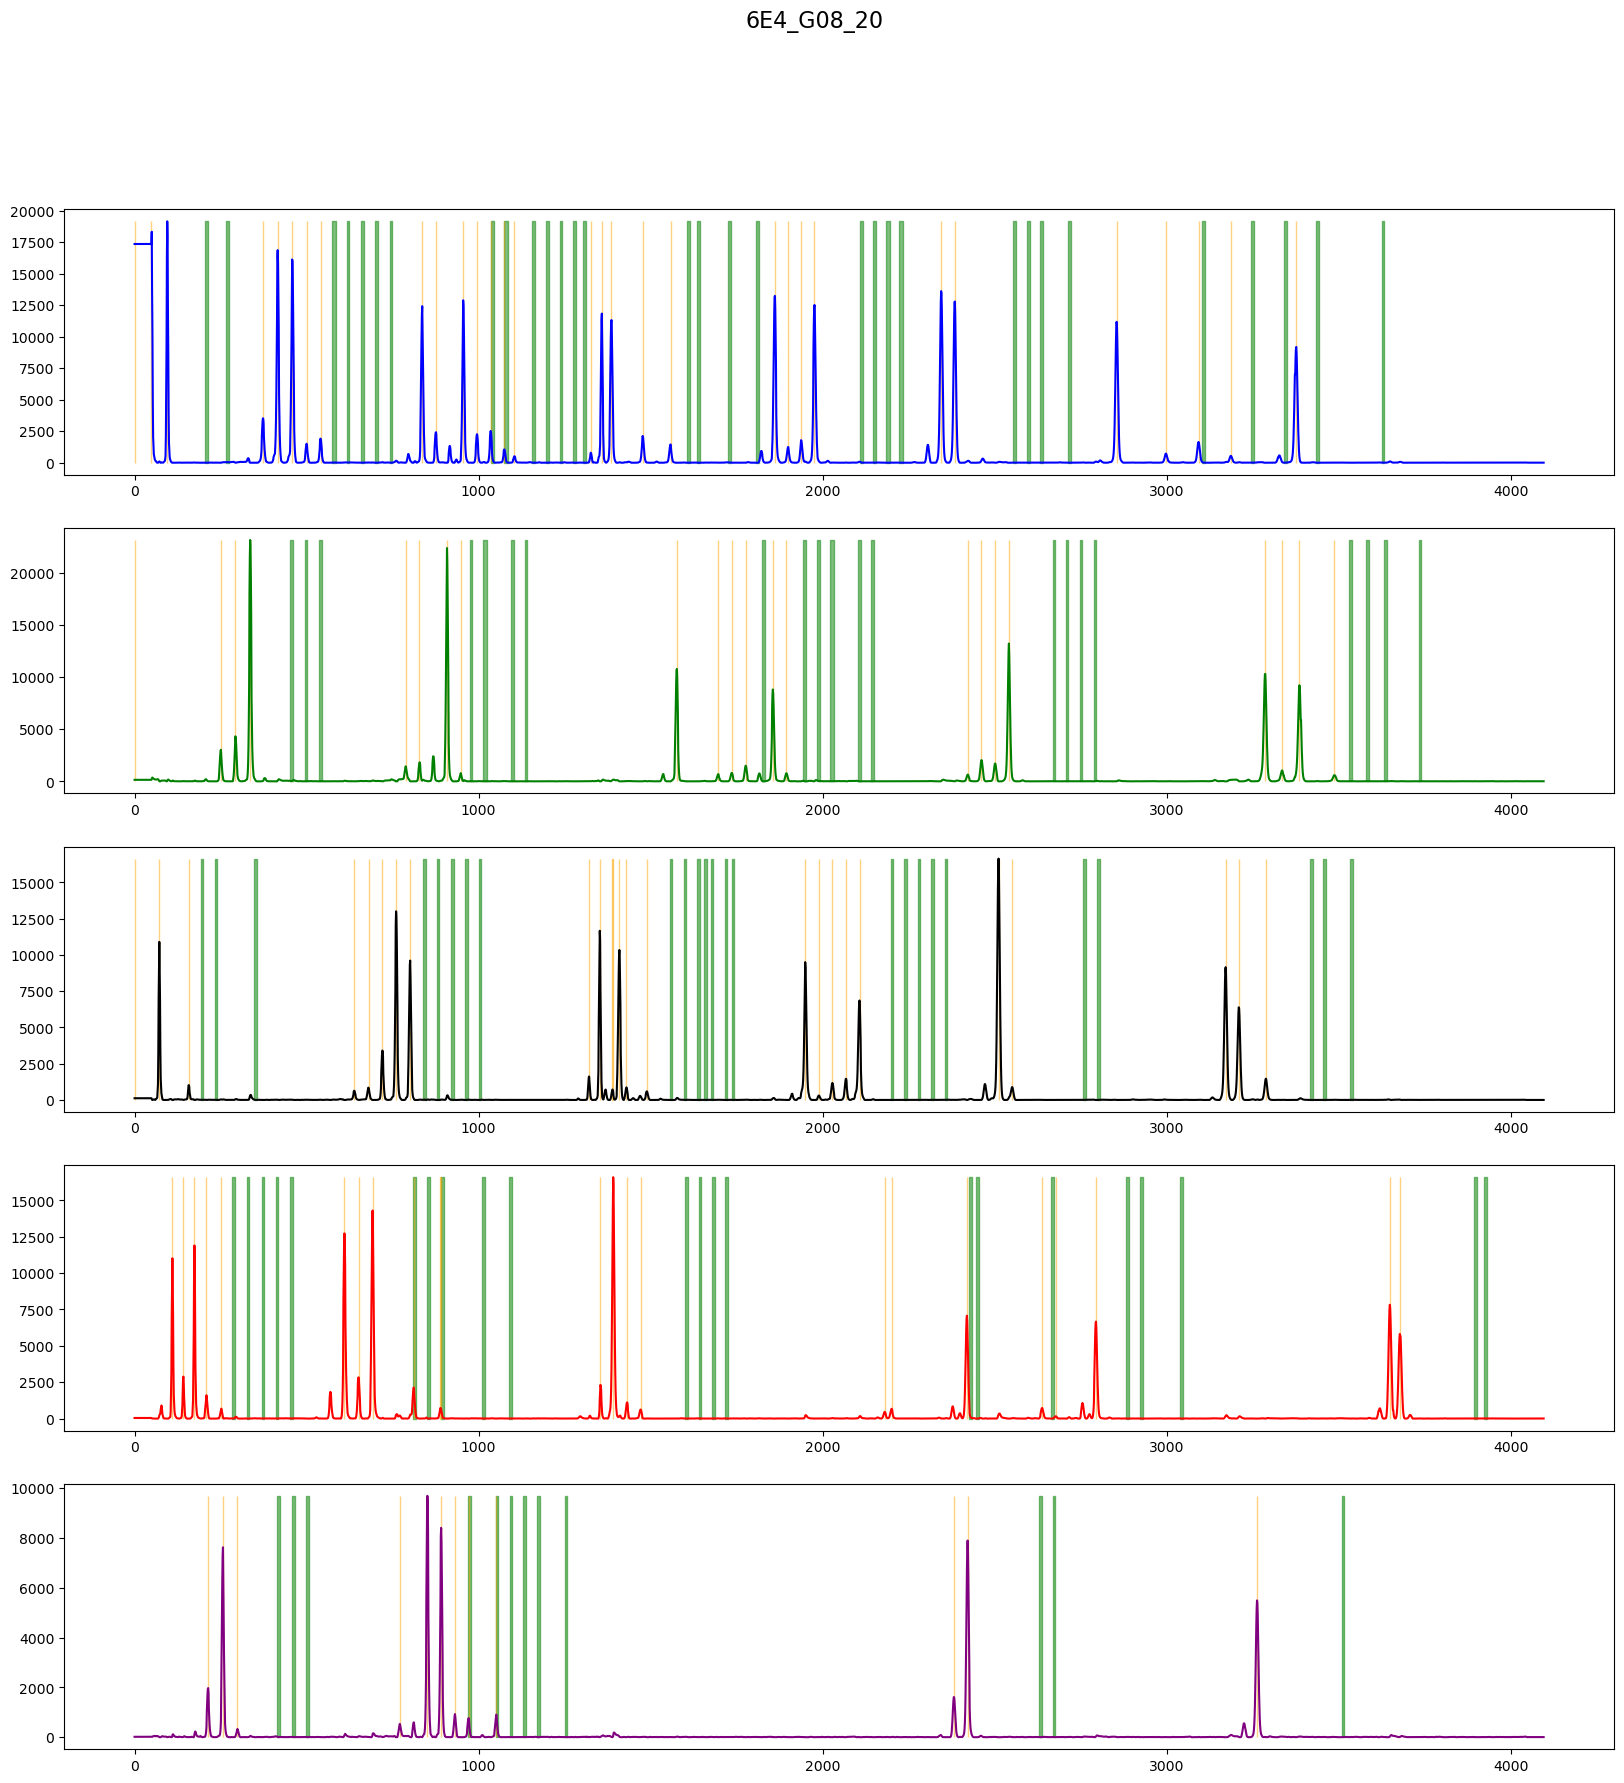

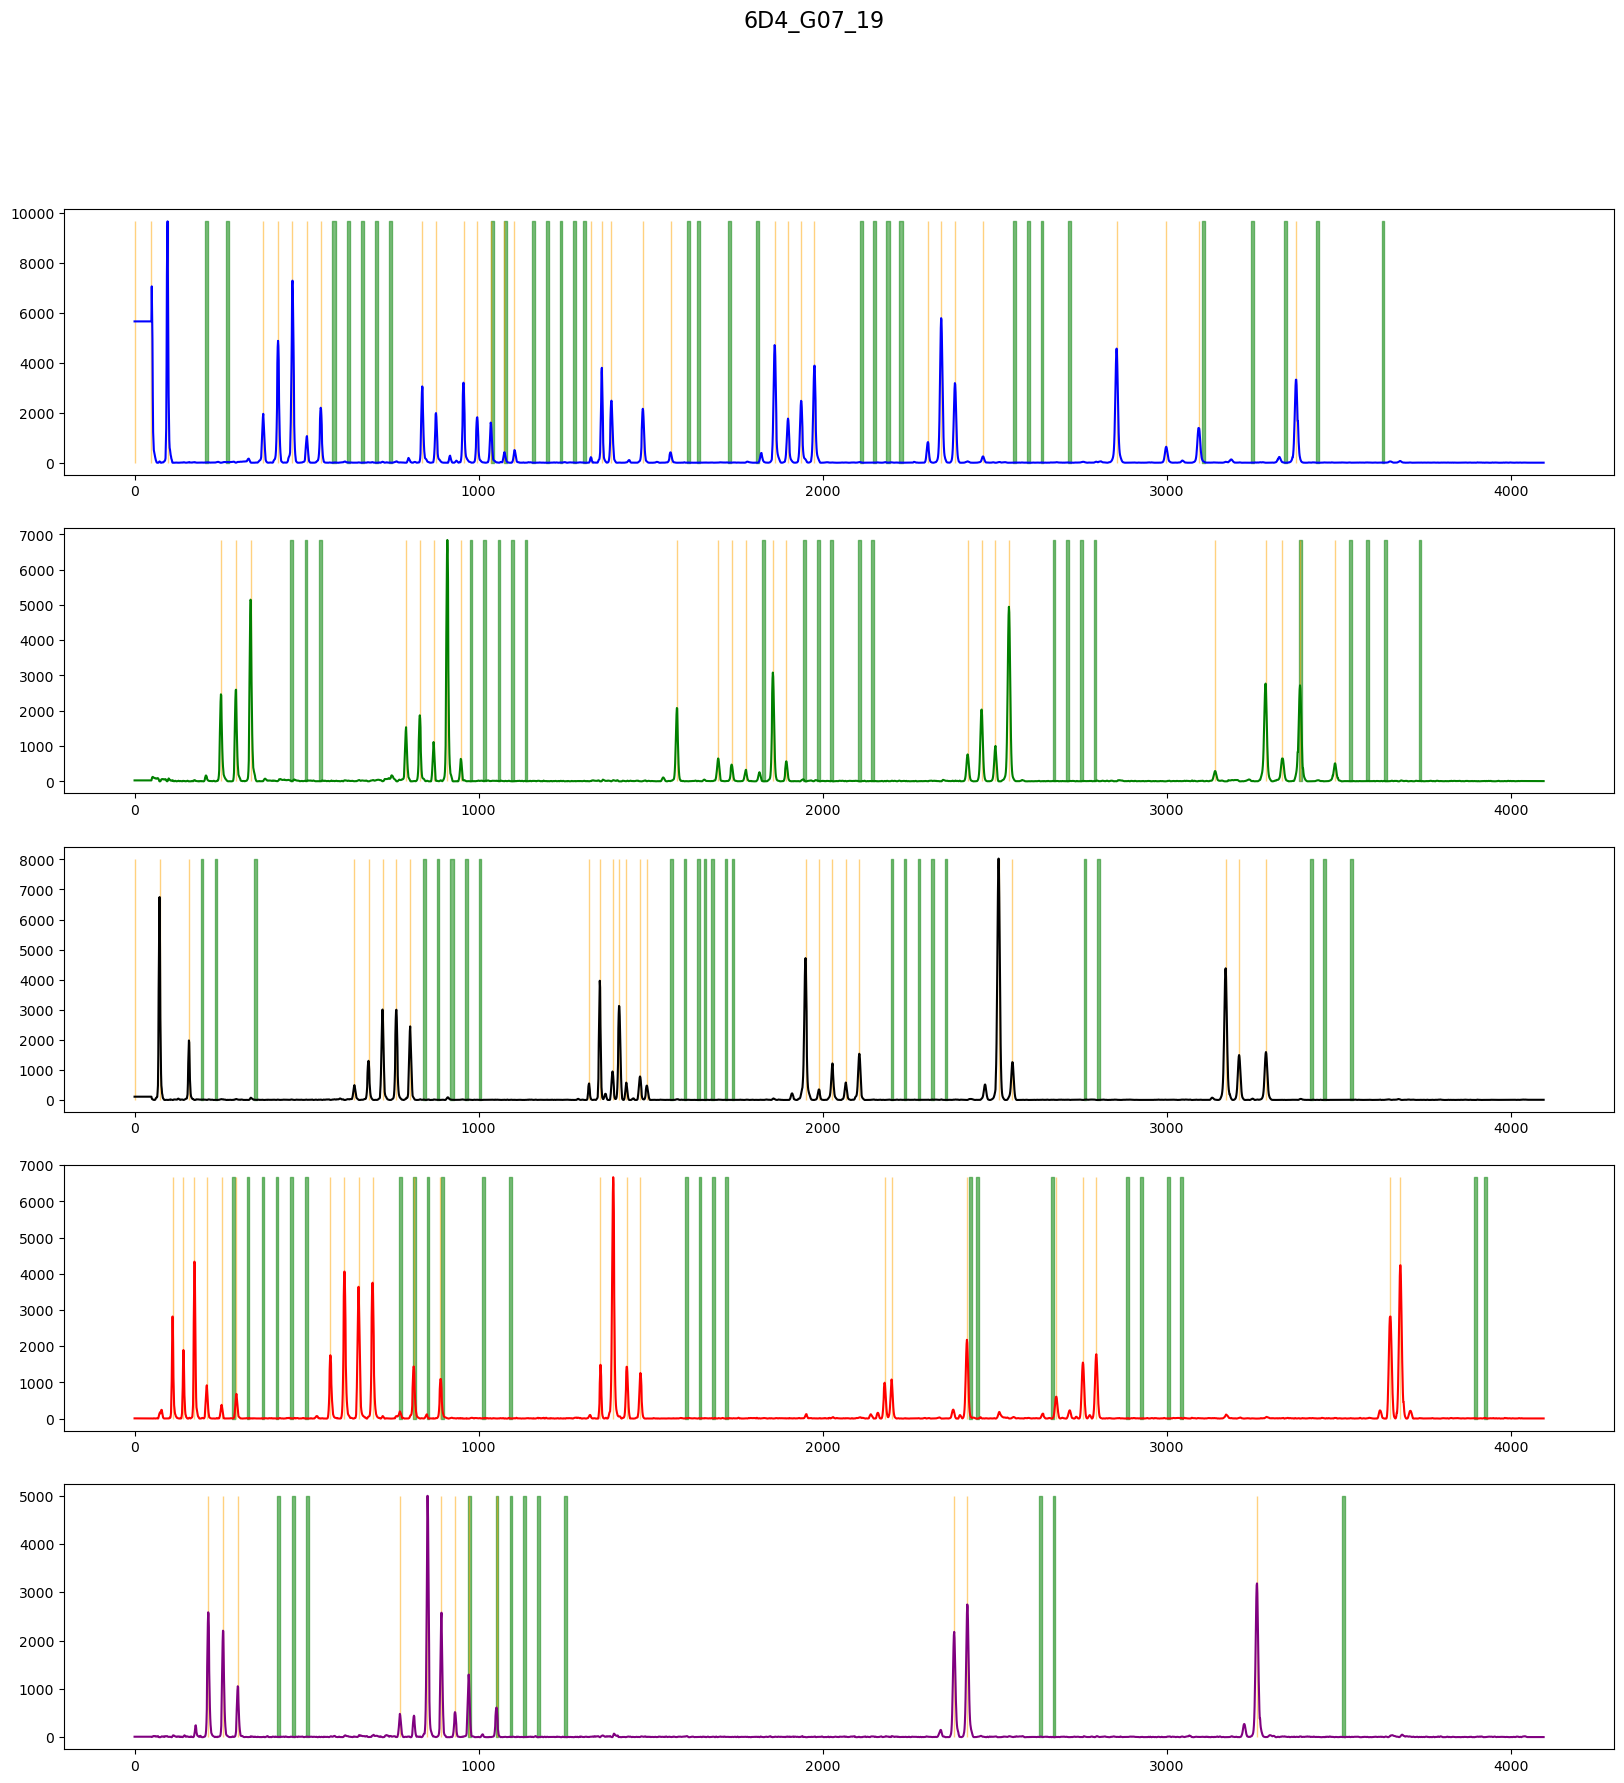

In [10]:
plot_profile(hid_dataset, predictions)

## Prediction Metrics

In [7]:
print('pixel u-net f1: ', pixel_f1_score(hid_dataset, predictions))
print('pixel u-net precision: ', pixel_precision(hid_dataset, predictions))
print('pixel u-net recall: ', pixel_recall(hid_dataset, predictions))


print('allele u-net f1: ', allele_f1_score(hid_dataset, predictions))
print('allele u-net precision: ', allele_precision(hid_dataset, predictions))
print('allele u-net recall: ', allele_recall(hid_dataset, predictions))


pixel u-net f1:  0.008675129170121833
pixel u-net precision:  0.04307887234716503
pixel u-net recall:  0.004823208142710218
allele u-net f1:  0.07892882311486961
allele u-net precision:  0.08205128205128205
allele u-net recall:  0.07603530210454854


## 30 mixtures
* allele u-net f1:  0.9558823529411765
* allele u-net precision:  0.9848484848484849
* allele u-net recall:  0.9285714285714286

## Comapring to Humans

In [8]:
from DNAnet.models.segmentation.human_analysis import HumanAnalysis

human_model = HumanAnalysis()

human_predictions = []
for img in hid_dataset:
    pred = human_model.predict(img)
    human_predictions.append(pred)



In [9]:
from DNAnet.evaluation.segmentation.allele_metrics import allele_f1_score, allele_precision, allele_recall

print("Allele F1:", allele_f1_score(hid_dataset, human_predictions))
print("Allele Precision:", allele_precision(hid_dataset, human_predictions))
print("Allele Recall:", allele_recall(hid_dataset, human_predictions))


Allele F1: 0.9762108505904501
Allele Precision: 0.9844666896789782
Allele Recall: 0.9680923285811269
